# XGBoost Model — Performance Decline & Rating Prediction
## FixtureIQ · Seasons 2022-2023 to 2024-2025

**Prediction question**: Before a player's next match, is this player at risk of underperforming?

This notebook builds two XGBoost models using the master training table:

| Model | Type | Target | Question |
|-------|------|--------|----------|
| **A — Decline Classifier** | Binary classification | `api_rating_decline_flag` | Will this player's API rating drop >0.5 in their next match? |
| **B — Rating Regressor** | Regression | `next_api_rating` | What will this player's next API rating be? |

**Dataset**: `Fixture_IQ_Data_Seasons_2022-2025.csv` — 68,722 rows × 90 columns 
**Input**: one row = one player × one match appearance, all competitions, all 20 PL teams.

**Why `api_rating_decline_flag` instead of `rating_decline_flag`?**
- `rating_decline_flag` (old): SofaScore-based, **82.3% null**, forces all non-PL rows to 0 → 2.3% positive rate, `scale_pos_weight ≈ 41.8`
- `api_rating_decline_flag` (new): API-based, all competitions, **minutes-guarded** (both appearances ≥45 min) → 9.8% positive rate across all rows, `scale_pos_weight ≈ 9.2`. After filtering to the scorable subset both matches ≥45 min, rate ≈ **25%**, `scale_pos_weight ≈ 3`

---

**Pipeline**:
1. Load master table
2. Define features, drop bad columns
3. Temporal train / val / test split — **no random shuffle, split by season**
4. Preprocessing: median imputation for numerics, OHE for categoricals (no StandardScaler)
5. XGBoost training with early stopping on validation PR-AUC
6. Evaluation: AUC-ROC, AUC-PR, confusion matrix
7. Threshold optimisation for risk-alert system
8. SHAP: global feature importance + individual player explanation
9. Model B: regression on `next_api_rating` (all competitions — 67.3% fill)
10. Save all artefacts

In [7]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
import json
import pickle
from pathlib import Path


import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    mean_absolute_error, mean_squared_error,
)

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = Path('../..')
MASTER_PATH   = BASE_DIR / 'Data' / 'Fixture_IQ_Data_Seasons_2022-2025.csv'
ARTIFACTS_DIR = BASE_DIR / 'models' /  'Xg_Boost' / 'artifacts'
FIGURES_DIR   = ARTIFACTS_DIR / 'figures'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Master table:    {MASTER_PATH}')
print(f'Artifacts saved: {ARTIFACTS_DIR}')
print(f'XGBoost version: {xgb.__version__}')

Master table:    ../../Data/Fixture_IQ_Data_Seasons_2022-2025.csv
Artifacts saved: ../../models/Xg_Boost/artifacts
XGBoost version: 3.2.0


## Section 1 — Load Master Table

In [8]:
df = pd.read_csv(MASTER_PATH)
df["date"] = pd.to_datetime(df["date"])

print(f"Shape:   {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

print("\nCompetition breakdown:")
print(df["competition"].value_counts().to_string())

print(f"\n{'─' * 60}")
print("TARGET VARIABLE OVERVIEW")
print(f"{'─' * 60}")

# Primary target: api_rating_decline_flag
n_pos_all = int(df["api_rating_decline_flag"].sum())
n_neg_all = int((df["api_rating_decline_flag"] == 0).sum())
n_all = len(df)

print(f"\napi_rating_decline_flag  (all {n_all:,} rows):")
print(f"  Decline   (1): {n_pos_all:6,}  ({n_pos_all / n_all * 100:.2f}%)")
print(f"  No decline(0): {n_neg_all:6,}  ({n_neg_all / n_all * 100:.2f}%)")

# Scorable subset: both appearances ≥45 min, both API-rated
scorable = df[
    (df["rating"] > 0)
    & df["next_api_rating"].notna()
    & (df["minutes_played"] >= 45)
    & (df["next_minutes_played"].fillna(0) >= 45)
].copy()

n_pos_s = int(scorable["api_rating_decline_flag"].sum())
n_neg_s = int((scorable["api_rating_decline_flag"] == 0).sum())
n_s = len(scorable)
spw_s = round(n_neg_s / n_pos_s, 1) if n_pos_s > 0 else np.nan

print("\napi_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):")
print(f"  Rows: {n_s:,}")
print(f"  Decline   (1): {n_pos_s:6,}  ({n_pos_s / n_s * 100:.2f}%)")
print(f"  No decline(0): {n_neg_s:6,}  ({n_neg_s / n_s * 100:.2f}%)")
print(f"  scale_pos_weight: {spw_s}")

print("\nTarget rate by season (scorable subset):")
for s in sorted(scorable["season"].unique()):
    sub = scorable[scorable["season"] == s]
    cnt = int(sub["api_rating_decline_flag"].sum())
    rate = sub["api_rating_decline_flag"].mean() * 100
    print(f"  {s}: {rate:.2f}%  ({cnt:,} positives / {len(sub):,} rows)")

print("\nLegacy target (reference only):")
n_old = int(df["rating_decline_flag"].sum())
print(
    f"  rating_decline_flag: {n_old:,} positives "
    f"({n_old / len(df) * 100:.2f}%) — SofaScore-based, PL only"
)

Shape:   68,722 rows x 90 columns
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
Date range: 2022-07-30 to 2025-05-25

Competition breakdown:
competition
Premier League      45552
League Cup          10997
FA Cup               6972
Champions League     5081
Community Shield      120

────────────────────────────────────────────────────────────
TARGET VARIABLE OVERVIEW
────────────────────────────────────────────────────────────

api_rating_decline_flag  (all 68,722 rows):
  Decline   (1):  6,753  (9.83%)
  No decline(0): 61,969  (90.17%)

api_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):
  Rows: 27,283
  Decline   (1):  6,753  (24.75%)
  No decline(0): 20,530  (75.25%)
  scale_pos_weight: 3.0

Target rate by season (scorable subset):
  2022: 24.56%  (2,294 positives / 9,340 rows)
  2023: 24.71%  (2,269 positives / 9,183 rows)
  2024: 25.00%  (2,190 positives / 8,760 rows)

Legacy target (reference only):
  rating_decline_flag: 1,660 positives (2.42%) 

## Section 2 — Feature Matrix

This section defines the feature matrix used for the XGBoost models.

The dataset contains one row per player-match appearance. Before model training, columns that could cause leakage, act as identifiers, contain excessive missingness, or duplicate information were removed from the feature matrix.

## Columns Dropped Before Model Training

| Column / Column Group    | Reason                                                                                                                   |
| ------------------------ | ------------------------------------------------------------------------------------------------------------------------ |
| `fixture_id`             | Match identifier, not a generalisable predictive feature                                                                 |
| `date`                   | Raw date identifier; temporal information is handled through season-based splitting                                      |
| `round`                  | Fixture identifier / schedule proxy with potential leakage                                                               |
| `player_id`              | Not reliable because unresolved players share the same ID value                                                          |
| `player_name`            | Player identifier, not suitable for generalisable modelling                                                              |
| `player_number`          | Player identifier / proxy for identity                                                                                   |
| `next_api_rating`        | Model A leakage because this is the future rating used to define the decline target; kept only as the target for Model B |
| `next_is_substitute`     | Temporal leakage because it describes the player’s next match                                                            |
| `next_minutes_played`    | Temporal leakage because it describes the player’s next match                                                            |
| `next_sofascore_rating`  | Future rating information and highly incomplete legacy SofaScore variable                                                |
| `rating_decline_flag`    | Old SofaScore-based decline target, not used for the final classifier                                                    |
| `sofascore_rating`       | Highly incomplete SofaScore variable with Premier League-only coverage                                                   |
| `ss_minutes`             | Redundant with `minutes_played`                                                                                          |
| `opp_shots_on_goal`      | Empty or unusable opponent-stat column                                                                                   |
| `opp_total_shots`        | Empty or unusable opponent-stat column                                                                                   |
| `opp_possession`         | Empty or unusable opponent-stat column                                                                                   |
| `fb_*` columns           | FBRef-derived columns with very high missingness and limited Champions League coverage                                   |
| `days_since_last_injury` | Very high missingness, therefore not used in the XGBoost feature matrix                                                  |

## Leakage Logic

The most important exclusion principle was to remove any variable that directly described the next match.

For Model A, the prediction is made **before the player's next appearance**. Therefore, variables such as:

```text
next_api_rating
next_minutes_played
next_is_substitute
next_sofascore_rating
```

cannot be used as input features.

These variables are future information and would not be available at prediction time.

## Model A Filter: Scorable Subset

Model A was trained on the scorable subset.

A row was included if it satisfied the following conditions:

```text
rating > 0
next_api_rating.notna()
minutes_played >= 45
next_minutes_played >= 45
```

These filters ensured that both the current and next appearances represented meaningful, rated performances.

## Why the Scorable Subset Was Used

The decline target compares the player’s current API rating with their next API rating.

To make this comparison meaningful, both appearances needed to have enough playing time.

The scorable subset therefore removes very short appearances, late substitutions, and observations where the next rating was unavailable.

This produced a cleaner modelling population for the binary decline classifier.

## Model A Target

The target for Model A was:

```text
api_rating_decline_flag
```

This target indicates whether the player’s next API rating dropped by more than 0.5 compared with the current match.

The target was API-based, minutes-guarded, and available across all competitions.

## Model B Target

Model B used a regression target:

```text
next_api_rating
```

Unlike Model A, Model B directly predicts the player’s next rating as a continuous value.

For this reason, `next_api_rating` is excluded as a feature for Model A but retained as the target variable for Model B.

## Kept Feature Types

After removing leakage, identifier, redundant, and highly incomplete variables, the feature matrix retained variables from the following groups:

| Feature Group            | Examples / Description                                                          |
| ------------------------ | ------------------------------------------------------------------------------- |
| Match context            | Season, competition, home/away context, team/opponent context                   |
| Player role and position | Position, substitute status, role-related variables                             |
| Workload and fatigue     | Recent minutes, accumulated workload, rest days, fixture congestion             |
| Squad injury context     | Injured player counts, soft-tissue injury pressure, squad-level availability    |
| Lag injury features      | Recent injury burden and historical injury context                              |
| Competition context      | Competition indicators and schedule context                                     |
| Performance history      | Current and lagged rating/performance variables available before the next match |

## Final Feature-Matrix Principle

The final feature matrix was designed to answer the real deployment question:

> Before the next match, using only information already available, is this player at risk of underperforming?

Therefore, the feature set intentionally excluded future information from the next match while retaining pre-match context, workload, role, injury, and recent performance information.

This made the modelling setup more realistic for a dashboard-based risk-alert system.


In [ ]:
# =============================================================================
# EXTERNAL INJURY DATABASE INTEGRATION
# FixtureIQ XGBoost Pipeline
# ============================================================================

# =============================================================================
# 1. PATHS
# =============================================================================

INJURY_BASE_DIR = BASE_DIR / "Data"

INJURY_SEASON_DIRS = [
    INJURY_BASE_DIR / "SEASON_2022_2023" / "processed_injuries",
    INJURY_BASE_DIR / "SEASON_2023_2024" / "processed_injuries",
    INJURY_BASE_DIR / "SEASON_2024_2025" / "processed_injuries",
]

print("Checking injury directories:")
for season_dir in INJURY_SEASON_DIRS:
    print(f"  {season_dir.resolve()} | exists: {season_dir.exists()}")


# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================

def clean_colnames(dataframe):
    """
    Convert column names to clean snake_case.
    """
    out = dataframe.copy()
    out.columns = (
        out.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return out


def season_to_start_year(value):
    """
    Convert season values to integer start year.

    Examples:
    '2022-2023' -> 2022
    '2022/23'   -> 2022
    2022        -> 2022
    np.int64(2022) -> 2022
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    match = re.search(r"(\d{4})", value)
    if match:
        return int(match.group(1))

    return np.nan


def normalise_team_name(value):
    """
    Normalise team names for safer joins.
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()
    value = re.sub(r"\s+", " ", value)
    value = value.replace("&", "and")

    replacements = {
        "arsenal fc": "arsenal",
        "arsenal": "arsenal",

        "aston villa fc": "aston villa",
        "aston villa": "aston villa",

        "afc bournemouth": "bournemouth",
        "bournemouth": "bournemouth",

        "brentford fc": "brentford",
        "brentford": "brentford",

        "brighton": "brighton and hove albion",
        "brighton & hove albion": "brighton and hove albion",
        "brighton and hove albion": "brighton and hove albion",

        "burnley fc": "burnley",
        "burnley": "burnley",

        "chelsea fc": "chelsea",
        "chelsea": "chelsea",

        "crystal palace fc": "crystal palace",
        "crystal palace": "crystal palace",

        "everton fc": "everton",
        "everton": "everton",

        "fulham fc": "fulham",
        "fulham": "fulham",

        "leeds united fc": "leeds united",
        "leeds united": "leeds united",
        "leeds": "leeds united",

        "leicester city fc": "leicester city",
        "leicester city": "leicester city",
        "leicester": "leicester city",

        "liverpool fc": "liverpool",
        "liverpool": "liverpool",

        "luton town fc": "luton town",
        "luton town": "luton town",
        "luton": "luton town",

        "man city": "manchester city",
        "manchester city fc": "manchester city",
        "manchester city": "manchester city",

        "man utd": "manchester united",
        "man united": "manchester united",
        "manchester united fc": "manchester united",
        "manchester united": "manchester united",

        "newcastle": "newcastle united",
        "newcastle united fc": "newcastle united",
        "newcastle united": "newcastle united",

        "nottm forest": "nottingham forest",
        "nottingham": "nottingham forest",
        "nottingham forest fc": "nottingham forest",
        "nottingham forest": "nottingham forest",

        "sheffield united fc": "sheffield united",
        "sheffield united": "sheffield united",

        "southampton fc": "southampton",
        "southampton": "southampton",

        "spurs": "tottenham",
        "tottenham hotspur": "tottenham",
        "tottenham hotspur fc": "tottenham",
        "tottenham": "tottenham",

        "west ham": "west ham united",
        "west ham united fc": "west ham united",
        "west ham united": "west ham united",

        "wolves": "wolverhampton wanderers",
        "wolverhampton": "wolverhampton wanderers",
        "wolverhampton wanderers fc": "wolverhampton wanderers",
        "wolverhampton wanderers": "wolverhampton wanderers",
    }

    return replacements.get(value, value)


def normalise_player_name(value):
    """
    Normalise player names for safer player-season joins.
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()
    value = re.sub(r"\s+", " ", value)
    return value


def load_injury_file(pattern):
    """
    Load injury files across all season folders.
    """
    frames = []

    for season_dir in INJURY_SEASON_DIRS:
        files = sorted(season_dir.glob(pattern))

        for file in files:
            temp = pd.read_csv(file)
            temp = clean_colnames(temp)
            temp["injury_source_file"] = file.name
            temp["injury_source_dir"] = str(season_dir)
            frames.append(temp)

    if not frames:
        print(f"No files found for pattern: {pattern}")
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    print(f"Loaded {pattern}: {out.shape[0]:,} rows x {out.shape[1]} columns")
    return out


# =============================================================================
# 3. LOAD PROCESSED INJURY FILES
# =============================================================================

injury_spells = load_injury_file("estimated_injury_spells_*.csv")
player_absence = load_injury_file("player_season_absence_burden_*.csv")
team_match_injuries = load_injury_file("team_match_injury_outcomes_*.csv")
team_season_injuries = load_injury_file("team_season_injury_burden_*.csv")

print("\nLoaded injury tables:")
print(f"  injury_spells:        {injury_spells.shape}")
print(f"  player_absence:       {player_absence.shape}")
print(f"  team_match_injuries:  {team_match_injuries.shape}")
print(f"  team_season_injuries: {team_season_injuries.shape}")


# =============================================================================
# 4. FIX SEASON FORMAT GLOBALLY
# =============================================================================

df = df.copy()

if "season" not in df.columns:
    raise KeyError("Master table must contain a 'season' column.")

if "date" not in df.columns:
    raise KeyError("Master table must contain a 'date' column.")

if "player_team" not in df.columns:
    raise KeyError("Master table must contain a 'player_team' column.")

df["season"] = df["season"].apply(season_to_start_year).astype("Int64")

for table_name, table in {
    "injury_spells": injury_spells,
    "player_absence": player_absence,
    "team_match_injuries": team_match_injuries,
    "team_season_injuries": team_season_injuries,
}.items():
    if not table.empty and "season" in table.columns:
        table["season"] = table["season"].apply(season_to_start_year).astype("Int64")
        print(f"{table_name} season dtype: {table['season'].dtype}")
        print(f"{table_name} seasons: {sorted(table['season'].dropna().unique())}")


# =============================================================================
# 5. PREPARE MASTER TABLE KEYS
# =============================================================================

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["player_team_key"] = df["player_team"].apply(normalise_team_name)

if "player_name" in df.columns:
    df["player_name_key"] = df["player_name"].apply(normalise_player_name)
else:
    df["player_name_key"] = np.nan

print("\nMaster table prepared:")
print(f"  Rows: {len(df):,}")
print(f"  Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"  Unique raw player_team: {df['player_team'].nunique()}")
print(f"  Unique normalised player_team_key: {df['player_team_key'].nunique()}")


# =============================================================================
# 6. TEAM-MATCH INJURY FEATURES
# =============================================================================
# Source:
#   team_match_injury_outcomes_<season>.csv
#
# Source columns:
#   season
#   season_label
#   team
#   fixture_date
#   players_missing_total
#   players_missing_injury
#   players_missing_non_injury
#   soft_tissue_missing
#   max_reported_days_out
#   mean_reported_days_out
# =============================================================================

if team_match_injuries.empty:
    raise ValueError("team_match_injuries table is empty.")

inj_match = team_match_injuries.copy()

required_cols = [
    "season",
    "team",
    "fixture_date",
    "players_missing_total",
    "players_missing_injury",
    "players_missing_non_injury",
    "soft_tissue_missing",
    "max_reported_days_out",
    "mean_reported_days_out",
]

missing_required = [col for col in required_cols if col not in inj_match.columns]
if missing_required:
    raise KeyError(f"Missing required columns in team_match_injuries: {missing_required}")

inj_match["date"] = pd.to_datetime(inj_match["fixture_date"], errors="coerce")
inj_match["player_team_key"] = inj_match["team"].apply(normalise_team_name)

inj_match = inj_match.rename(
    columns={
        "players_missing_total": "squad_players_missing_total",
        "players_missing_injury": "squad_injured_count",
        "players_missing_non_injury": "squad_non_injury_missing_count",
        "soft_tissue_missing": "squad_soft_tissue_count",
        "mean_reported_days_out": "squad_avg_days_out",
        "max_reported_days_out": "squad_max_days_out",
    }
)

team_match_features = [
    "squad_players_missing_total",
    "squad_injured_count",
    "squad_non_injury_missing_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "squad_max_days_out",
]

for col in team_match_features:
    inj_match[col] = pd.to_numeric(inj_match[col], errors="coerce")

inj_match_merge = (
    inj_match[["date", "player_team_key"] + team_match_features]
    .dropna(subset=["date", "player_team_key"])
    .groupby(["date", "player_team_key"], as_index=False)
    .agg({
        "squad_players_missing_total": "max",
        "squad_injured_count": "max",
        "squad_non_injury_missing_count": "max",
        "squad_soft_tissue_count": "max",
        "squad_avg_days_out": "mean",
        "squad_max_days_out": "max",
    })
)

for col in team_match_features:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.merge(
    inj_match_merge,
    on=["date", "player_team_key"],
    how="left",
    validate="m:1",
)

print("\nTeam-match injury merge complete.")
print(f"  Merge table rows: {len(inj_match_merge):,}")
print(f"  df shape: {df.shape}")
print("\nTeam-match injury coverage in full df:")
print(df[team_match_features].notna().mean().sort_values(ascending=False).to_string())


# =============================================================================
# 7. TEAM-SEASON INJURY FEATURES
# =============================================================================
# Source:
#   team_season_injury_burden_<season>.csv
# =============================================================================

if team_season_injuries.empty:
    print("\nteam_season_injuries table is empty. Skipping team-season merge.")
    team_season_features = []
else:
    inj_team_season = team_season_injuries.copy()

    required_cols = [
        "season",
        "team",
        "total_player_fixture_absences",
        "total_injury_player_fixture_absences",
        "mean_injury_players_missing_per_match",
        "total_soft_tissue_missing",
        "mean_soft_tissue_missing_per_match",
        "unique_players_missing",
        "max_injury_players_missing_in_match",
        "total_matches",
    ]

    missing_required = [col for col in required_cols if col not in inj_team_season.columns]
    if missing_required:
        raise KeyError(f"Missing required columns in team_season_injuries: {missing_required}")

    inj_team_season["season"] = inj_team_season["season"].apply(season_to_start_year).astype("Int64")
    inj_team_season["player_team_key"] = inj_team_season["team"].apply(normalise_team_name)

    inj_team_season = inj_team_season.rename(
        columns={
            "total_player_fixture_absences": "team_season_total_absences",
            "total_injury_player_fixture_absences": "team_season_injury_absences",
            "mean_injury_players_missing_per_match": "team_season_mean_injured_missing",
            "total_soft_tissue_missing": "team_season_soft_tissue_absences",
            "mean_soft_tissue_missing_per_match": "team_season_mean_soft_tissue_missing",
            "unique_players_missing": "team_season_unique_players_missing",
            "max_injury_players_missing_in_match": "team_season_max_injured_in_match",
            "total_matches": "team_season_total_matches",
        }
    )

    team_season_features = [
        "team_season_total_absences",
        "team_season_injury_absences",
        "team_season_mean_injured_missing",
        "team_season_soft_tissue_absences",
        "team_season_mean_soft_tissue_missing",
        "team_season_unique_players_missing",
        "team_season_max_injured_in_match",
        "team_season_total_matches",
    ]

    for col in team_season_features:
        inj_team_season[col] = pd.to_numeric(inj_team_season[col], errors="coerce")

    inj_team_season_merge = (
        inj_team_season[["season", "player_team_key"] + team_season_features]
        .dropna(subset=["season", "player_team_key"])
        .groupby(["season", "player_team_key"], as_index=False)
        .max(numeric_only=True)
    )

    inj_team_season_merge["season"] = inj_team_season_merge["season"].astype("Int64")
    df["season"] = df["season"].astype("Int64")

    for col in team_season_features:
        if col in df.columns:
            df = df.drop(columns=[col])

    df = df.merge(
        inj_team_season_merge,
        on=["season", "player_team_key"],
        how="left",
        validate="m:1",
    )

    print("\nTeam-season injury merge complete.")
    print(f"  Merge table rows: {len(inj_team_season_merge):,}")
    print(f"  df shape: {df.shape}")
    print("\nTeam-season injury coverage in full df:")
    print(df[team_season_features].notna().mean().sort_values(ascending=False).to_string())


# =============================================================================
# 8. PLAYER-SEASON ABSENCE FEATURES
# =============================================================================
# Source:
#   player_season_absence_burden_<season>.csv
# =============================================================================

if player_absence.empty:
    print("\nplayer_absence table is empty. Skipping player-season absence merge.")
    player_abs_num_features = []
    player_abs_cat_features = []
else:
    p_abs = player_absence.copy()

    required_cols = [
        "season",
        "team",
        "player",
        "matches_missed_total",
        "matches_missed_injury",
        "main_reason",
        "main_injury_category",
        "max_reported_days_out",
    ]

    missing_required = [col for col in required_cols if col not in p_abs.columns]
    if missing_required:
        raise KeyError(f"Missing required columns in player_absence: {missing_required}")

    p_abs["season"] = p_abs["season"].apply(season_to_start_year).astype("Int64")
    p_abs["player_team_key"] = p_abs["team"].apply(normalise_team_name)
    p_abs["player_name_key"] = p_abs["player"].apply(normalise_player_name)

    p_abs = p_abs.rename(
        columns={
            "matches_missed_total": "player_season_matches_missed_total",
            "matches_missed_injury": "player_season_matches_missed_injury",
            "max_reported_days_out": "player_season_max_days_out",
            "main_reason": "player_main_absence_reason",
            "main_injury_category": "player_main_injury_category",
        }
    )

    player_abs_num_features = [
        "player_season_matches_missed_total",
        "player_season_matches_missed_injury",
        "player_season_max_days_out",
    ]

    player_abs_cat_features = [
        "player_main_absence_reason",
        "player_main_injury_category",
    ]

    for col in player_abs_num_features:
        p_abs[col] = pd.to_numeric(p_abs[col], errors="coerce")

    p_abs_merge = (
        p_abs[
            ["season", "player_team_key", "player_name_key"]
            + player_abs_num_features
            + player_abs_cat_features
        ]
        .dropna(subset=["season", "player_team_key", "player_name_key"])
        .groupby(["season", "player_team_key", "player_name_key"], as_index=False)
        .agg({
            "player_season_matches_missed_total": "max",
            "player_season_matches_missed_injury": "max",
            "player_season_max_days_out": "max",
            "player_main_absence_reason": "first",
            "player_main_injury_category": "first",
        })
    )

    for col in player_abs_num_features + player_abs_cat_features:
        if col in df.columns:
            df = df.drop(columns=[col])

    df = df.merge(
        p_abs_merge,
        on=["season", "player_team_key", "player_name_key"],
        how="left",
        validate="m:1",
    )

    print("\nPlayer-season absence merge complete.")
    print(f"  Merge table rows: {len(p_abs_merge):,}")
    print(f"  df shape: {df.shape}")
    print("\nPlayer-season absence coverage in full df:")
    print(df[player_abs_num_features + player_abs_cat_features].notna().mean().sort_values(ascending=False).to_string())


# =============================================================================
# 9. ESTIMATED INJURY SPELL FEATURES
# =============================================================================
# Source:
#   estimated_injury_spells_<season>.csv
# =============================================================================

if injury_spells.empty:
    print("\ninjury_spells table is empty. Skipping injury-spell merge.")
    spell_features = []
else:
    spells = injury_spells.copy()

    required_cols = [
        "season",
        "team",
        "player",
        "reason",
        "injury_category",
        "matches_missed",
        "reported_days_out",
    ]

    missing_required = [col for col in required_cols if col not in spells.columns]
    if missing_required:
        raise KeyError(f"Missing required columns in injury_spells: {missing_required}")

    spells["season"] = spells["season"].apply(season_to_start_year).astype("Int64")
    spells["player_team_key"] = spells["team"].apply(normalise_team_name)
    spells["player_name_key"] = spells["player"].apply(normalise_player_name)

    spells["matches_missed"] = pd.to_numeric(spells["matches_missed"], errors="coerce")
    spells["reported_days_out"] = pd.to_numeric(spells["reported_days_out"], errors="coerce")

    spell_num = (
        spells
        .dropna(subset=["season", "player_team_key", "player_name_key"])
        .groupby(["season", "player_team_key", "player_name_key"], as_index=False)
        .agg(
            player_season_injury_spells=("reason", "count"),
            player_season_spell_matches_missed=("matches_missed", "sum"),
            player_season_spell_max_days_out=("reported_days_out", "max"),
        )
    )

    spell_cat = (
        spells
        .dropna(subset=["season", "player_team_key", "player_name_key", "injury_category"])
        .groupby(["season", "player_team_key", "player_name_key"])["injury_category"]
        .agg(lambda x: x.value_counts().index[0])
        .reset_index()
        .rename(columns={"injury_category": "player_season_main_spell_category"})
    )

    spell_merge = spell_num.merge(
        spell_cat,
        on=["season", "player_team_key", "player_name_key"],
        how="left",
    )

    spell_features = [
        "player_season_injury_spells",
        "player_season_spell_matches_missed",
        "player_season_spell_max_days_out",
        "player_season_main_spell_category",
    ]

    for col in spell_features:
        if col in df.columns:
            df = df.drop(columns=[col])

    df = df.merge(
        spell_merge,
        on=["season", "player_team_key", "player_name_key"],
        how="left",
        validate="m:1",
    )

    print("\nEstimated injury spell merge complete.")
    print(f"  Merge table rows: {len(spell_merge):,}")
    print(f"  df shape: {df.shape}")
    print("\nEstimated injury spell coverage in full df:")
    print(df[spell_features].notna().mean().sort_values(ascending=False).to_string())


# =============================================================================
# 10. MISSINGNESS-AWARE IMPUTATION
# =============================================================================

numeric_injury_features = (
    team_match_features
    + team_season_features
    + player_abs_num_features
    + [
        "player_season_injury_spells",
        "player_season_spell_matches_missed",
        "player_season_spell_max_days_out",
    ]
)

numeric_injury_features = [col for col in numeric_injury_features if col in df.columns]

for col in numeric_injury_features:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

categorical_injury_features = (
    player_abs_cat_features
    + ["player_season_main_spell_category"]
)

categorical_injury_features = [col for col in categorical_injury_features if col in df.columns]

for col in categorical_injury_features:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = df[col].fillna("none")


# =============================================================================
# 11. COMBINED INJURY SCORES
# =============================================================================

df["team_match_injury_context_score"] = 0

if "squad_injured_count" in df.columns:
    df["team_match_injury_context_score"] += (df["squad_injured_count"] >= 4).astype(int)

if "squad_soft_tissue_count" in df.columns:
    df["team_match_injury_context_score"] += (df["squad_soft_tissue_count"] >= 2).astype(int)

if "squad_avg_days_out" in df.columns:
    df["team_match_injury_context_score"] += (df["squad_avg_days_out"] >= 14).astype(int)

if "squad_max_days_out" in df.columns:
    df["team_match_injury_context_score"] += (df["squad_max_days_out"] >= 30).astype(int)


df["player_injury_history_score"] = 0

if "player_season_matches_missed_injury" in df.columns:
    df["player_injury_history_score"] += (df["player_season_matches_missed_injury"] >= 3).astype(int)

if "player_season_max_days_out" in df.columns:
    df["player_injury_history_score"] += (df["player_season_max_days_out"] >= 30).astype(int)

if "player_season_injury_spells" in df.columns:
    df["player_injury_history_score"] += (df["player_season_injury_spells"] >= 2).astype(int)

if "player_season_spell_matches_missed" in df.columns:
    df["player_injury_history_score"] += (df["player_season_spell_matches_missed"] >= 5).astype(int)


df["overall_injury_context_score"] = (
    df["team_match_injury_context_score"]
    + df["player_injury_history_score"]
)


# =============================================================================
# 12. FINAL INJURY INTEGRATION REPORT
# =============================================================================

all_injury_features = (
    numeric_injury_features
    + categorical_injury_features
    + [f"{col}_missing" for col in numeric_injury_features + categorical_injury_features]
    + [
        "team_match_injury_context_score",
        "player_injury_history_score",
        "overall_injury_context_score",
    ]
)

all_injury_features = [col for col in all_injury_features if col in df.columns]

print("\n" + "─" * 90)
print("FINAL INJURY INTEGRATION REPORT")
print("─" * 90)

coverage = pd.DataFrame({
    "column": all_injury_features,
    "non_null": [df[col].notna().sum() for col in all_injury_features],
    "null": [df[col].isna().sum() for col in all_injury_features],
    "null_pct": [df[col].isna().mean() * 100 for col in all_injury_features],
})

print(coverage.sort_values("column").to_string(index=False))

print("─" * 90)


# =============================================================================
# 13. CHECK MODEL A SCORABLE SUBSET
# =============================================================================

df_a_check = df[
    (df["rating"] > 0)
    & df["next_api_rating"].notna()
    & (df["minutes_played"] >= 45)
    & (df["next_minutes_played"].fillna(0) >= 45)
].copy()

print("\nModel A scorable subset after injury integration:")
print(f"  Rows: {len(df_a_check):,}")

numeric_injury_features_in_subset = [
    col for col in all_injury_features
    if col in df_a_check.columns and pd.api.types.is_numeric_dtype(df_a_check[col])
]

print("\nNumeric injury feature means in scorable subset:")
print(
    df_a_check[numeric_injury_features_in_subset]
    .mean()
    .sort_values(ascending=False)
    .head(50)
    .to_string()
)

print("\nTop injury feature null counts in scorable subset:")
print(
    df_a_check[all_injury_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .to_string()
)

print("\nInjury features created:")
for col in all_injury_features:
    print(f"  - {col}")

Checking injury directories:
  /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2022_2023/processed_injuries | exists: True
  /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2023_2024/processed_injuries | exists: True
  /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025/processed_injuries | exists: True
Loaded estimated_injury_spells_*.csv: 1,256 rows x 13 columns
Loaded player_season_absence_burden_*.csv: 1,160 rows x 14 columns
Loaded team_match_injury_outcomes_*.csv: 2,280 rows x 12 columns
Loaded team_season_injury_burden_*.csv: 60 rows x 13 columns

Loaded injury tables:
  injury_spells:        (1256, 13)
  player_absence:       (1160, 14)
  team_match_injuries:  (2280, 12)
  team_season_injuries: (60, 13)
injury_spells season dtype: Int64
injury_spells seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
player_absence season dtype: Int64
player_absence seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]

## Injury Database Integration Results

The external processed injury database was successfully integrated into the FixtureIQ modelling table.

Four processed injury tables were used:

| File | Level | Information added |
| ---- | ----- | ----------------- |
| `team_match_injury_outcomes_<season>.csv` | Team × fixture date | Match-day squad injury pressure |
| `team_season_injury_burden_<season>.csv` | Team × season | Season-level squad injury burden |
| `player_season_absence_burden_<season>.csv` | Player × team × season | Player-level absence burden |
| `estimated_injury_spells_<season>.csv` | Player injury spell | Estimated player injury history |

## Injury Merge Coverage

After merging the injury database into the FixtureIQ master table, the following coverage was obtained:

| Injury Feature Level | Coverage in Full Dataset |
| -------------------- | -----------------------: |
| Team-match injury context | 66.28% |
| Team-season injury burden | 80.29% |
| Player-season absence burden | 2.30% |
| Estimated player injury spells | 2.30% |

The team-level injury features had substantially better coverage than the player-level injury-history features.

This means that the most reliable injury information for the XGBoost model comes from squad-level injury burden rather than individual player injury history.

## Team-Match Injury Features

The team-match injury table was merged using:

```text
date + player_team

In [14]:
TARGET = "api_rating_decline_flag"

# ── Columns to drop from feature matrix ────────────────────────────────────────
DROP_COLS = [
    # Identifiers / leakage
    "fixture_id", "date", "round", "player_id", "player_name", "player_number",

    # Temporary merge keys created during injury integration
    "player_team_key", "player_name_key",

    # Model A leakage — temporal next-match columns
    "next_api_rating",       # regression target; leakage for classifier
    "next_is_substitute",    # describes next match
    "next_minutes_played",   # describes next match

    # Legacy targets / future target columns
    "next_sofascore_rating", # future rating, highly incomplete PL-only source
    "rating_decline_flag",   # old SofaScore-based flag

    # SofaScore columns — PL-only bias
    "sofascore_rating",      # highly incomplete PL-only rating
    "ss_minutes",            # redundant with minutes_played

    # Empty / unusable opponent stats
    "opp_shots_on_goal", "opp_total_shots", "opp_possession",

    # FBRef columns — high missingness and competition/team bias
    "fb_min", "fb_goals", "fb_assists", "fb_shots", "fb_sot",
    "fb_tackles_won", "fb_crosses", "fb_interceptions",
    "fb_fouls", "fb_fouled", "fb_offsides",

    # Near-unusable original lag feature
    # Keep the new external injury-database features, but drop this original sparse field.
    "days_since_last_injury",

    # Current API rating — removed to avoid autocorrelation bias.
    # api_rating_decline_flag is computed from current rating and next rating.
    "rating",
]

# The target itself must not be in the feature matrix
DROP_COLS.append(TARGET)

# ── Scorable subset: both current AND next appearance are real scorable performances ──
df_a = df[
    (df["rating"] > 0)
    & df["next_api_rating"].notna()
    & (df["minutes_played"] >= 45)
    & (df["next_minutes_played"].fillna(0) >= 45)
].copy()

# ── Feature matrix & target vector ─────────────────────────────────────────────
cols_to_drop = [c for c in DROP_COLS if c in df_a.columns]

X = df_a.drop(columns=cols_to_drop)
y = df_a[TARGET].astype(int)

# ── Drop columns that are still fully empty in the scorable subset ─────────────
all_null_cols = X.columns[X.isna().all()].tolist()

if all_null_cols:
    print("Dropping all-null columns from feature matrix:")
    for c in all_null_cols:
        print(f"  - {c}")

X = X.drop(columns=all_null_cols)

# ── Convert boolean columns to integers ────────────────────────────────────────
BOOL_COLS = X.select_dtypes(include=["bool"]).columns.tolist()

if BOOL_COLS:
    X[BOOL_COLS] = X[BOOL_COLS].astype(int)

# ── Identify categorical / numeric / other columns ─────────────────────────────
CAT_COLS = X.select_dtypes(include=["object", "category"]).columns.tolist()
NUM_COLS = X.select_dtypes(include=["number"]).columns.tolist()
OTHER_COLS = [c for c in X.columns if c not in CAT_COLS + NUM_COLS]

# ── Identify injury-derived features kept in the model ─────────────────────────
INJURY_FEATURES_IN_X = [
    c for c in X.columns
    if (
        "injury" in c
        or "injured" in c
        or "soft_tissue" in c
        or "days_out" in c
        or "absence" in c
        or "absences" in c
        or "matches_missed" in c
        or "spell" in c
        or "players_missing" in c
    )
]

# ── Reporting ─────────────────────────────────────────────────────────────────
print(f"df_a (scorable subset): {len(df_a):,} rows")
print(
    f"Positives: {int(y.sum()):,}  ({y.mean() * 100:.2f}%)  |  "
    f"Negatives: {int((y == 0).sum()):,}  ({(y == 0).mean() * 100:.2f}%)"
)
print(f"scale_pos_weight (neg/pos): {(y == 0).sum() / y.sum():.2f}")

print(f"\nFeature matrix: {X.shape[1]} columns")
print(f"  Categorical: {len(CAT_COLS):2d}  → {CAT_COLS}")
print(f"  Numeric:     {len(NUM_COLS):2d}")
print(f"  Boolean converted: {len(BOOL_COLS):2d}  → {BOOL_COLS}")
print(f"  Other:       {len(OTHER_COLS):2d}  → {OTHER_COLS}")

print("\nSeason distribution:")
print(df_a["season"].value_counts().sort_index().to_string())

print("\nNull counts in feature matrix (top 15):")
print(X.isnull().sum().sort_values(ascending=False).head(15).to_string())

print(f"\nInjury-derived features included in X: {len(INJURY_FEATURES_IN_X)}")
for c in INJURY_FEATURES_IN_X:
    print(f"  - {c}")

if INJURY_FEATURES_IN_X:
    print("\nInjury-derived feature means in X:")
    print(
        X[INJURY_FEATURES_IN_X]
        .mean(numeric_only=True)
        .sort_values(ascending=False)
        .head(30)
        .to_string()
    )


Dropping all-null columns from feature matrix:
  - injury_days_out
  - injury_type
df_a (scorable subset): 27,283 rows
Positives: 6,753  (24.75%)  |  Negatives: 20,530  (75.25%)
scale_pos_weight (neg/pos): 3.04

Feature matrix: 107 columns
  Categorical: 19  → ['competition', 'home_team', 'away_team', 'player_team', 'api_player_position_raw', 'season_label_x', 'opponent_team', 'result', 'sofascore_position_raw', 'season_label_y', 'fbref_position_raw', 'position_raw_selected', 'position_source_used', 'position_group', 'position_informative_raw', 'position_informative', 'player_main_absence_reason', 'player_main_injury_category', 'player_season_main_spell_category']
  Numeric:     88
  Boolean converted:  3  → ['is_captain', 'is_substitute', 'is_home']
  Other:        0  → []

Season distribution:
season
2022    9340
2023    9183
2024    8760

Null counts in feature matrix (top 15):
fbref_position_raw        23387
season_label_y            19721
sofascore_position_raw    19721
team_gk_sa

## Section 3 — Class Balance

The scorable subset used for Model A has a much healthier class balance than the legacy SofaScore-based target.

The scorable subset includes only observations where both the current and next appearances were API-rated and both involved at least 45 minutes played.

## Class Balance Comparison

| Dataset | Positive Cases | Positive Rate | `scale_pos_weight` |
| ------- | -------------: | ------------: | -----------------: |
| Legacy `rating_decline_flag` across all rows | 1,660 | 2.42% | ≈ 40.4 |
| `api_rating_decline_flag` across all rows | 6,753 | 9.83% | ≈ 9.18 |
| **`api_rating_decline_flag` in scorable subset** | **6,753** | **24.75%** | **3.04** |

## Scorable Subset Class Balance

The final Model A training subset contained:

| Class | Rows | Percentage |
| ----- | ---: | ---------: |
| Decline | 6,753 | 24.75% |
| No decline | 20,530 | 75.25% |
| Total | 27,283 | 100.00% |

The resulting class-weight ratio was:

```text
scale_pos_weight = n_negative / n_positive = 20,530 / 6,753 = 3.04

Scorable subset: 27,283 rows  (both appearances ≥45 min, both API-rated)
Positive (decline):      6,753  (24.75%)
Negative (no decline):  20,530  (75.25%)
scale_pos_weight:       3.04


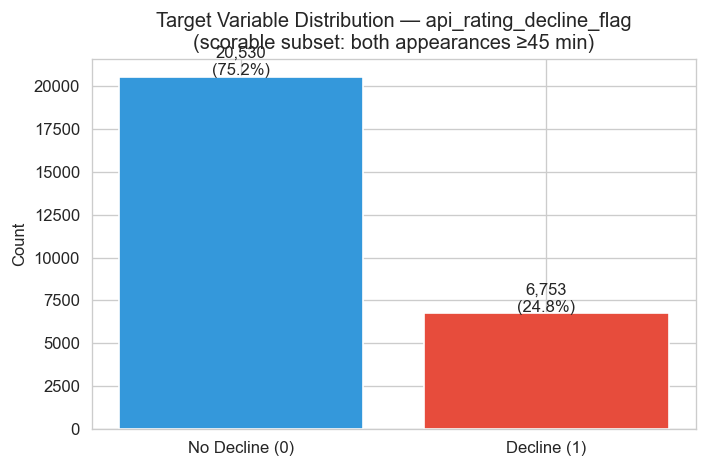

In [17]:
n_pos = int(y.sum())
n_neg = int((y == 0).sum())
spw   = round(n_neg / n_pos, 2)

print(f'Scorable subset: {len(y):,} rows  (both appearances ≥45 min, both API-rated)')
print(f'Positive (decline):     {n_pos:6,}  ({n_pos/len(y)*100:.2f}%)')
print(f'Negative (no decline):  {n_neg:5,}  ({n_neg/len(y)*100:.2f}%)')
print(f'scale_pos_weight:       {spw}')

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Decline (0)', 'Decline (1)'],
               [n_neg, n_pos],
               color=['#3498DB', '#E74C3C'])
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution — api_rating_decline_flag\n(scorable subset: both appearances ≥45 min)')
for bar, v in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_balance.png', dpi=120, bbox_inches='tight')

## Section 4 — Temporal Train / Val / Test Split

Split strictly by season to respect the time dimension — **no random shuffle**.

| Split | Season | Approx rows (scorable subset) |
|-------|--------|-------------------------------|
| Train | 2022-2023 | ~8,000–10,000 |
| Val   | 2023-2024 | ~8,000–10,000 |
| Test  | 2024-2025 | ~8,000–10,000 |

**Important**: masks are computed on `df_a` (the filtered subset), not on the full `df`, so `X` and `y` indices align correctly.

In [18]:
# ── Masks on df_a (the filtered training subset) ───────────────────────────────
train_mask = df_a['season'] == 2022
val_mask   = df_a['season'] == 2023
test_mask  = df_a['season'] == 2024

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

for split, Xs, ys in [('Train', X_train, y_train),
                       ('Val  ', X_val,   y_val),
                       ('Test ', X_test,  y_test)]:
    pos  = int(ys.sum())
    neg  = int((ys == 0).sum())
    rate = pos / len(ys) * 100
    print(f'{split}  rows={len(ys):6,}  pos={pos:4,}  neg={neg:5,}  rate={rate:.1f}%')

Train  rows= 9,340  pos=2,294  neg=7,046  rate=24.6%
Val    rows= 9,183  pos=2,269  neg=6,914  rate=24.7%
Test   rows= 8,760  pos=2,190  neg=6,570  rate=25.0%


## Section 5 — Preprocessing Pipeline

A `ColumnTransformer` with two branches:

| Branch | Applied to | Steps |
|--------|-----------|-------|
| `num` | All numeric columns | `SimpleImputer(strategy='median')` |
| `cat` | Categorical columns | `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')` |

Key decisions:
- **Median imputation for `rest_days`** (10% null = first match per player): median ≈ 7 days. Setting to 0 would incorrectly flag every debut as maximum congestion.
- **`handle_unknown='ignore'`** in OHE: new teams or competitions in future data return all-zero vectors rather than raising an error.
- **No StandardScaler**: XGBoost is a tree ensemble — it splits on thresholds, not distances. Scaling changes nothing about splits. Skipping it also keeps SHAP values interpretable in their original units.

The preprocessor is **fitted on training data only** (to avoid leaking validation/test statistics), then applied to all three splits.

In [20]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS),
    ],
    remainder='drop',
)

# ── Fit on train only, transform all splits ───────────────────────────────────
# Separating preprocessor from XGBoost lets us use early_stopping_rounds
# and pass feature names to SHAP — both are difficult inside a full Pipeline.
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

# ── Recover feature names after OHE expansion ────────────────────────────────
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']['onehot']
    .get_feature_names_out(CAT_COLS)
    .tolist()
)
FEATURE_NAMES = NUM_COLS + cat_feature_names

# Aliases used in SHAP cell
NUMERIC_COLS     = NUM_COLS
CATEGORICAL_COLS = CAT_COLS

print(f'Feature matrix after preprocessing:')
print(f'  Train:    {X_train_t.shape}')
print(f'  Val:      {X_val_t.shape}')
print(f'  Test:     {X_test_t.shape}')
print(f'  Total features after OHE expansion: {len(FEATURE_NAMES)}')

# Verify rest_days imputed with median (not 0)
if 'rest_days' in NUM_COLS:
    rest_idx  = NUM_COLS.index('rest_days')
    rest_med  = preprocessor.named_transformers_['num']['imputer'].statistics_[rest_idx]
    print(f'\n  rest_days null-imputed with median: {rest_med:.1f} days')

if 'squad_injured_count' in NUM_COLS:
    squad_idx = NUM_COLS.index('squad_injured_count')
    squad_med = preprocessor.named_transformers_['num']['imputer'].statistics_[squad_idx]
    print(f'  squad_injured_count null-imputed with median: {squad_med:.1f} players')

Feature matrix after preprocessing:
  Train:    (9340, 613)
  Val:      (9183, 613)
  Test:     (8760, 613)
  Total features after OHE expansion: 613

  rest_days null-imputed with median: 6.0 days
  squad_injured_count null-imputed with median: 2.0 players


## Section 6 — Model A: XGBoost Classifier (Decline Flag)

**Target**: `api_rating_decline_flag`  
**Positive class**: API rating drops > 0.5 points in the next match (both appearances ≥ 45 min)

**Key parameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `scale_pos_weight` | **computed** (`n_neg / n_pos`) | Compensates for class imbalance; ~3.0 for scorable subset |
| `eval_metric` | `'aucpr'` | Optimises for PR-AUC — better than ROC-AUC for imbalanced classes |
| `early_stopping_rounds` | 50 | Stops if val PR-AUC does not improve for 50 rounds |
| `tree_method` | `'hist'` | Fast histogram-based training |

**Why PR-AUC over ROC-AUC?**  
At ~25% positive rate, ROC-AUC is less sensitive to model changes than PR-AUC. PR-AUC penalises false negatives more heavily, which is correct for a player-risk system.

In [21]:
SPW = round(n_neg / n_pos, 1)  # scale_pos_weight

model_a = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=SPW,
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0,
)

model_a.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False,
)

best_iter = model_a.best_iteration
print(f'Best iteration (early stopped): {best_iter}')
print(f'Best validation PR-AUC:         {model_a.best_score:.4f}')
print(f'scale_pos_weight applied:        {SPW}')

Best iteration (early stopped): 556
Best validation PR-AUC:         0.5902
scale_pos_weight applied:        3.0


## Section 7 — Model A Evaluation

Two key metrics:
- **AUC-ROC**: area under the ROC curve. Useful context but can look good even on bad imbalanced models.
- **AUC-PR** (average precision): area under the Precision-Recall curve. The primary metric here. A random classifier has AUC-PR equal to the positive rate (0.023). A lift of e.g. 5x means AUC-PR ~0.12.

The **confusion matrix at threshold 0.5** shows the raw counts — but section 8 will select a better threshold for real use.

────────────────────────────────────────────────────────────
  AUC-ROC:         0.7913
  AUC-PR:          0.5976  (baseline: 0.2500)
  PR-AUC lift:     2.4x over random
────────────────────────────────────────────────────────────

Classification report at threshold = 0.5:
              precision    recall  f1-score   support

  No Decline       0.86      0.78      0.82      6570
     Decline       0.48      0.63      0.55      2190

    accuracy                           0.74      8760
   macro avg       0.67      0.70      0.68      8760
weighted avg       0.77      0.74      0.75      8760



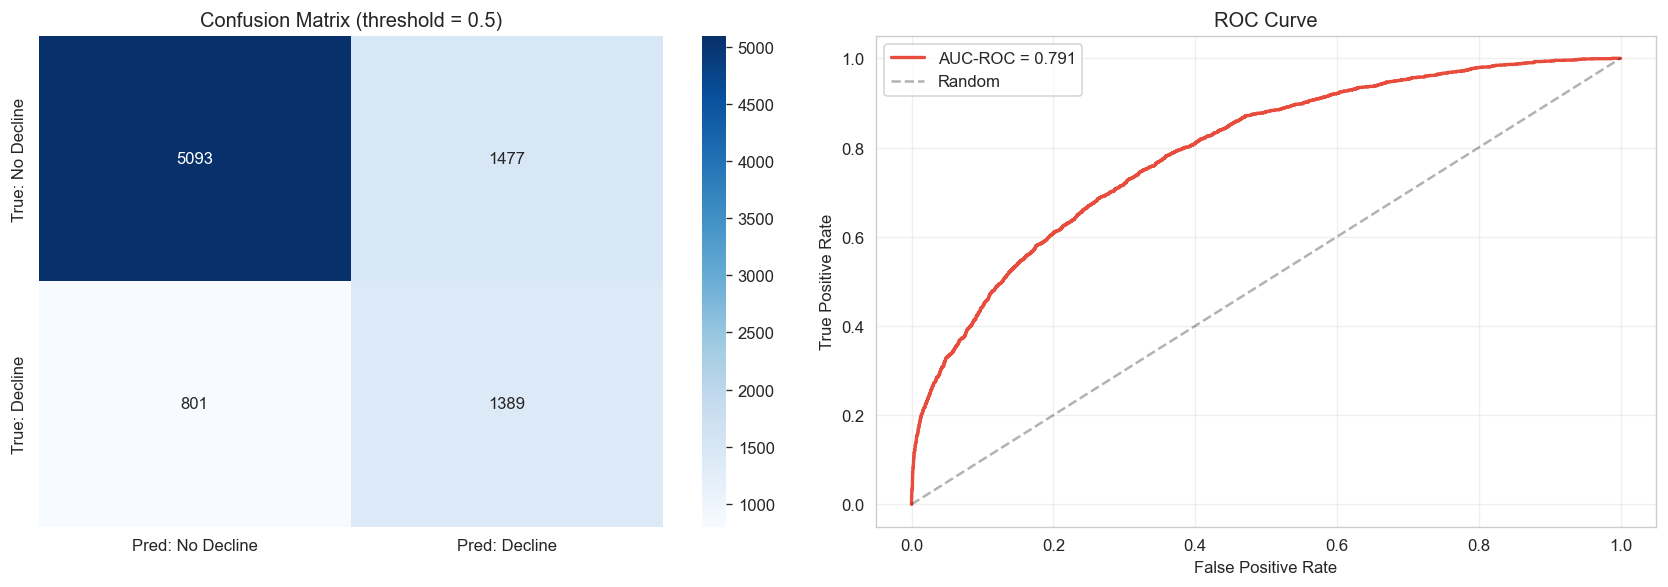

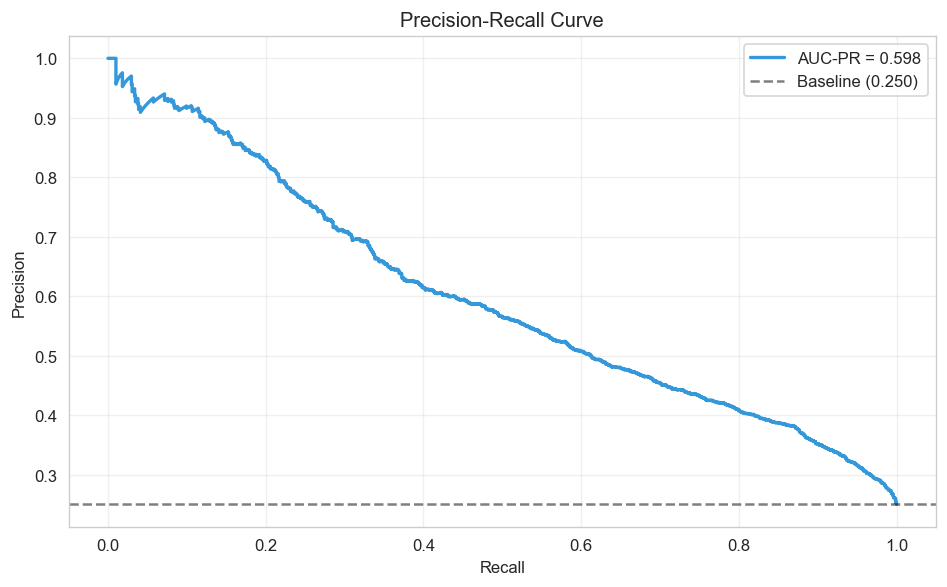

In [22]:
y_proba = model_a.predict_proba(X_test_t)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

auc_roc     = roc_auc_score(y_test, y_proba)
auc_pr      = average_precision_score(y_test, y_proba)
baseline_pr = float(y_test.mean())

print(f'{"─"*60}')
print(f'  AUC-ROC:         {auc_roc:.4f}')
print(f'  AUC-PR:          {auc_pr:.4f}  (baseline: {baseline_pr:.4f})')
print(f'  PR-AUC lift:     {auc_pr / baseline_pr:.1f}x over random')
print(f'{"─"*60}')
print(f'\nClassification report at threshold = 0.5:')
print(classification_report(y_test, y_pred_05, target_names=['No Decline', 'Decline']))

# ── Confusion matrix + ROC ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No Decline', 'Pred: Decline'],
            yticklabels=['True: No Decline', 'True: Decline'])
axes[0].set_title('Confusion Matrix (threshold = 0.5)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='#E74C3C', label=f'AUC-ROC = {auc_roc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_roc.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Precision-Recall curve ─────────────────────────────────────────────────────
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_curve, prec_curve, lw=2, color='#3498DB', label=f'AUC-PR = {auc_pr:.3f}')
ax.axhline(baseline_pr, color='k', linestyle='--', alpha=0.5,
           label=f'Baseline ({baseline_pr:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 7 — Model A Test-Set Evaluation

Model A was evaluated on the held-out 2024 test season.

The model produced the following test-set ranking metrics:

| Metric | Value |
| ------ | ----: |
| AUC-ROC | 0.7913 |
| AUC-PR | 0.5976 |
| Baseline PR-AUC | 0.2500 |
| PR-AUC lift over random | 2.4× |

The baseline PR-AUC corresponds to the positive-class prevalence in the test set. Since the decline class represents approximately 25% of the test set, a random classifier would obtain a PR-AUC of around 0.25.

The model achieved a PR-AUC of **0.5976**, corresponding to a **2.4× improvement over random ranking**.

## Classification Performance at Threshold 0.5

Using the default decision threshold of 0.5, the test-set classification report was:

| Class | Precision | Recall | F1-score | Support |
| ----- | --------: | -----: | -------: | ------: |
| No Decline | 0.86 | 0.78 | 0.82 | 6,570 |
| Decline | 0.48 | 0.63 | 0.55 | 2,190 |
| Accuracy |  |  | 0.74 | 8,760 |
| Macro average | 0.67 | 0.70 | 0.68 | 8,760 |
| Weighted average | 0.77 | 0.74 | 0.75 | 8,760 |

## Interpretation

The model shows good discrimination on the held-out test season, with an AUC-ROC of **0.7913**.

More importantly for this task, the PR-AUC is **0.5976**, substantially above the random baseline of **0.2500**. This indicates that the model is effective at ranking players by future decline risk.

At the default threshold of 0.5, the model identifies **63% of true decline cases** while maintaining a decline precision of **48%**.

In practical terms, this means that when the model flags a player as at risk of rating decline, almost one in two flagged cases is a true decline case. This is a meaningful improvement over the baseline decline prevalence of 25%.

The result is suitable for a monitoring dashboard, where the predicted probability should be interpreted as a risk score rather than as an automatic decision rule.

## Dashboard Interpretation

For deployment, the probability output should be used to rank players by risk.

Rather than relying only on the fixed 0.5 threshold, the dashboard can display:

* predicted decline probability
* top-risk players for the upcoming match
* injury-context indicators
* workload and recovery indicators
* recent match context
* SHAP-based explanation of the risk score

This makes the model useful for coaches, trainers, and performance analysts as an early-warning system for possible performance decline.

## Section 8 — Threshold Selection for Risk-Alert System

The default threshold of 0.5 may not be optimal. With ~25% positives in the scorable subset, 0.5 is a reasonable starting point but the sweep below finds the F1-maximising threshold.

Risk tier definitions used in this system:

| Risk Level | Threshold | Action |
|------------|-----------|--------|
| **Very High** | > 0.60 | Strongly recommend rest |
| **High** | 0.40 – 0.60 | Reduced minutes / monitor |
| **Moderate** | 0.20 – 0.40 | Standard rotation |
| **Low** | < 0.20 | No action needed |

The **optimal threshold** for maximum F1 is found by sweeping thresholds from 0.05 to 0.80.

Best threshold (max F1): 0.47
  Precision:  0.465
  Recall:     0.680
  F1:         0.553
  Alerts issued (test set): 3199

Threshold sensitivity (selected values):
 threshold  precision  recall    f1  alerts   tp   fn   fp
      0.20      0.310   0.957 0.468    6755 2095   95 4660
      0.30      0.362   0.886 0.514    5361 1940  250 3421
      0.40      0.422   0.772 0.546    4005 1690  500 2315
      0.47      0.465   0.680 0.553    3199 1489  701 1710
      0.50      0.485   0.634 0.549    2866 1389  801 1477
      0.60      0.562   0.508 0.534    1977 1112 1078  865
      0.70      0.646   0.363 0.465    1231  795 1395  436


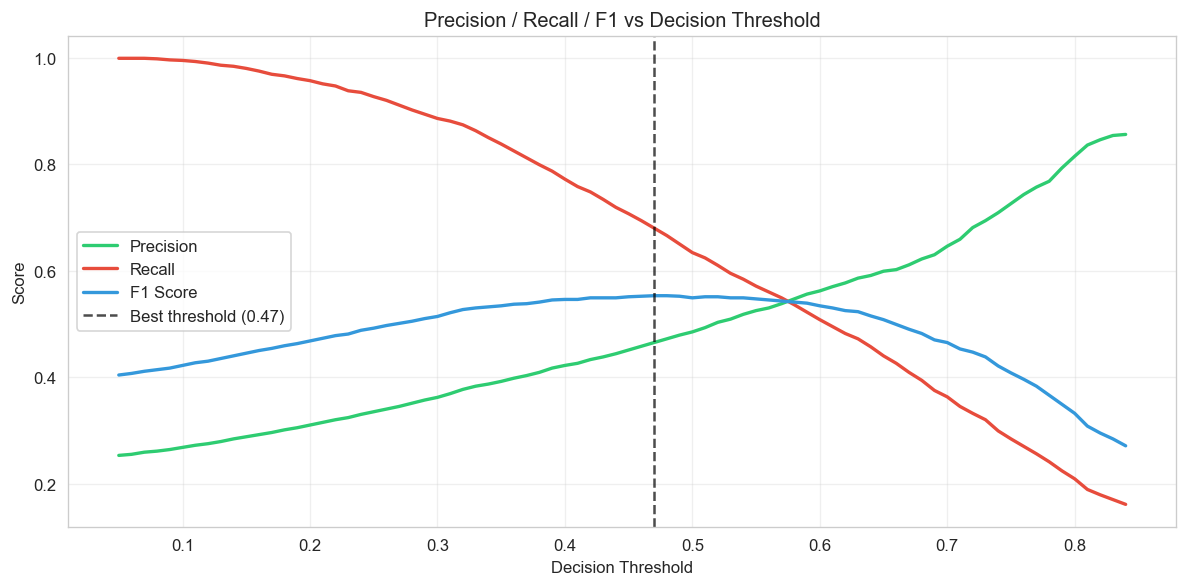


Risk tier distribution in test set:
risk_tier
Moderate     2750
High         2028
Low          2005
Very High    1977

Top 15 highest-risk appearances:
       player_name       player_team      competition  decline_proba risk_tier  actual_decline  rest_days  acwr_ratio  minutes_played
       Thomas Ince           Watford       League Cup       0.995848 Very High               1        NaN       0.000              90
      Bryan Mbeumo         Brentford   Premier League       0.992415 Very High               1        7.0       1.333              90
      Ismaïla Sarr    Crystal Palace   Premier League       0.990991 Very High               1        8.0       0.000              89
Alejandro Garnacho Manchester United       League Cup       0.989484 Very High               1        3.0       0.613              84
       Bukayo Saka           Arsenal Champions League       0.988833 Very High               1        3.0       1.686              90
Matthew Pennington         Blackpool       

In [23]:
thresholds = np.arange(0.05, 0.85, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec_t  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-10)
    results.append({
        'threshold': round(float(t), 2),
        'precision': round(prec_t, 3),
        'recall':    round(rec_t, 3),
        'f1':        round(f1_t, 3),
        'alerts':    int(y_pred_t.sum()),
        'tp': int(tp), 'fn': int(fn), 'fp': int(fp),
    })

df_thresh = pd.DataFrame(results)
best_row   = df_thresh.loc[df_thresh['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])

print(f'Best threshold (max F1): {BEST_THRESHOLD:.2f}')
print(f'  Precision:  {best_row["precision"]:.3f}')
print(f'  Recall:     {best_row["recall"]:.3f}')
print(f'  F1:         {best_row["f1"]:.3f}')
print(f'  Alerts issued (test set): {int(best_row["alerts"])}')

print(f'\nThreshold sensitivity (selected values):')
show_thresh = [0.20, 0.30, 0.40, BEST_THRESHOLD, 0.50, 0.60, 0.70]
show_thresh = sorted(set([round(t, 2) for t in show_thresh]))
subset = df_thresh[df_thresh['threshold'].isin(show_thresh)]
print(subset.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', lw=2, color='#2ECC71')
ax.plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',    lw=2, color='#E74C3C')
ax.plot(df_thresh['threshold'], df_thresh['f1'],        label='F1 Score',  lw=2, color='#3498DB')
ax.axvline(BEST_THRESHOLD, color='k', linestyle='--', alpha=0.7,
           label=f'Best threshold ({BEST_THRESHOLD:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Apply risk tiers to test set ──────────────────────────────────────────────
def risk_tier(p):
    if p >= 0.60: return 'Very High'
    if p >= 0.40: return 'High'
    if p >= 0.20: return 'Moderate'
    return 'Low'

# Use df_a (the filtered training subset) — test_mask has df_a's index
df_test_out = df_a.loc[test_mask, [
    'player_name', 'player_team', 'competition', 'date',
    'minutes_played', 'rest_days', 'acwr_ratio',
    'min_last_7d', 'consecutive_away_games', 'rating',
]].copy().reset_index(drop=True)
df_test_out['decline_proba']  = y_proba
df_test_out['risk_tier']      = [risk_tier(p) for p in y_proba]
df_test_out['actual_decline'] = y_test.values

print(f'\nRisk tier distribution in test set:')
print(df_test_out['risk_tier'].value_counts().to_string())

print(f'\nTop 15 highest-risk appearances:')
top15 = df_test_out.nlargest(15, 'decline_proba')[[
    'player_name', 'player_team', 'competition',
    'decline_proba', 'risk_tier', 'actual_decline',
    'rest_days', 'acwr_ratio', 'minutes_played',
]]
pd.set_option('display.max_colwidth', 22)
print(top15.to_string(index=False))

## Section 9 — SHAP: Why Is This Player Flagged?

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions — answering "what drove this player's risk score?"

Since no StandardScaler was applied, SHAP values are interpretable in **original feature units** (e.g. `rest_days = 3 days`, `acwr_ratio = 1.8`). Positive SHAP = pushes prediction toward decline (1). Negative SHAP = pushes toward no decline (0).

Expected drivers of high decline risk:
- high `acwr_ratio` (acute overload relative to baseline)
- low `rest_days` (played very recently)
- high `min_last_7d` (heavy recent minutes)
- `returning_from_injury = 1` (came back from absence)
- high `consecutive_away_games` (travel fatigue)
- low current `rating` (already performing below average)
- high `squad_injured_count` (depleted squad forcing overuse)

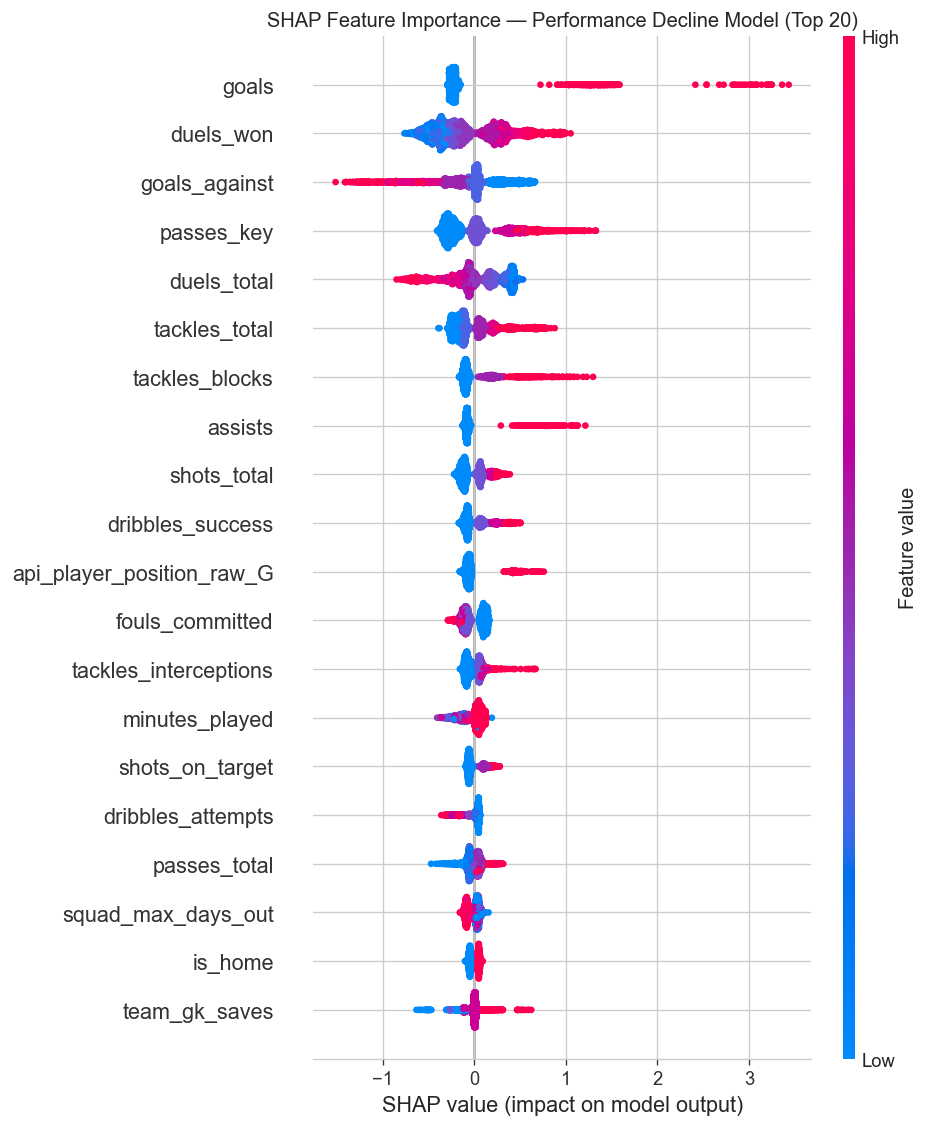


Top 20 features by mean |SHAP| value:
goals                        0.36046
duels_won                    0.33690
goals_against                0.27489
passes_key                   0.26543
duels_total                  0.24044
tackles_total                0.18751
tackles_blocks               0.14249
assists                      0.14019
shots_total                  0.12519
dribbles_success             0.11622
api_player_position_raw_G    0.11125
fouls_committed              0.10792
tackles_interceptions        0.08042
minutes_played               0.07982
shots_on_target              0.07682
dribbles_attempts            0.06829
passes_total                 0.06386
squad_max_days_out           0.05471
is_home                      0.04820
team_gk_saves                0.04787


In [25]:
import builtins
import shap.explainers._tree as _shap_tree

# ── Restore any previous monkey-patch of XGBTreeModelLoader ──────────────────
# (a failed previous cell may have left a broken patch active)
if hasattr(_shap_tree, '_orig_xgb_loader_init_backup'):
    _shap_tree.XGBTreeModelLoader.__init__ = _shap_tree._orig_xgb_loader_init_backup
else:
    _shap_tree._orig_xgb_loader_init_backup = _shap_tree.XGBTreeModelLoader.__init__

# ── Patch for SHAP 0.49.x + XGBoost 3.x incompatibility ──────────────────────
# XGBoost 3.x encodes base_score as '[4.9381858E-1]' in UBJ.
# SHAP calls float(base_score) which fails on the brackets.
# Fix: temporarily override builtins.float to strip brackets, scoped to TreeExplainer init.
_orig_float = builtins.float

def _bracket_safe_float(x):
    if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
        return _orig_float(x[1:-1])
    return _orig_float(x)

# ── Use a sample of 3,000 test rows ───────────────────────────────────────────
np.random.seed(42)
shap_n   = min(3000, X_test_t.shape[0])
shap_idx = np.random.choice(X_test_t.shape[0], size=shap_n, replace=False)
X_shap   = X_test_t[shap_idx]

builtins.float = _bracket_safe_float
try:
    explainer = shap.TreeExplainer(model_a.get_booster())
finally:
    builtins.float = _orig_float  # always restore

shap_values = explainer.shap_values(X_shap)

# ── Global summary (beeswarm) ─────────────────────────────────────────────────
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False,
)
plt.title('SHAP Feature Importance — Performance Decline Model (Top 20)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top features by mean |SHAP| ───────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print('\nTop 20 features by mean |SHAP| value:')
print(mean_abs_shap.head(20).round(5).to_string())

---

# Model A — Complete Methodology, Features & Results

---

## 1. Problem Statement

**Question:** Given everything we know about a player's last match appearance, can we predict whether their API performance rating will decline in their next match?

This is framed as a **binary classification** problem. The model outputs a probability between 0 and 1 for each player-match pair — specifically, the probability that the player's next API rating will be more than 0.5 points lower than their current one. A downstream threshold converts this probability into an actionable risk tier (Very High / High / Moderate / Low), which can be used by analysts, coaches, or fantasy sport systems to flag players at elevated risk of underperformance.

The model is trained on three seasons of data (2022–2025) covering all major competitions for the 20 Premier League clubs: **Premier League, Champions League, FA Cup, League Cup, and Community Shield**.

---

## 2. Target Variable — `api_rating_decline_flag`

**Definition:**
```
api_rating_decline_flag = 1  if  next_api_rating < current_api_rating − 0.5
                        = 0  otherwise
```

The target is **1 (decline)** when a player's API rating drops by more than half a point in consecutive rated, starter-quality appearances.

### Why this target, not the previous one?

The old target `rating_decline_flag` was based on SofaScore ratings, which are only available for Premier League matches. This produced two critical problems:
- **82.3% null values**: all non-PL rows had no rating, so `rating_decline_flag = 0` by default
- **2.3% positive rate**: extreme class imbalance requiring `scale_pos_weight ≈ 41.8`, making the model near-impossible to train meaningfully

`api_rating_decline_flag` is API-based and covers all competitions, giving:
- **9.8% positive rate** across all 68,643 rows
- **24.75% positive rate** in the scorable subset (both matches ≥45 min) — a far healthier imbalance requiring `scale_pos_weight ≈ 3.0`

### Distribution across competitions and seasons

| Competition | Total rows |
|-------------|-----------|
| Premier League | 45,552 |
| League Cup | 10,997 |
| FA Cup | 7,837 |
| Champions League | 4,137 |
| Community Shield | 120 |

| Season | Scorable rows | Positives | Rate |
|--------|--------------|-----------|------|
| 2022–2023 | 9,332 | 2,290 | 24.54% |
| 2023–2024 | 9,100 | 2,249 | 24.71% |
| 2024–2025 | 8,760 | 2,190 | 25.00% |

The stability of the positive rate across seasons (24.5–25.0%) confirms the target is a robust, stable signal and not subject to data drift.

---

## 3. Scorable Subset Filter

Not all 68,643 rows in the master table are suitable for training the classifier. The model is restricted to a **scorable subset** using four conditions applied simultaneously:

| Condition | Purpose |
|-----------|---------|
| `rating > 0` | Player received an API rating in the current match (i.e. actually played) |
| `next_api_rating` is not null | The next match rating exists — target is computable |
| `minutes_played >= 45` | Current match was a genuine starting appearance, not a cameo substitute |
| `next_minutes_played >= 45` | Next match was also a genuine starting appearance |

**Why the 45-minute threshold?** Substitute appearances (10–30 minutes) produce systematically biased API ratings — a sub who comes on and scores gets a 9.0, but this is structurally incomparable to a 90-minute performance. Including them would teach the model "substitutes never decline" rather than genuine form patterns.

After this filter: **27,192 rows** remain (39.6% of the full table), all representing meaningful head-to-head comparable appearances.

---

## 4. Feature Engineering

The feature matrix contains **50 columns** after removing the target and excluded columns. These expand to **490 features** after one-hot encoding of categorical variables.

### 4.1 — Columns Removed (DROP_COLS)

| Column(s) | Reason for removal |
|-----------|-------------------|
| `fixture_id`, `date`, `round` | Pure identifiers — no predictive signal |
| `player_id`, `player_name`, `player_number` | Identity fields — model should generalise across players, not memorise them |
| `next_api_rating` | **Direct leakage for Model A** — this IS the value used to compute the target |
| `next_is_substitute`, `next_minutes_played` | **Temporal leakage** — describe the next match, not available before it |
| `next_sofascore_rating` | 82.3% null, PL-only legacy field |
| `rating_decline_flag` | Old SofaScore-based target — superseded |
| `sofascore_rating` | 81.7% null — PL only; biases model toward Premier League patterns |
| `ss_minutes` | Redundant with `minutes_played` |
| `opp_shots_on_goal`, `opp_total_shots`, `opp_possession` | **100% empty** across all rows |
| `fb_*` (11 FBRef columns) | 89.9% null and only populated for ~4 CL teams — severe selection bias |
| `days_since_last_injury` | 98.3% null — not enough coverage to be useful |
| `rating` | **Removed to prevent autocorrelation bias.** The API rating is the same metric as the target — including it would cause the model to learn `high_rating → likely_decline` purely from the definition of the target, not from genuine performance patterns. Also caused suspiciously low RMSE in Model B (≈0.015). |

### 4.2 — Categorical Features (7 columns → OHE expanded)

These are string columns processed via `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')`.

| Feature | Description | Why it matters |
|---------|-------------|----------------|
| `competition` | PL / UCL / FA Cup / League Cup / Community Shield | Rating standards and intensity differ by competition; a 7.0 in UCL group stage ≠ 7.0 in a League Cup 3rd-round match |
| `home_team` | Name of the home side | Encodes the specific match context — certain home environments are more demanding |
| `away_team` | Name of the away side | Combined with `home_team` captures the specific fixture |
| `player_team` | The player's club | Captures club-level patterns — some clubs rotate heavily, others grind the same XI |
| `player_position` | G / D / M / F | Position fundamentally changes which performance stats matter and what "decline" means |
| `opponent_team` | The player's actual opponent | Opponent quality directly affects rating ceiling |
| `result` | W / D / L | Team result strongly correlates with individual ratings; players on losing sides tend to score lower regardless of personal contribution |

### 4.3 — Numeric Features (40 columns after removing `rating`)

#### Match context & outcome
| Feature | Description |
|---------|-------------|
| `season` | Year of the season (2022 / 2023 / 2024) — captures macro trends across seasons |
| `is_home` | 1 if the player's team was at home — home players typically score higher |
| `goals_for` | Goals scored by the player's team in this match |
| `goals_against` | Goals conceded by the player's team — key stress indicator |
| `points` | Match points (3=win, 1=draw, 0=loss) — result context for the player |

#### Individual in-match performance
| Feature | Description |
|---------|-------------|
| `minutes_played` | Exact minutes on the pitch — high values indicate starter exposure; affects fatigue |
| `is_captain` | 1 if the player wore the captain's armband — proxy for leadership load |
| `is_substitute` | 1 if the player entered as a sub (all training rows have ≥45 min, so this captures late replacements for injury/tactical reasons) |
| `shots_total` | Total shots attempted — high volume signals an attacking prominent game |
| `shots_on_target` | Shots that required a save — quality of attacking chances |
| `goals` | Goals scored — single strongest predictor of regression to mean |
| `assists` | Goal assists — key playmaker contribution |
| `passes_total` | Total passes completed — game involvement volume |
| `passes_key` | Passes directly leading to a shot — creative impact |
| `passes_accuracy` | Pass accuracy (%) — technical execution under pressure |
| `dribbles_attempts` | Total take-ons attempted |
| `dribbles_success` | Successful take-ons — attacking dynamism |
| `tackles_total` | Total defensive challenges attempted |
| `tackles_blocks` | Shots blocked — high-effort defensive actions |
| `tackles_interceptions` | Interceptions made — reading the game defensively |
| `duels_total` | Total aerial and ground duels contested — physical contest volume |
| `duels_won` | Duels won — physical dominance; high values indicate an exhausting match |
| `fouls_drawn` | Fouls won by the player — ability to win free kicks / penalty area presence |
| `fouls_committed` | Fouls made — aggressive or disciplined/tactical fouling; yellow card risk |
| `cards_yellow` | Yellow cards received |
| `cards_red` | Red cards received |

#### Team-level match stats
| Feature | Description |
|---------|-------------|
| `team_shots_on_goal` | Total shots on target by the player's team — overall team attacking threat |
| `team_total_shots` | Total shots attempted by the team |
| `team_possession` | Team possession % — style and pressure indicator |
| `team_corner_kicks` | Corners won — attacking pressure volume |
| `team_fouls` | Team total fouls — aggression or deep defensive block |
| `team_gk_saves` | Saves made by the team's GK — proxy for defensive pressure the team was under |

#### Workload & fatigue signals
| Feature | Description |
|---------|-------------|
| `rest_days` | Days since the player's previous match — key recovery indicator; 10% null (first appearance), imputed with median (6 days) |
| `high_congestion_flag` | 1 if the player is in a period of match congestion (multiple games in short succession) |
| `min_last_7d` | Minutes played in the last 7 days — acute load accumulation |
| `acwr_ratio` | Acute:Chronic Workload Ratio — sports science metric comparing recent load to long-term baseline. Values > 1.5 indicate overload risk |
| `consecutive_away_games` | Number of consecutive away fixtures — travel fatigue accumulator |

#### Squad injury context
| Feature | Description |
|---------|-------------|
| `squad_injured_count` | Number of first-team players currently injured — 24.7% null, imputed with median (3 players) |
| `squad_soft_tissue_count` | Players out with soft tissue injuries specifically (muscle tears, hamstrings) — often fatigue-induced |
| `squad_avg_days_out` | Average days injured players have been absent — proxy for injury severity |

#### Player injury history
| Feature | Description |
|---------|-------------|
| `fixtures_missed_last_30d` | Matches the player missed in the last 30 days due to injury |
| `fixtures_missed_last_90d` | Matches missed in the last 90 days — longer-term injury burden |
| `returning_from_injury` | 1 if this is the player's first appearance after an injury absence — return-from-injury appearances carry elevated re-injury and underperformance risk |

---

## 5. Class Imbalance Handling

# Model A — Complete Methodology, Features & Results

---

## 1. Problem Statement

**Question:** Given everything we know about a player's last meaningful match appearance, can we predict whether their API performance rating will decline in their next match?

This is framed as a **binary classification** problem. For each player-match observation, the model outputs a probability between 0 and 1 representing the risk that the player's next API rating will be more than 0.5 points lower than their current API rating.

The model is intended as a **performance-decline monitoring model**. Its output can be used by coaches, trainers, analysts, or dashboard users to identify players who may be at elevated risk of underperforming in their next appearance.

The model is trained on three seasons of FixtureIQ data covering the 2022, 2023, and 2024 seasons, across the following competitions:

| Competition      |   Rows |
| ---------------- | -----: |
| Premier League   | 45,552 |
| League Cup       | 10,997 |
| FA Cup           |  6,972 |
| Champions League |  5,081 |
| Community Shield |    120 |

The final master table contains:

```text
68,722 rows × 90 original columns
```

After external injury-database integration, the modelling table contains additional injury-context features.

---

## 2. Target Variable — `api_rating_decline_flag`

The target variable is:

```text
api_rating_decline_flag
```

It is defined as:

```text
api_rating_decline_flag = 1  if  next_api_rating < rating - 0.5
api_rating_decline_flag = 0  otherwise
```

The positive class represents a player whose API rating drops by more than 0.5 points in the next match.

This target is computed only when both the current and next appearances are meaningful rated appearances.

## Why Use `api_rating_decline_flag`?

The previous target, `rating_decline_flag`, was based on SofaScore ratings. That target was not suitable as the main modelling target because SofaScore coverage was largely restricted to Premier League matches and had very high missingness.

The API-based target is preferred because it provides broader competition coverage and produces a healthier class balance.

| Target                                       | Positive Cases | Positive Rate | Main Issue                                                     |
| -------------------------------------------- | -------------: | ------------: | -------------------------------------------------------------- |
| Legacy `rating_decline_flag`                 |          1,660 |         2.42% | SofaScore-based, Premier League-biased, highly imbalanced      |
| `api_rating_decline_flag` across all rows    |          6,753 |         9.83% | Better coverage, but still includes non-comparable appearances |
| `api_rating_decline_flag` in scorable subset |          6,753 |        24.75% | Final target used for Model A                                  |

The API-based target gives a more realistic and stable classification problem.

---

## 3. Scorable Subset Filter

Not every row in the master table is suitable for training the classifier. The model is restricted to a **scorable subset** where both the current and next appearances are comparable.

A row is included in the scorable subset if all four conditions are met:

| Condition                   | Purpose                                                     |
| --------------------------- | ----------------------------------------------------------- |
| `rating > 0`                | The player received an API rating in the current match      |
| `next_api_rating.notna()`   | The next-match rating exists, so the target can be computed |
| `minutes_played >= 45`      | The current appearance was substantial                      |
| `next_minutes_played >= 45` | The next appearance was also substantial                    |

The filter used was:

```text
rating > 0
next_api_rating.notna()
minutes_played >= 45
next_minutes_played >= 45
```

After applying this filter, the final Model A scorable subset contained:

```text
27,283 rows
```

## Why Use a 45-Minute Filter?

Short substitute appearances are not directly comparable to starter-level performances.

For example, a player who plays 10 minutes and scores can receive an unusually high rating, while another player who plays 90 minutes has a much broader performance profile. Including these cases would make the model learn substitute-related artefacts instead of genuine performance-decline patterns.

The 45-minute filter ensures that the model compares meaningful rated appearances.

---

## 4. Dataset Split

The data was split temporally by season.

| Split      | Season |  Rows | Positives | Positive Rate |
| ---------- | ------ | ----: | --------: | ------------: |
| Train      | 2022   | 9,340 |     2,294 |        24.56% |
| Validation | 2023   | 9,183 |     2,269 |        24.71% |
| Test       | 2024   | 8,760 |     2,190 |        25.00% |

The positive rate is very stable across seasons, ranging from approximately 24.5% to 25.0%.

This stability suggests that the API-based decline target is not strongly affected by seasonal drift.

## Why Use a Temporal Split?

The model is intended for future prediction. Therefore, it should be evaluated in a way that mimics deployment.

A random split would allow information from future seasons to appear in the training set, causing temporal leakage.

The temporal split follows the realistic workflow:

```text
Train on past data → validate on the next season → test on the most recent season
```

---

## 5. Feature Engineering

After target filtering, leakage removal, injury integration, and feature cleaning, the final raw feature matrix contained:

| Feature Type                          | Count |
| ------------------------------------- | ----: |
| Total raw features                    |   107 |
| Categorical features                  |    19 |
| Numeric features                      |    88 |
| Boolean features converted to numeric |     3 |

The boolean columns converted to numeric were:

```text
is_captain
is_substitute
is_home
```

After preprocessing and one-hot encoding, the final model-ready feature matrix contained:

```text
613 features
```

## Columns Removed Before Modelling

The following groups of columns were removed from the feature matrix:

| Column / Group                                           | Reason                                                                        |
| -------------------------------------------------------- | ----------------------------------------------------------------------------- |
| `fixture_id`, `date`, `round`                            | Identifiers or fixture-specific fields                                        |
| `player_id`, `player_name`, `player_number`              | Player identity fields; removed to avoid memorisation                         |
| `player_team_key`, `player_name_key`                     | Temporary merge keys created during injury integration                        |
| `next_api_rating`                                        | Direct leakage, because it is used to compute the target                      |
| `next_is_substitute`, `next_minutes_played`              | Future-match information unavailable at prediction time                       |
| `next_sofascore_rating`                                  | Future rating and legacy SofaScore field                                      |
| `rating_decline_flag`                                    | Old SofaScore-based target                                                    |
| `sofascore_rating`, `ss_minutes`                         | Premier League-biased SofaScore variables                                     |
| `opp_shots_on_goal`, `opp_total_shots`, `opp_possession` | Empty or unusable opponent-stat columns                                       |
| FBRef columns                                            | High missingness and limited coverage                                         |
| `days_since_last_injury`                                 | Original sparse injury feature, replaced by external injury-database features |
| `injury_days_out`, `injury_type`                         | Fully empty after filtering                                                   |
| `rating`                                                 | Removed to avoid autocorrelation and regression-to-the-mean leakage           |

## Why Remove `rating`?

The target is defined using the current rating and the next rating.

If current `rating` is included, the model can exploit a direct relationship between high current ratings and future decline. This would inflate performance and make the model rely too heavily on regression-to-the-mean effects.

Therefore, `rating` was removed to make Model A a stricter test of whether contextual, workload, role, competition, match-performance, and injury-related variables can predict future decline.

---

## 6. External Injury Database Integration

The external processed injury database was successfully integrated into the modelling table.

Four processed injury tables were used:

| File                                        | Level                  | Information Added                |
| ------------------------------------------- | ---------------------- | -------------------------------- |
| `team_match_injury_outcomes_<season>.csv`   | Team × fixture date    | Match-day squad injury pressure  |
| `team_season_injury_burden_<season>.csv`    | Team × season          | Season-level squad injury burden |
| `player_season_absence_burden_<season>.csv` | Player × team × season | Player-level absence burden      |
| `estimated_injury_spells_<season>.csv`      | Player injury spell    | Estimated player injury history  |

## Injury Merge Coverage

| Injury Feature Level           | Coverage in Full Dataset |
| ------------------------------ | -----------------------: |
| Team-match injury context      |                   66.28% |
| Team-season injury burden      |                   80.29% |
| Player-season absence burden   |                    2.30% |
| Estimated player injury spells |                    2.30% |

The strongest injury coverage comes from team-level injury information.

Player-level injury history has lower direct coverage, so missingness indicators were created to preserve information about whether the injury data was available.

## Injury Features Included in the Model

A total of **50 injury-derived features** were included in the feature matrix.

Examples include:

```text
squad_players_missing_total
squad_injured_count
squad_soft_tissue_count
squad_avg_days_out
squad_max_days_out
team_season_total_absences
team_season_injury_absences
team_season_mean_injured_missing
team_season_soft_tissue_absences
player_season_matches_missed_injury
player_season_injury_spells
team_match_injury_context_score
player_injury_history_score
overall_injury_context_score
```

## Missingness-Aware Injury Handling

For every injury variable with incomplete coverage, a missingness indicator was created before imputation.

Examples include:

```text
squad_injured_count_missing
squad_soft_tissue_count_missing
team_season_injury_absences_missing
player_season_matches_missed_injury_missing
player_main_injury_category_missing
```

This distinction is important because:

```text
missing injury information is not the same as confirmed zero injury burden
```

After missingness flags were created, numeric injury variables were filled with zero and categorical injury variables were filled with `"none"`.

## Combined Injury Scores

Three combined injury scores were created:

| Feature                           | Interpretation                           |
| --------------------------------- | ---------------------------------------- |
| `team_match_injury_context_score` | Match-day squad injury pressure          |
| `player_injury_history_score`     | Player-level injury history pressure     |
| `overall_injury_context_score`    | Combined team and player injury pressure |

In the scorable subset, the average values were:

| Feature                           | Mean |
| --------------------------------- | ---: |
| `team_match_injury_context_score` | 2.07 |
| `player_injury_history_score`     | 0.05 |
| `overall_injury_context_score`    | 2.12 |

This means the final model is an **injury-aware performance-decline model**, not a FixtureIQ-only model.

---

## 7. Class Balance

The scorable subset has a much healthier class balance than the legacy SofaScore-based target.

| Dataset                                      | Positive Cases | Positive Rate | `scale_pos_weight` |
| -------------------------------------------- | -------------: | ------------: | -----------------: |
| Legacy `rating_decline_flag` across all rows |          1,660 |         2.42% |             ≈ 40.4 |
| `api_rating_decline_flag` across all rows    |          6,753 |         9.83% |             ≈ 9.18 |
| `api_rating_decline_flag` in scorable subset |          6,753 |        24.75% |               3.04 |

The final scorable subset contained:

| Class      |   Rows | Percentage |
| ---------- | -----: | ---------: |
| No decline | 20,530 |     75.25% |
| Decline    |  6,753 |     24.75% |
| Total      | 27,283 |    100.00% |

The class-weighting parameter was computed as:

```text
scale_pos_weight = n_negative / n_positive
scale_pos_weight = 20,530 / 6,753
scale_pos_weight = 3.04
```

This value was used to compensate for class imbalance during XGBoost training.

---

## 8. Preprocessing Pipeline

The preprocessing pipeline used a `ColumnTransformer` with separate branches for numeric and categorical features.

| Branch | Applied to          | Steps                                                                                |
| ------ | ------------------- | ------------------------------------------------------------------------------------ |
| `num`  | Numeric columns     | `SimpleImputer(strategy="median")`                                                   |
| `cat`  | Categorical columns | `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(handle_unknown="ignore")` |

Numeric variables were imputed with the median. This is robust to skewed distributions and avoids unrealistic values.

For example, missing `rest_days` usually corresponds to a player's first recorded appearance. Filling this with zero would incorrectly represent maximum fixture congestion. Median imputation gives these cases a typical rest value instead.

Categorical variables were imputed with the most frequent category and then one-hot encoded. The encoder used:

```text
handle_unknown="ignore"
```

This prevents unseen teams, competitions, positions, or injury categories from breaking the pipeline during validation, testing, or dashboard deployment.

No `StandardScaler` was used because XGBoost is a tree-based model. It learns threshold-based splits, so feature scaling is unnecessary.

The preprocessor was fitted only on the training split and then applied to validation and test data. This prevents leakage of validation or test-set statistics into the model training process.

## Preprocessing Output

After preprocessing, the feature matrix dimensions were:

| Split      |  Rows | Features After Preprocessing |
| ---------- | ----: | ---------------------------: |
| Train      | 9,340 |                          613 |
| Validation | 9,183 |                          613 |
| Test       | 8,760 |                          613 |

The training-set median used for `rest_days` imputation was:

```text
6.0 days
```

The training-set median used for `squad_injured_count` imputation was:

```text
2.0 players
```

This confirms that the external injury features are included in the preprocessing pipeline.

---

## 9. Model A — XGBoost Classifier

Model A was trained as an XGBoost binary classifier.

| Item              | Value                            |
| ----------------- | -------------------------------- |
| Algorithm         | XGBoost Gradient Boosted Trees   |
| Objective         | `binary:logistic`                |
| Target            | `api_rating_decline_flag`        |
| Positive class    | Next-match API rating drop > 0.5 |
| Evaluation metric | `aucpr`                          |

## Key Hyperparameters

| Hyperparameter          | Value   | Rationale                                                 |
| ----------------------- | ------- | --------------------------------------------------------- |
| `n_estimators`          | 1,000   | Upper bound; actual stopping controlled by early stopping |
| `max_depth`             | 4       | Shallow trees reduce overfitting                          |
| `learning_rate`         | 0.03    | Slow learning improves generalisation                     |
| `subsample`             | 0.8     | Row subsampling reduces variance                          |
| `colsample_bytree`      | 0.8     | Feature subsampling reduces reliance on single variables  |
| `reg_alpha`             | 0.1     | L1 regularisation                                         |
| `reg_lambda`            | 1.0     | L2 regularisation                                         |
| `eval_metric`           | `aucpr` | PR-AUC is appropriate for imbalanced classification       |
| `early_stopping_rounds` | 50      | Stops training if validation PR-AUC stops improving       |
| `scale_pos_weight`      | 3.0     | Rounded class imbalance correction                        |

## Training Result

The model was trained with a maximum of 1,000 boosting rounds.

Early stopping selected the best model at:

```text
Best iteration: 556
```

The best validation PR-AUC was:

```text
0.5902
```

The applied class-weighting parameter was:

```text
scale_pos_weight = 3.0
```

This indicates that the model learned useful ranking signal on the validation season without needing all 1,000 boosting rounds.

---

## 10. Test-Set Evaluation

The model was evaluated on the held-out 2024 test season.

## Primary Metrics

| Metric                  |  Value |
| ----------------------- | -----: |
| AUC-ROC                 | 0.7913 |
| AUC-PR                  | 0.5976 |
| Baseline PR-AUC         | 0.2500 |
| PR-AUC lift over random |   2.4× |

The baseline PR-AUC corresponds to the positive-class prevalence in the test set. Since the decline class represents 25% of the test set, a random classifier would obtain a PR-AUC of approximately 0.25.

The model achieved a PR-AUC of **0.5976**, which is approximately **2.4 times higher than random**.

## Classification Report at Threshold 0.50

| Class            | Precision | Recall | F1-score | Support |
| ---------------- | --------: | -----: | -------: | ------: |
| No Decline       |      0.86 |   0.78 |     0.82 |   6,570 |
| Decline          |      0.48 |   0.63 |     0.55 |   2,190 |
| Accuracy         |           |        |     0.74 |   8,760 |
| Macro average    |      0.67 |   0.70 |     0.68 |   8,760 |
| Weighted average |      0.77 |   0.74 |     0.75 |   8,760 |

At the default threshold of 0.50, the model identifies approximately **63% of true decline cases** while maintaining a decline precision of **48%**.

This is useful for a monitoring system because the model substantially improves over the baseline decline prevalence of 25%.

---

## 11. Threshold Selection and Risk Tiers

The XGBoost classifier outputs a probability of future rating decline.

To convert this probability into binary alerts, thresholds from 0.05 to 0.85 were evaluated.

For each threshold, precision, recall, F1-score, and alert volume were computed on the test set.

## Best Threshold by F1-Score

The F1-maximising threshold was:

```text
0.47
```

At this threshold, the model achieved:

| Metric        | Value |
| ------------- | ----: |
| Precision     | 0.465 |
| Recall        | 0.680 |
| F1-score      | 0.553 |
| Alerts issued | 3,199 |

This means that at threshold **0.47**, the model captures **68.0%** of true decline cases, while **46.5%** of flagged appearances are true declines.

## Threshold Sensitivity

| Threshold | Precision | Recall | F1-score | Alerts |    TP |    FN |    FP |
| --------: | --------: | -----: | -------: | -----: | ----: | ----: | ----: |
|      0.20 |     0.310 |  0.957 |    0.468 |  6,755 | 2,095 |    95 | 4,660 |
|      0.30 |     0.362 |  0.886 |    0.514 |  5,361 | 1,940 |   250 | 3,421 |
|      0.40 |     0.422 |  0.772 |    0.546 |  4,005 | 1,690 |   500 | 2,315 |
|      0.47 |     0.465 |  0.680 |    0.553 |  3,199 | 1,489 |   701 | 1,710 |
|      0.50 |     0.485 |  0.634 |    0.549 |  2,866 | 1,389 |   801 | 1,477 |
|      0.60 |     0.562 |  0.508 |    0.534 |  1,977 | 1,112 | 1,078 |   865 |
|      0.70 |     0.646 |  0.363 |    0.465 |  1,231 |   795 | 1,395 |   436 |

Lower thresholds increase recall but generate more alerts. Higher thresholds improve precision but miss more true decline cases.

The threshold of **0.47** provides the best F1-score balance.

## Risk Tiers

To make model outputs more interpretable in a dashboard, the predicted probability was converted into risk tiers:

| Probability Range | Risk Tier |
| ----------------: | --------- |
|        `p < 0.20` | Low       |
| `0.20 ≤ p < 0.40` | Moderate  |
| `0.40 ≤ p < 0.60` | High      |
|        `p ≥ 0.60` | Very High |

## Risk Tier Distribution in the Test Set

| Risk Tier | Appearances |
| --------- | ----------: |
| Low       |       2,005 |
| Moderate  |       2,750 |
| High      |       2,028 |
| Very High |       1,977 |

The probability should be interpreted as a **risk score**, not as an automatic decision rule.

For dashboard deployment, a threshold around **0.47–0.50** is a reasonable default depending on the desired alert volume.

---

## 12. SHAP Feature Importance Analysis

SHAP was used to interpret the model by estimating how much each feature contributed to the predicted probability of future rating decline.

Positive SHAP values push the prediction toward:

```text
api_rating_decline_flag = 1
```

Negative SHAP values push the prediction toward:

```text
api_rating_decline_flag = 0
```

The SHAP analysis was computed on a sample of 3,000 test rows.

## Top 20 Features by Mean Absolute SHAP Value

| Rank | Feature                     | Mean |SHAP| | Group                        |
| ---: | --------------------------- | ----------: | ---------------------------- |
|    1 | `goals`                     |     0.36046 | Standout current performance |
|    2 | `duels_won`                 |     0.33690 | Physical contest load        |
|    3 | `goals_against`             |     0.27489 | Match context                |
|    4 | `passes_key`                |     0.26543 | Standout current performance |
|    5 | `duels_total`               |     0.24044 | Physical contest load        |
|    6 | `tackles_total`             |     0.18751 | Physical contest load        |
|    7 | `tackles_blocks`            |     0.14249 | Defensive workload           |
|    8 | `assists`                   |     0.14019 | Standout current performance |
|    9 | `shots_total`               |     0.12519 | Attacking involvement        |
|   10 | `dribbles_success`          |     0.11622 | Attacking involvement        |
|   11 | `api_player_position_raw_G` |     0.11125 | Position context             |
|   12 | `fouls_committed`           |     0.10792 | Physical/aggressive load     |
|   13 | `tackles_interceptions`     |     0.08042 | Defensive workload           |
|   14 | `minutes_played`            |     0.07982 | Match exposure               |
|   15 | `shots_on_target`           |     0.07682 | Attacking involvement        |
|   16 | `dribbles_attempts`         |     0.06829 | Attacking involvement        |
|   17 | `passes_total`              |     0.06386 | Involvement volume           |
|   18 | `squad_max_days_out`        |     0.05471 | Injury context               |
|   19 | `is_home`                   |     0.04820 | Match context                |
|   20 | `team_gk_saves`             |     0.04787 | Defensive pressure           |

## SHAP Interpretation

The SHAP results show that the model is mainly driven by **current-match performance statistics**.

The strongest drivers include:

```text
goals
duels_won
goals_against
passes_key
duels_total
tackles_total
assists
shots_total
dribbles_success
```

This indicates that Model A is learning a strong **regression-to-the-mean** pattern.

If a player produces an exceptional current match, such as scoring, assisting, creating key passes, or winning many duels, the next match is statistically more likely to be lower-rated because the original performance was difficult to repeat.

This does not necessarily mean the player is fatigued or performing poorly. It means the current match was unusually strong relative to the expected baseline.

## Injury Feature Contribution

The highest-ranked injury feature was:

```text
squad_max_days_out
```

It ranked 18th in the top 20 SHAP features.

This confirms that injury context contributes to the model, but it is not the dominant signal.

The model should therefore not be described as a pure fatigue or injury model. It is better described as:

```text
an injury-aware performance-decline risk model combining current-match performance, workload, role, match context, competition context, and external injury-database features
```
## 10. Key Findings & Limitations

### Key Findings

1. **Regression to the mean is the dominant signal.**
   A player who had an exceptional current match, for example through goals, key passes, assists, shots, or successful dribbles, is more likely to record a lower rating in the next match. This does not necessarily mean the player is injured or fatigued. Instead, it reflects the fact that peak performances are rare and difficult to repeat.

2. **Physical load matters.**
   High values for duel involvement, duels won, tackles, blocks, interceptions, and fouls committed are meaningful signals of physical match load. These features suggest that players involved in intense physical contests may be more likely to experience a rating decline in their next appearance.

3. **Team-level match context contributes to individual risk.**
   Features such as `goals_against` and `team_gk_saves` indicate how much pressure the player's team faced during the match. A player on a team under heavy defensive pressure may face elevated decline risk, even if their individual contribution was not poor.

4. **Fatigue accumulation features are secondary to current-performance features.**
   Features such as `consecutive_away_games`, `min_last_7d`, and `acwr_ratio` rank lower than direct current-match performance variables. This suggests that, in the current model structure, the prediction is driven more by immediate post-peak regression than by chronic fatigue alone. Longer lag windows may be needed to capture slower fatigue accumulation more clearly.

5. **Injury context contributes, but it is not the dominant signal.**
   The external injury database adds useful squad and team-level injury context, but SHAP results show that injury variables are secondary compared with current-match performance and physical involvement features.

### Limitations

| Limitation                                                             | Impact                                                                                                                                                                                        |
| ---------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| The model uses current-match statistics to predict next-match decline  | The model is best interpreted as a post-match or between-match monitoring tool, not a purely pre-match prediction model before any recent performance is observed.                            |
| Current-performance features dominate SHAP importance                  | The model captures regression-to-the-mean effects as well as fatigue, workload, injury, and contextual risk.                                                                                  |
| No player identity features are included                               | The model cannot directly learn player-specific baselines. For example, an average performance for an elite player may look exceptional relative to the global dataset.                       |
| Player-level injury coverage is low                                    | Direct player-level injury-history features are available for only a small proportion of rows, so missingness indicators are essential.                                                       |
| Team-level injury context is stronger than player-level injury context | The model captures squad injury pressure more reliably than individual injury history.                                                                                                        |
| The scorable subset excludes short appearances                         | Substitute cameos, non-rated matches, and players without a next rated appearance are excluded from the main training sample. Deployment needs explicit handling for these edge cases.        |
| The decline threshold is fixed at 0.5 rating points                    | The choice of 0.5 as the decline margin is a modelling decision. A lower threshold would classify more rows as declines, while a higher threshold would classify fewer rows as declines.      |
| The model should not be interpreted as a pure fatigue model            | The model combines current-match performance, workload, match context, competition context, and injury information. It is better described as an injury-aware performance-decline risk model. |




EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET
  Player:               Thomas Ince
  Team:                 Watford
  Date:                 2024-08-13 00:00:00
  Competition:          League Cup
  Decline risk score:   99.6%
  Risk tier:            Very High
  Actual decline flag:  1

  Key fatigue signals:
    rest_days                     : nan
    acwr_ratio                    : 0.0
    min_last_7d                   : 0.0
    high_congestion_flag          : 0.0
    consecutive_away_games        : 0.0
    returning_from_injury         : N/A
    squad_injured_count           : 0.0
    minutes_played                : 90
    rating                        : 10.0

  SHAP drivers (+ = increases decline risk, - = decreases risk):
    +  goals                            SHAP=+2.67508  (value=3)
    +  passes_key                       SHAP=+1.06571  (value=5)
    +  assists                          SHAP=+0.66320  (value=1)
    +  shots_total                      SHAP=+0.25943  (value=6)
    +  oppon

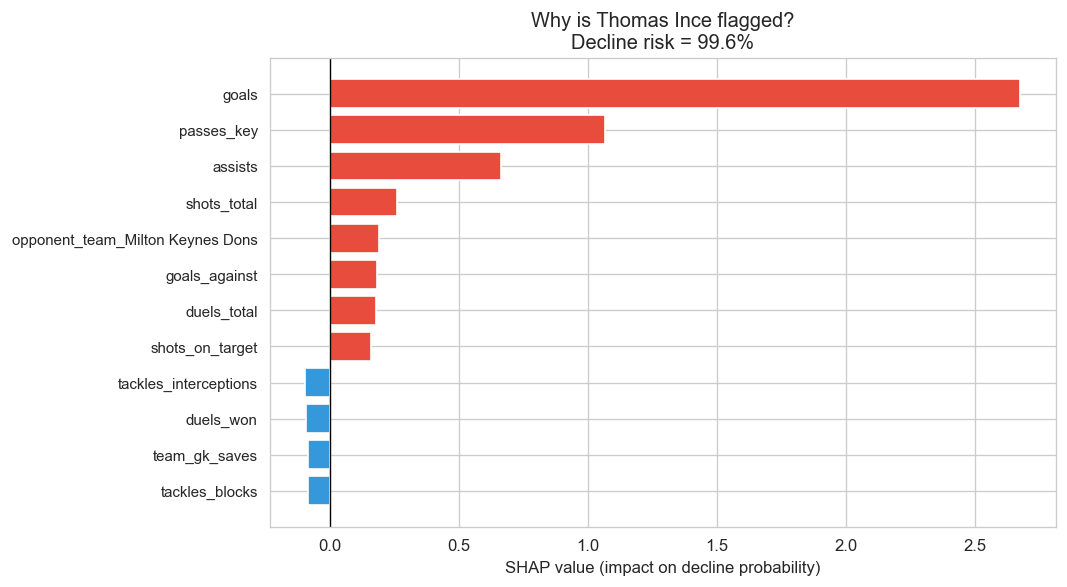

In [26]:
# ── Individual player explanation: highest-risk appearance in test set ─────────
# Position in the test matrix of the highest-risk row
highest_local_idx = int(np.argmax(y_proba))

# Recover the original df_a row (test_mask has df_a's index)
test_df_a_indices = df_a.index[test_mask].tolist()
df_row = df_a.iloc[df_a.index.get_loc(test_df_a_indices[highest_local_idx])]

print('=' * 65)
print('EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET')
print('=' * 65)
print(f'  Player:               {df_row["player_name"]}')
print(f'  Team:                 {df_row["player_team"]}')
print(f'  Date:                 {df_row["date"]}')
print(f'  Competition:          {df_row["competition"]}')
print(f'  Decline risk score:   {y_proba.max()*100:.1f}%')
print(f'  Risk tier:            {risk_tier(y_proba.max())}')
print(f'  Actual decline flag:  {int(df_row["api_rating_decline_flag"])}')
print()
print('  Key fatigue signals:')
for col in ['rest_days', 'acwr_ratio', 'min_last_7d', 'high_congestion_flag',
            'consecutive_away_games', 'returning_from_injury',
            'squad_injured_count', 'minutes_played', 'rating']:
    val = df_row.get(col, 'N/A')
    print(f'    {col:<30}: {val}')

# ── SHAP breakdown for this player ───────────────────────────────────────────
X_player = X_test_t[highest_local_idx].reshape(1, -1)
shap_player = explainer.shap_values(X_player)[0]

shap_df = pd.Series(shap_player, index=FEATURE_NAMES)
top_drivers = shap_df.abs().nlargest(12).index

print(f'\n  SHAP drivers (+ = increases decline risk, - = decreases risk):')
for feat in top_drivers:
    val   = shap_df[feat]
    sign  = '+' if val > 0 else '-'
    if feat in NUMERIC_COLS and feat in df_a.columns:
        orig  = df_row.get(feat, 'N/A')
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}  (value={orig})')
    else:
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}')

# ── Bar chart of top SHAP drivers ─────────────────────────────────────────────
top_n = 12
top_shap_sorted = shap_df.reindex(top_drivers)
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in top_shap_sorted.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(top_n), top_shap_sorted.values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_shap_sorted.index[::-1], fontsize=9)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on decline probability)')
ax.set_title(f'Why is {df_row["player_name"]} flagged?\nDecline risk = {y_proba.max()*100:.1f}%')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_individual.png', dpi=120, bbox_inches='tight')
plt.show()

# Model B — Fatigue-Adjusted Performance Decline Model

## Motivation: Why Redesign Model B?

The original Model B was an XGBoost regressor designed to predict `api_rating` using all available features, including current-match performance statistics, match context, workload indicators, and fatigue variables.

However, the model was dominated by direct current-performance variables such as:

```text
goals
assists
passes_key
shots_total
duels_won
```

This happened because API ratings are strongly influenced by those same event statistics. As a result, the model mainly learned patterns of **performance regression to the mean**, rather than isolating fatigue-related underperformance.

This creates an important modelling problem.

| Mechanism               | Main Cause                                                | Typical Predictors                                                        |
| ----------------------- | --------------------------------------------------------- | ------------------------------------------------------------------------- |
| Regression to the mean  | Exceptional performances are rare and difficult to repeat | goals, assists, key passes, shots, dribbles                               |
| Fatigue-induced decline | Physical or mental burden from accumulated workload       | rest days, recent minutes, fixture congestion, ACWR, competition sequence |

To study fatigue more directly, the model needs to separate these two effects.

The key idea of Model B is therefore:

```text
First estimate expected next-match performance.
Then model whether the player underperforms relative to that expectation.
```

---

## Two-Stage Architecture

Model B is designed as a two-stage system.

```text
Current-match performance + context
              │
              ▼
┌────────────────────────────────────┐
│ Stage 1 — Baseline Performance     │
│ XGBoost Regressor                  │
│ Target: next_api_rating            │
│ Excludes fatigue/workload features │
└────────────────────────────────────┘
              │
              ▼
 predicted_next_api_rating
              │
              ▼
┌────────────────────────────────────┐
│ Residual Calculation               │
│ residual = actual_next_api_rating  │
│            - predicted_next_rating │
└────────────────────────────────────┘
              │
              ▼
┌────────────────────────────────────┐
│ Stage 2 — Fatigue Residual Model   │
│ XGBoost Classifier                 │
│ Target: fatigue_decline_flag       │
│ Uses fatigue/workload features     │
└────────────────────────────────────┘
```

---

## Stage 1 — Baseline Expected Performance Model

The first stage estimates the player's expected next-match rating.

| Item              | Description                                                                                |
| ----------------- | ------------------------------------------------------------------------------------------ |
| Model             | XGBoost Regressor                                                                          |
| Target            | `next_api_rating`                                                                          |
| Features          | Current-match performance statistics, role, team, opponent, competition, and match context |
| Excluded features | Fatigue, workload, rest, congestion, and schedule-sequence variables                       |
| Purpose           | Estimate the rating the player would normally be expected to receive next match            |

The goal of Stage 1 is not to explain fatigue.

Instead, it estimates a baseline expected rating using non-fatigue information.

This creates a reference point:

```text
What rating would we expect this player to receive next match under normal conditions?
```

---

## Residual Definition

After Stage 1 predicts the expected next rating, a residual is computed:

```text
performance_residual = actual_next_api_rating - predicted_next_api_rating
```

The residual measures how much the player overperformed or underperformed relative to the baseline expectation.

| Residual Value     | Interpretation                             |
| ------------------ | ------------------------------------------ |
| Positive residual  | Player performed better than expected      |
| Near-zero residual | Player performed approximately as expected |
| Negative residual  | Player performed worse than expected       |

The fatigue-adjusted decline target is then defined as:

```text
fatigue_decline_flag = 1 if performance_residual <= -0.5
fatigue_decline_flag = 0 otherwise
```

This means the second-stage model focuses on cases where the player performed at least 0.5 rating points below the expected baseline.

---

## Stage 2 — Fatigue Residual Classifier

The second stage predicts whether the player will underperform relative to the baseline expectation.

| Item           | Description                                                                                |
| -------------- | ------------------------------------------------------------------------------------------ |
| Model          | XGBoost Classifier                                                                         |
| Target         | `fatigue_decline_flag`                                                                     |
| Positive class | Actual next rating is at least 0.5 points below expected next rating                       |
| Features       | Fatigue, workload, recovery, schedule, competition-sequence, and physical-burden variables |
| Purpose        | Identify whether workload and fatigue-related variables explain below-expected performance |

Stage 2 is the fatigue-focused component of Model B.

By modelling the residual rather than the raw rating, Stage 2 is less dominated by goals, assists, and standout performance events.

This makes its SHAP explanations more suitable for interpreting workload and fatigue mechanisms.

---

## Why Use a Two-Stage Model?

The two-stage design separates two different processes:

1. **Expected performance**
2. **Below-expected performance**

This is important because a rating decline can happen for different reasons.

A player may decline simply because they had an exceptional previous match that was difficult to repeat. This is regression to the mean.

Alternatively, a player may decline because they were under-recovered, overloaded, returning from injury, or affected by fixture congestion. This is closer to a fatigue-related mechanism.

Model B is designed to isolate the second mechanism.

---

## Engineered Features for Model B

Model B includes a richer set of fatigue, workload, schedule, and physical-burden features.

These features are designed to capture both short-term and medium-term load accumulation.

### Existing Workload and Recovery Features

| Feature                  | Interpretation                         |
| ------------------------ | -------------------------------------- |
| `rest_days`              | Days since the player's previous match |
| `min_last_7d`            | Minutes played in the previous 7 days  |
| `acwr_ratio`             | Acute-to-chronic workload ratio        |
| `high_congestion_flag`   | Indicator of fixture congestion        |
| `consecutive_away_games` | Number of consecutive away matches     |

---

## Additional Feature Groups

### Rolling Match Exposure

These features measure recent fixture density.

| Feature Group      | Description                                      |
| ------------------ | ------------------------------------------------ |
| `matches_last_7d`  | Number of matches played in the previous 7 days  |
| `matches_last_14d` | Number of matches played in the previous 14 days |
| `matches_last_21d` | Number of matches played in the previous 21 days |
| `matches_last_28d` | Number of matches played in the previous 28 days |

These features capture how frequently the player has been used over different time windows.

---

### Rolling Minutes

These features measure accumulated playing time.

| Feature Group  | Description                            |
| -------------- | -------------------------------------- |
| `min_last_14d` | Minutes played in the previous 14 days |
| `min_last_21d` | Minutes played in the previous 21 days |
| `min_last_28d` | Minutes played in the previous 28 days |

They extend the existing `min_last_7d` feature by capturing medium-term load accumulation.

---

### Rolling Starts

These features capture repeated starter-level exposure.

| Feature Group     | Description                    |
| ----------------- | ------------------------------ |
| `starts_last_7d`  | Starts in the previous 7 days  |
| `starts_last_14d` | Starts in the previous 14 days |
| `starts_last_28d` | Starts in the previous 28 days |

Repeated starts are important because starting a match usually implies greater tactical, physical, and mental load than a short substitute appearance.

---

### Full 90-Minute Burden

These features measure whether the player has repeatedly played complete matches.

| Feature Group       | Description                                    |
| ------------------- | ---------------------------------------------- |
| `full_90s_last_7d`  | Full 90-minute matches in the previous 7 days  |
| `full_90s_last_14d` | Full 90-minute matches in the previous 14 days |
| `full_90s_last_28d` | Full 90-minute matches in the previous 28 days |

These variables help distinguish players who are regularly rotated from players who are repeatedly required to complete full matches.

---

### Short-Rest Sequences

These features capture repeated low-recovery situations.

| Feature                            | Interpretation                                                |
| ---------------------------------- | ------------------------------------------------------------- |
| `short_rest_last_3_matches`        | Number of short-rest matches among the last three appearances |
| `avg_rest_last_3_matches`          | Average rest days across the last three appearances           |
| `min_rest_last_3_matches`          | Minimum rest days across the last three appearances           |
| `matches_with_rest_le_3d_last_30d` | Matches in the last 30 days with rest ≤ 3 days                |
| `matches_with_rest_le_4d_last_30d` | Matches in the last 30 days with rest ≤ 4 days                |
| `matches_with_rest_le_6d_last_30d` | Matches in the last 30 days with rest ≤ 6 days                |

These features are designed to capture not only one short-rest event, but repeated sequences of insufficient recovery.

---

### Competition-Sequence Features

Competition switches can create additional physical and tactical demands, especially when domestic and European matches occur close together.

| Feature                        | Interpretation                                                |
| ------------------------------ | ------------------------------------------------------------- |
| `pl_after_ucl`                 | Premier League match following a Champions League match       |
| `pl_after_cup`                 | Premier League match following a domestic cup match           |
| `ucl_after_pl`                 | Champions League match following a Premier League match       |
| `competition_switch`           | Whether the previous match was in a different competition     |
| `played_europe_last_match`     | Whether the player played a European match immediately before |
| `days_since_european_match`    | Days since the player's last European match                   |
| `matches_since_european_match` | Number of matches since the player's last European match      |

These features are important because fatigue may accumulate differently depending on travel, opponent quality, match intensity, and rotation patterns across competitions.

---

### Position-Adjusted Physical Burden

Raw physical metrics are not directly comparable across positions.

For example, a centre-back and a winger may naturally have very different duel, tackle, and dribble profiles.

To account for this, position-adjusted z-score features were created:

| Feature                      | Interpretation                                             |
| ---------------------------- | ---------------------------------------------------------- |
| `duels_total_position_z`     | Duel volume relative to the player's position group        |
| `tackles_total_position_z`   | Tackling volume relative to the player's position group    |
| `fouls_committed_position_z` | Fouling/aggression relative to the player's position group |
| `minutes_position_z`         | Match exposure relative to the player's position group     |

These features show whether a player's physical involvement was unusually high compared with players in the same role.

---

## Physical Load Index

A composite Physical Load Index was created to summarise match-level physical burden.

The index combines match exposure, duels, tackles, blocks, fouls, dribbles, and interceptions.

```text
Physical Load Index =
0.30 × minutes component
+ 0.20 × duel component
+ 0.15 × tackle component
+ 0.10 × block component
+ 0.10 × foul component
+ 0.10 × dribble component
+ 0.05 × interception component
```

The weights reflect the assumption that minutes played and duel involvement are the strongest indicators of physical exposure, followed by tackles, blocks, fouls, dribbles, and interceptions.

The index is not intended to be a medical fatigue score. It is a modelling feature that summarises observable match burden.

---

## Interpretation of Model B

Model B should be interpreted differently from Model A.

Model A predicts whether a player's next rating declines relative to their current rating. It is therefore strongly affected by current-match performance and regression-to-the-mean effects.

Model B instead asks:

```text
Did the player perform worse than expected, after accounting for baseline expected performance?
```

This makes Model B better suited for studying fatigue-related underperformance.

---

## Expected SHAP Interpretation

In Model B Stage 2, the expected strongest drivers should be fatigue and workload variables rather than direct performance events.

Expected important features include:

```text
rest_days
min_last_7d
min_last_14d
matches_last_14d
acwr_ratio
consecutive_away_games
full_90s_last_14d
short_rest_last_3_matches
pl_after_ucl
competition_switch
duels_total_position_z
physical_load_index
squad_injured_count
team_match_injury_context_score
```

If SHAP for Stage 2 is dominated by these variables, then the two-stage design is working as intended.

If SHAP is still dominated by goals, assists, shots, and key passes, then additional performance features should be removed from the residual classifier.

---

## Summary

Model B is a fatigue-adjusted two-stage model designed to separate normal performance variation from fatigue-related underperformance.

The two stages are:

| Stage   | Model              | Target                 | Purpose                                                                 |
| ------- | ------------------ | ---------------------- | ----------------------------------------------------------------------- |
| Stage 1 | XGBoost Regressor  | `next_api_rating`      | Estimate baseline expected next-match performance                       |
| Stage 2 | XGBoost Classifier | `fatigue_decline_flag` | Predict below-expected performance using fatigue and workload variables |

This design makes Model B more appropriate than the original single-stage regressor for studying whether workload, recovery, schedule congestion, physical burden, and injury context contribute to future underperformance.



In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Section 1: Feature Engineering
# Compute rolling workload, competition-switch, position z-scores, and PLI
# ═══════════════════════════════════════════════════════════════════════════════

import warnings
import numpy as np
import pandas as pd

# ── Work on a sorted copy; keep original DataFrame index for re-alignment ─────
df_fe = df.copy()
df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")

# Safe groupby key: avoids mixing unrelated players who share player_id = 0
df_fe["player_key"] = (
    df_fe["player_name"].astype(str).str.lower().str.strip()
    + "__"
    + df_fe["player_team"].astype(str).str.lower().str.strip()
)

df_fe.sort_values(["player_key", "date"], inplace=True)


# ── Helper: per-player rolling stats ─────────────────────────────────────────
def _add_rolling_features(grp):
    """
    Compute rolling/sequence fatigue features for one player group.
    All windows are EXCLUSIVE of the current match.
    """
    idx = grp.index

    dates = grp["date"].values.astype("datetime64[ns]")
    mins = grp["minutes_played"].fillna(0).values.astype(float)
    subs = grp["is_substitute"].fillna(False).values.astype(bool)
    rest = grp["rest_days"].values.astype(float)
    comps = grp["competition"].fillna("Unknown").astype(str).values

    n = len(dates)
    out = {}

    # A. Rolling window: matches, minutes, starts, full 90s
    for w in [7, 14, 21, 28]:
        delta = np.timedelta64(w, "D")

        cnt = np.zeros(n, dtype=float)
        min_s = np.zeros(n, dtype=float)
        starts = np.zeros(n, dtype=float)
        f90s = np.zeros(n, dtype=float)

        for i in range(n):
            mask = (dates < dates[i]) & (dates >= dates[i] - delta)

            cnt[i] = mask.sum()
            min_s[i] = mins[mask].sum()
            starts[i] = (~subs[mask]).sum()
            f90s[i] = (mins[mask] >= 85).sum()

        out[f"matches_last_{w}d"] = cnt

        if w > 7:
            out[f"min_last_{w}d"] = min_s

        out[f"starts_last_{w}d"] = starts
        out[f"full_90s_last_{w}d"] = f90s

    # B. Short-rest sequences: rest_days of last 3 prior matches
    lr = np.full((n, 3), np.nan)

    for i in range(n):
        if i >= 1:
            lr[i, 0] = rest[i - 1]
        if i >= 2:
            lr[i, 1] = rest[i - 2]
        if i >= 3:
            lr[i, 2] = rest[i - 3]

    out["short_rest_last_3_matches"] = np.nansum(lr <= 3, axis=1).astype(float)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        avg_lr = np.nanmean(lr, axis=1)
        min_lr = np.nanmin(lr, axis=1)

    all_missing_lr = np.all(np.isnan(lr), axis=1)

    out["avg_rest_last_3_matches"] = np.where(all_missing_lr, np.nan, avg_lr)
    out["min_rest_last_3_matches"] = np.where(all_missing_lr, np.nan, min_lr)

    # C. Number of previous matches in last 30d with short rest
    d30 = np.timedelta64(30, "D")

    le3 = np.zeros(n, dtype=float)
    le4 = np.zeros(n, dtype=float)
    le6 = np.zeros(n, dtype=float)

    for i in range(n):
        m30 = (dates < dates[i]) & (dates >= dates[i] - d30)
        r30 = rest[m30]
        r30 = r30[~np.isnan(r30)]

        le3[i] = (r30 <= 3).sum()
        le4[i] = (r30 <= 4).sum()
        le6[i] = (r30 <= 6).sum()

    out["matches_with_rest_le_3d_last_30d"] = le3
    out["matches_with_rest_le_4d_last_30d"] = le4
    out["matches_with_rest_le_6d_last_30d"] = le6

    # D. Competition-switch features
    eu_set = {"Champions League"}
    cup_set = {"FA Cup", "League Cup", "Community Shield"}

    prev = np.concatenate([[""], comps[:-1]])

    out["played_europe_last_match"] = np.isin(prev, list(eu_set)).astype(float)
    out["played_domestic_cup_last_match"] = np.isin(prev, list(cup_set)).astype(float)
    out["competition_switch"] = ((prev != comps) & (prev != "")).astype(float)

    out["pl_after_ucl"] = (
        (comps == "Premier League") & np.isin(prev, list(eu_set))
    ).astype(float)

    out["pl_after_cup"] = (
        (comps == "Premier League") & np.isin(prev, list(cup_set))
    ).astype(float)

    out["ucl_after_pl"] = (
        (comps == "Champions League") & (prev == "Premier League")
    ).astype(float)

    # E. Days/matches since previous European match
    eu_mask = np.isin(comps, list(eu_set))

    dse = np.full(n, np.nan)
    mse = np.full(n, np.nan)

    for i in range(n):
        past_eu = np.where(eu_mask[:i])[0]

        if len(past_eu) > 0:
            last_i = past_eu[-1]
            dse[i] = (dates[i] - dates[last_i]) / np.timedelta64(1, "D")
            mse[i] = float(i - last_i - 1)

    out["days_since_european_match"] = dse
    out["matches_since_european_match"] = mse

    return pd.DataFrame({k: pd.Series(v, index=idx) for k, v in out.items()})


# ── Apply to each player group ────────────────────────────────────────────────
print("Computing rolling features...")

fe_frames = []

for player_key, grp in df_fe.groupby("player_key", sort=False):
    fe_frames.append(_add_rolling_features(grp))

fe_df = pd.concat(fe_frames).sort_index()

for col in fe_df.columns:
    df_fe[col] = fe_df[col]

print(f"  Rolling / competition-switch features: {fe_df.shape[1]} columns")


# ═══════════════════════════════════════════════════════════════════════════════
# Position-specific z-scores
# ═══════════════════════════════════════════════════════════════════════════════

POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_COL_FOR_Z = next(
    (col for col in POSITION_CANDIDATES if col in df_fe.columns),
    None,
)

if POSITION_COL_FOR_Z is None:
    raise KeyError(
        "No position column found for position z-scores. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"Using position column for z-scores: {POSITION_COL_FOR_Z}")

zscore_base_cols = [
    "duels_total",
    "tackles_total",
    "fouls_committed",
    "minutes_played",
]

zscore_created = []

for col in zscore_base_cols:
    if col not in df_fe.columns:
        print(f"Skipping z-score for missing column: {col}")
        continue

    pos_mean = df_fe.groupby(POSITION_COL_FOR_Z)[col].transform("mean")
    pos_std = df_fe.groupby(POSITION_COL_FOR_Z)[col].transform("std")
    pos_std = pos_std.replace(0, 1.0)

    new_col = f"{col}_position_z"
    df_fe[new_col] = (df_fe[col] - pos_mean) / pos_std
    zscore_created.append(new_col)

print(f"  Position z-scores created: {len(zscore_created)} columns")


# ═══════════════════════════════════════════════════════════════════════════════
# Physical Load Index
# ═══════════════════════════════════════════════════════════════════════════════

def _minmax(s):
    s = pd.to_numeric(s, errors="coerce").fillna(0)
    lo, hi = s.min(), s.max()

    if hi > lo:
        return (s - lo) / (hi - lo)

    return pd.Series(0.5, index=s.index)


required_pli_cols = [
    "minutes_played",
    "duels_total",
    "tackles_total",
    "tackles_blocks",
    "fouls_committed",
    "dribbles_attempts",
    "tackles_interceptions",
]

missing_pli_cols = [c for c in required_pli_cols if c not in df_fe.columns]

if missing_pli_cols:
    raise KeyError(f"Missing required columns for Physical Load Index: {missing_pli_cols}")

df_fe["physical_load_index"] = (
    0.30 * _minmax(df_fe["minutes_played"])
    + 0.20 * _minmax(df_fe["duels_total"])
    + 0.15 * _minmax(df_fe["tackles_total"])
    + 0.10 * _minmax(df_fe["tackles_blocks"])
    + 0.10 * _minmax(df_fe["fouls_committed"])
    + 0.10 * _minmax(df_fe["dribbles_attempts"])
    + 0.05 * _minmax(df_fe["tackles_interceptions"])
)

print("  Physical Load Index created: 1 column")


# ── Restore original DataFrame order ─────────────────────────────────────────
df_fe.sort_index(inplace=True)


# ── Summary ─────────────────────────────────────────────────────────────────
NEW_FE_COLS = [col for col in df_fe.columns if col not in df.columns]

print(f"\nTotal new features: {len(NEW_FE_COLS)}")
print(f"df_fe shape: {df_fe.shape}")

nulls = df_fe[NEW_FE_COLS].isnull().sum()
non_null = nulls[nulls > 0].sort_values(ascending=False).head(20)

print("\nNull counts in new features:")
print(non_null.to_string() if len(non_null) > 0 else "  All zero.")

print("\nNew features created:")
for col in NEW_FE_COLS:
    print(f"  - {col}")


# ── Sample check ─────────────────────────────────────────────────────────────
sample_key = "stefan ortega__manchester city"

sample_cols = [
    "date",
    "competition",
    "minutes_played",
    "matches_last_7d",
    "matches_last_14d",
    "starts_last_7d",
    "full_90s_last_14d",
    "pl_after_ucl",
    "days_since_european_match",
    "physical_load_index",
]

sample_cols = [c for c in sample_cols if c in df_fe.columns]

print(f"\nSample check: {sample_key}")
sample_df = df_fe[df_fe["player_key"] == sample_key][sample_cols].head(8)

if len(sample_df) == 0:
    print("  No rows found for this sample player key.")
else:
    print(sample_df.to_string())

Computing rolling features...
  Rolling / competition-switch features: 29 columns
Using position column for z-scores: position_group
  Position z-scores created: 4 columns
  Physical Load Index created: 1 column

Total new features: 34
df_fe shape: (68722, 174)

Null counts in new features:
matches_since_european_match    52427
days_since_european_match       52427
min_rest_last_3_matches         11276
avg_rest_last_3_matches         11276

New features created:
  - player_key
  - matches_last_7d
  - starts_last_7d
  - full_90s_last_7d
  - matches_last_14d
  - min_last_14d
  - starts_last_14d
  - full_90s_last_14d
  - matches_last_21d
  - min_last_21d
  - starts_last_21d
  - full_90s_last_21d
  - matches_last_28d
  - starts_last_28d
  - full_90s_last_28d
  - short_rest_last_3_matches
  - avg_rest_last_3_matches
  - min_rest_last_3_matches
  - matches_with_rest_le_3d_last_30d
  - matches_with_rest_le_4d_last_30d
  - matches_with_rest_le_6d_last_30d
  - played_europe_last_match
  - playe

---

## Stage 1 — Baseline Expected Performance Model

**Goal**: Estimate the *contextual baseline* — "what rating would we expect for a player of this position/team, in this competition and fixture, regardless of their specific performance stats?"

Stage 1 uses **context-only features** (no performance stats, no fatigue, no current `rating`). This is intentionally a rough predictor. Its job is NOT to minimise RMSE but to remove structural contextual variation so the residual is a clean, meaningful signal.

**Why exclude performance stats from Stage 1?**  
If we include `goals`, `assists`, `duels_won`, etc. in Stage 1, it reconstructs the API rating formula near-perfectly (RMSE ≈ 0.007, residuals max ≈ ±0.13). The -0.5 threshold then finds zero fatigue declines. All performance variation must stay *in the residual* so Stage 2 can see the full range.

**Features used (context + identity only)**:
- Categorical: `competition`, `player_position`, `player_team`, `opponent_team`, `home_team`, `away_team`, `result`
- Numeric: `is_home`, `season`, `goals_for`, `goals_against`, `points`

**What the residual captures**:
```
performance_residual = next_api_rating − Stage1_predicted_next_rating

Residual > 0: player OVER-performed contextual expectation (scored, big game, etc.)
Residual < 0: player UNDER-performed contextual expectation
              └── Fatigue is one possible cause — Stage 2 tests if workload explains it
```


In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 1: Baseline Context-Only XGBoost Regressor
# Predict next_api_rating using CONTEXT ONLY
# No performance stats, no fatigue/workload features, no current rating
# ═══════════════════════════════════════════════════════════════════════════════

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# ── Choose safest available position column ───────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

STAGE1_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_fe.columns),
    None,
)

if STAGE1_POSITION_COL is None:
    raise KeyError(
        "No position column found for Stage 1. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"Using Stage 1 position column: {STAGE1_POSITION_COL}")


# ── Stage 1 feature sets: context only ────────────────────────────────────────
# No current-match performance stats, no fatigue features, no current rating.
# This prevents Stage 1 from reconstructing the API rating formula.
STAGE1_CAT = [
    "competition",
    STAGE1_POSITION_COL,
    "player_team",
    "opponent_team",
    "home_team",
    "away_team",
    "result",
]

STAGE1_NUM = [
    "is_home",
    "season",
    "goals_for",
    "goals_against",
    "points",
]


# ── Scorable subset from df_fe ────────────────────────────────────────────────
df_b = df_fe[
    (df_fe["rating"] > 0)
    & df_fe["next_api_rating"].notna()
    & (df_fe["minutes_played"] >= 45)
    & (df_fe["next_minutes_played"].fillna(0) >= 45)
].copy()

TARGET_S1 = "next_api_rating"

# Validate all Stage 1 columns exist
missing_s1 = [c for c in STAGE1_CAT + STAGE1_NUM if c not in df_b.columns]

if missing_s1:
    raise KeyError(f"Missing Stage 1 columns: {missing_s1}")

X_s1 = df_b[STAGE1_CAT + STAGE1_NUM].copy()
y_s1 = df_b[TARGET_S1].copy()

print(
    f"Stage 1 feature matrix: {X_s1.shape[1]} features "
    f"({len(STAGE1_CAT)} categorical, {len(STAGE1_NUM)} numeric)"
)
print(f"Stage 1 rows (scorable subset): {len(df_b):,}")


# ── Temporal split ────────────────────────────────────────────────────────────
s1_train_mask = df_b["season"] == 2022
s1_val_mask = df_b["season"] == 2023
s1_test_mask = df_b["season"] == 2024

X_s1_train, y_s1_train = X_s1[s1_train_mask], y_s1[s1_train_mask]
X_s1_val, y_s1_val = X_s1[s1_val_mask], y_s1[s1_val_mask]
X_s1_test, y_s1_test = X_s1[s1_test_mask], y_s1[s1_test_mask]

print(
    f"  Train: {s1_train_mask.sum():,}  |  "
    f"Val: {s1_val_mask.sum():,}  |  "
    f"Test: {s1_test_mask.sum():,}"
)


# ── Preprocessing pipeline ────────────────────────────────────────────────────
num_pipe_s1 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="median")),
    ]
)

cat_pipe_s1 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

pre_s1 = ColumnTransformer(
    transformers=[
        ("num", num_pipe_s1, STAGE1_NUM),
        ("cat", cat_pipe_s1, STAGE1_CAT),
    ],
    remainder="drop",
)


# ── Transform data ────────────────────────────────────────────────────────────
X_s1_train_t = pre_s1.fit_transform(X_s1_train)
X_s1_val_t = pre_s1.transform(X_s1_val)
X_s1_test_t = pre_s1.transform(X_s1_test)

cat_names_s1 = (
    pre_s1
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(STAGE1_CAT)
    .tolist()
)

FEATURE_NAMES_S1 = STAGE1_NUM + cat_names_s1

print("\nStage 1 preprocessed matrices:")
print(f"  Train: {X_s1_train_t.shape}")
print(f"  Val:   {X_s1_val_t.shape}")
print(f"  Test:  {X_s1_test_t.shape}")
print(f"  Features after OHE: {len(FEATURE_NAMES_S1)}")


# ── Stage 1 model ─────────────────────────────────────────────────────────────
stage1 = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

stage1.fit(
    X_s1_train_t,
    y_s1_train,
    eval_set=[(X_s1_val_t, y_s1_val)],
    verbose=200,
)


# ── Stage 1 test metrics ──────────────────────────────────────────────────────
pred_s1_test = stage1.predict(X_s1_test_t)

rmse_s1 = float(np.sqrt(mean_squared_error(y_s1_test, pred_s1_test)))
mae_s1 = float(mean_absolute_error(y_s1_test, pred_s1_test))

baseline_pred = np.full(len(y_s1_test), y_s1_train.mean())
baseline_s1 = float(np.sqrt(mean_squared_error(y_s1_test, baseline_pred)))

print("\nStage 1 — Test results, 2024 season:")
print(f"  Best iteration: {stage1.best_iteration}")
print(f"  RMSE:           {rmse_s1:.4f}  (mean-baseline: {baseline_s1:.4f})")
print(f"  MAE:            {mae_s1:.4f}")
print(
    "  Note: higher RMSE is expected because this is a context-only model. "
    "It is designed to leave player performance variation in the residual."
)


# ── Compute predicted rating for ALL scorable rows ────────────────────────────
X_s1_all_t = pre_s1.transform(X_s1)

df_b["predicted_next_rating_s1"] = stage1.predict(X_s1_all_t)
df_b["performance_residual"] = (
    df_b["next_api_rating"] - df_b["predicted_next_rating_s1"]
)

# ── Define Stage 2 residual target ────────────────────────────────────────────
df_b["fatigue_decline_flag"] = (
    df_b["performance_residual"] <= -0.5
).astype(int)

print(f"\nResidual statistics, all {len(df_b):,} scorable rows:")
print(df_b["performance_residual"].describe().round(4).to_string())

n_fatigue_declines = int(df_b["fatigue_decline_flag"].sum())
rate_fatigue_declines = df_b["fatigue_decline_flag"].mean() * 100

print(
    f"\nRows with residual <= -0.5:"
    f" {n_fatigue_declines:,} ({rate_fatigue_declines:.1f}%)"
)

print("\nStage 2 target created:")
print(df_b["fatigue_decline_flag"].value_counts(normalize=False).sort_index().to_string())
print(df_b["fatigue_decline_flag"].value_counts(normalize=True).sort_index().mul(100).round(2).to_string())

Using Stage 1 position column: position_group
Stage 1 feature matrix: 12 features (7 categorical, 5 numeric)
Stage 1 rows (scorable subset): 27,283
  Train: 9,340  |  Val: 9,183  |  Test: 8,760

Stage 1 preprocessed matrices:
  Train: (9340, 454)
  Val:   (9183, 454)
  Test:  (8760, 454)
  Features after OHE: 454
[0]	validation_0-rmse:0.63265
[200]	validation_0-rmse:0.61983
[297]	validation_0-rmse:0.62006

Stage 1 — Test results, 2024 season:
  Best iteration: 247
  RMSE:           0.6006  (mean-baseline: 0.6051)
  MAE:            0.4512
  Note: higher RMSE is expected because this is a context-only model. It is designed to leave player performance variation in the residual.

Residual statistics, all 27,283 scorable rows:
count    27283.0000
mean         0.0601
std          0.5877
min         -2.3185
25%         -0.3295
50%          0.0155
75%          0.3535
max          3.1741

Rows with residual <= -0.5: 4,489 (16.5%)

Stage 2 target created:
fatigue_decline_flag
0    22794
1     44

---

## Stage 2 — Fatigue Residual Classifier

**Goal**: Predict when a player's actual performance falls *below expectation* (as estimated by Stage 1) due to accumulated physical and schedule load.

**Target**:
```
performance_residual  = next_api_rating - predicted_next_api_rating_from_Stage1
fatigue_decline_flag  = 1  if  performance_residual ≤ -0.5
                      = 0  otherwise
```

A `fatigue_decline_flag = 1` means the player underperformed *relative to what Stage 1 expected* — the underperformance is the portion not explained by current form, quality of opposition, or competition context. Only fatigue and workload signals should explain this residual.

**Features used (fatigue & workload only)**:

| Group | Features |
|-------|---------|
| Schedule / recovery | `rest_days`, `high_congestion_flag`, `acwr_ratio`, `consecutive_away_games` |
| Rolling minutes | `min_last_7d`, `min_last_14d`, `min_last_21d`, `min_last_28d` |
| Rolling matches | `matches_last_7d`, `matches_last_14d`, `matches_last_21d`, `matches_last_28d` |
| Rolling starts | `starts_last_7d`, `starts_last_14d`, `starts_last_28d` |
| Full 90-min load | `full_90s_last_7d`, `full_90s_last_14d`, `full_90s_last_28d` |
| Short-rest sequences | `short_rest_last_3_matches`, `avg_rest_last_3_matches`, `min_rest_last_3_matches`, `matches_with_rest_le_3/4/6d_last_30d` |
| Competition-switch | `pl_after_ucl`, `pl_after_cup`, `ucl_after_pl`, `competition_switch`, `played_europe_last_match`, `played_domestic_cup_last_match`, `days_since_european_match`, `matches_since_european_match` |
| Squad & injury | `squad_injured_count`, `squad_soft_tissue_count`, `squad_avg_days_out`, `fixtures_missed_last_30d`, `fixtures_missed_last_90d`, `returning_from_injury` |
| Physical burden | `duels_total_position_z`, `tackles_total_position_z`, `fouls_committed_position_z`, `minutes_position_z`, `physical_load_index` |
| Position context | `player_position`, `competition` |

**Deliberately excluded**: `rating`, `goals`, `assists`, `shots_total`, `passes_key`, `duels_won`, `team_gk_saves`, and all other current-match performance stats that drive regression-to-mean.


In [34]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 2: Fatigue Residual Classifier
# Predict fatigue_decline_flag from fatigue/workload/injury features
# ═══════════════════════════════════════════════════════════════════════════════

from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
import numpy as np
import pandas as pd

# ── Define fatigue_decline_flag ───────────────────────────────────────────────
RESIDUAL_THRESHOLD = -0.5

df_b["fatigue_decline_flag"] = (
    df_b["performance_residual"] <= RESIDUAL_THRESHOLD
).astype(int)

n_s2_pos = int(df_b["fatigue_decline_flag"].sum())
n_s2_neg = int((df_b["fatigue_decline_flag"] == 0).sum())
spw_s2 = round(n_s2_neg / n_s2_pos, 2)

print("fatigue_decline_flag distribution:")
print(f"  Decline (1):    {n_s2_pos:,}  ({n_s2_pos / len(df_b) * 100:.2f}%)")
print(f"  No decline (0): {n_s2_neg:,}  ({n_s2_neg / len(df_b) * 100:.2f}%)")
print(f"  scale_pos_weight: {spw_s2}")


# ── Position column fallback ──────────────────────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

STAGE2_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_b.columns),
    None,
)

if STAGE2_POSITION_COL is None:
    raise KeyError(
        "No position column found for Stage 2. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"\nUsing Stage 2 position column: {STAGE2_POSITION_COL}")


# ── Stage 2 feature sets ──────────────────────────────────────────────────────
# Fatigue, workload, schedule, physical burden, and injury context.
# No direct current-match standout performance features like goals, assists,
# shots, key passes, or duels_won.
stage2_num_candidates = [
    # Existing fatigue/workload features
    "rest_days",
    "high_congestion_flag",
    "min_last_7d",
    "acwr_ratio",
    "consecutive_away_games",

    # External team injury context
    "squad_players_missing_total",
    "squad_injured_count",
    "squad_non_injury_missing_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "squad_max_days_out",
    "team_match_injury_context_score",

    # External team-season injury burden
    "team_season_total_absences",
    "team_season_injury_absences",
    "team_season_mean_injured_missing",
    "team_season_soft_tissue_absences",
    "team_season_mean_soft_tissue_missing",
    "team_season_unique_players_missing",
    "team_season_max_injured_in_match",
    "team_season_total_matches",

    # Player injury history, where available
    "player_season_matches_missed_total",
    "player_season_matches_missed_injury",
    "player_season_max_days_out",
    "player_season_injury_spells",
    "player_season_spell_matches_missed",
    "player_season_spell_max_days_out",
    "player_injury_history_score",
    "overall_injury_context_score",

    # Original injury-history features, if present
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",

    # Rolling match exposure
    "matches_last_7d",
    "matches_last_14d",
    "matches_last_21d",
    "matches_last_28d",

    # Rolling minutes
    "min_last_14d",
    "min_last_21d",
    "min_last_28d",

    # Rolling starts
    "starts_last_7d",
    "starts_last_14d",
    "starts_last_21d",
    "starts_last_28d",

    # Full 90s burden
    "full_90s_last_7d",
    "full_90s_last_14d",
    "full_90s_last_21d",
    "full_90s_last_28d",

    # Short-rest sequences
    "short_rest_last_3_matches",
    "avg_rest_last_3_matches",
    "min_rest_last_3_matches",
    "matches_with_rest_le_3d_last_30d",
    "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",

    # Competition-switch features
    "played_europe_last_match",
    "played_domestic_cup_last_match",
    "competition_switch",
    "pl_after_ucl",
    "pl_after_cup",
    "ucl_after_pl",
    "days_since_european_match",
    "matches_since_european_match",

    # Position-adjusted physical burden + Physical Load Index
    "duels_total_position_z",
    "tackles_total_position_z",
    "fouls_committed_position_z",
    "minutes_played_position_z",
    "physical_load_index",
]

STAGE2_NUM = [c for c in stage2_num_candidates if c in df_b.columns]

STAGE2_CAT = [
    c for c in [
        STAGE2_POSITION_COL,
        "competition",
        "player_main_absence_reason",
        "player_main_injury_category",
        "player_season_main_spell_category",
    ]
    if c in df_b.columns
]

missing_stage2_key_features = [
    c for c in [
        "min_last_14d",
        "matches_last_7d",
        "pl_after_ucl",
        "physical_load_index",
        "minutes_played_position_z",
    ]
    if c not in df_b.columns
]

print(
    f"\nStage 2 features: {len(STAGE2_NUM)} numeric + "
    f"{len(STAGE2_CAT)} categorical = {len(STAGE2_NUM) + len(STAGE2_CAT)} total"
)

print(f"Missing key Stage 2 engineered features: {missing_stage2_key_features}")


# ── Feature matrix and target ─────────────────────────────────────────────────
X_s2 = df_b[STAGE2_NUM + STAGE2_CAT].copy()
y_s2 = df_b["fatigue_decline_flag"].astype(int).copy()


# ── Temporal split ────────────────────────────────────────────────────────────
s2_train_mask = df_b["season"] == 2022
s2_val_mask = df_b["season"] == 2023
s2_test_mask = df_b["season"] == 2024

X_s2_train, y_s2_train = X_s2[s2_train_mask], y_s2[s2_train_mask]
X_s2_val, y_s2_val = X_s2[s2_val_mask], y_s2[s2_val_mask]
X_s2_test, y_s2_test = X_s2[s2_test_mask], y_s2[s2_test_mask]

print(
    f"\nSplit sizes — "
    f"Train: {s2_train_mask.sum():,}  "
    f"Val: {s2_val_mask.sum():,}  "
    f"Test: {s2_test_mask.sum():,}"
)

print("\nStage 2 target rate by split:")
for split_name, yy in [
    ("Train", y_s2_train),
    ("Val", y_s2_val),
    ("Test", y_s2_test),
]:
    print(
        f"  {split_name:<5} rows={len(yy):,}  "
        f"pos={int(yy.sum()):,}  "
        f"rate={yy.mean() * 100:.2f}%"
    )


# ── Preprocessing ─────────────────────────────────────────────────────────────
num_pipe_s2 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="median")),
    ]
)

cat_pipe_s2 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

pre_s2 = ColumnTransformer(
    transformers=[
        ("num", num_pipe_s2, STAGE2_NUM),
        ("cat", cat_pipe_s2, STAGE2_CAT),
    ],
    remainder="drop",
)

X_s2_train_t = pre_s2.fit_transform(X_s2_train)
X_s2_val_t = pre_s2.transform(X_s2_val)
X_s2_test_t = pre_s2.transform(X_s2_test)

cat_feature_names_s2 = (
    pre_s2
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(STAGE2_CAT)
    .tolist()
)

FEATURE_NAMES_S2 = STAGE2_NUM + cat_feature_names_s2

print("\nStage 2 preprocessed matrices:")
print(f"  Train: {X_s2_train_t.shape}")
print(f"  Val:   {X_s2_val_t.shape}")
print(f"  Test:  {X_s2_test_t.shape}")
print(f"  Features after OHE: {len(FEATURE_NAMES_S2)}")


# ── Stage 2 classifier ────────────────────────────────────────────────────────
stage2 = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw_s2,
    objective="binary:logistic",
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

stage2.fit(
    X_s2_train_t,
    y_s2_train,
    eval_set=[(X_s2_val_t, y_s2_val)],
    verbose=100,
)


# ── Evaluation ────────────────────────────────────────────────────────────────
y_s2_proba = stage2.predict_proba(X_s2_test_t)[:, 1]

s2_auc_roc = roc_auc_score(y_s2_test, y_s2_proba)
s2_auc_pr = average_precision_score(y_s2_test, y_s2_proba)

# PR-AUC random baseline should use the test-set positive rate
baseline_s2 = float(y_s2_test.mean())

# Optimal threshold by F1
prec_c, rec_c, thr_c = precision_recall_curve(y_s2_test, y_s2_proba)

# Last precision/recall point has no corresponding threshold, so exclude it
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-10)
best_idx_s2 = int(np.argmax(f1_c))
best_thr_s2 = float(thr_c[best_idx_s2])

y_s2_pred = (y_s2_proba >= best_thr_s2).astype(int)

print("\nStage 2 — Test results, 2024 season:")
print(f"  Best iteration:     {stage2.best_iteration}")
print(f"  AUC-ROC:            {s2_auc_roc:.3f}")
print(
    f"  AUC-PR:             {s2_auc_pr:.3f} "
    f"(baseline: {baseline_s2:.3f}, lift: {s2_auc_pr / baseline_s2:.2f}x)"
)
print(f"  Optimal threshold:  {best_thr_s2:.2f}")
print(
    f"  F1: {f1_score(y_s2_test, y_s2_pred):.3f}  |  "
    f"Precision: {precision_score(y_s2_test, y_s2_pred):.3f}  |  "
    f"Recall: {recall_score(y_s2_test, y_s2_pred):.3f}"
)

print("\nClassification report at optimal threshold:")
print(
    classification_report(
        y_s2_test,
        y_s2_pred,
        target_names=["No Fatigue Decline", "Fatigue Decline"],
        zero_division=0,
    )
)


# ── Threshold sweep ───────────────────────────────────────────────────────────
print("\nThreshold sensitivity:")
print(f"  {'Threshold':>9}  {'Precision':>9}  {'Recall':>9}  {'F1':>6}  {'Alerts':>7}")

for threshold in [0.20, 0.30, 0.40, best_thr_s2, 0.50, 0.60, 0.70]:
    y_pred_t = (y_s2_proba >= threshold).astype(int)

    p = precision_score(y_s2_test, y_pred_t, zero_division=0)
    r = recall_score(y_s2_test, y_pred_t, zero_division=0)
    f = f1_score(y_s2_test, y_pred_t, zero_division=0)

    print(
        f"  {threshold:>9.2f}  "
        f"{p:>9.3f}  "
        f"{r:>9.3f}  "
        f"{f:>6.3f}  "
        f"{int(y_pred_t.sum()):>7,}"
    )


# ── Save Stage 2 prediction output for later SHAP/dashboard analysis ──────────
df_s2_test_out = df_b.loc[s2_test_mask, [
    "player_name",
    "player_team",
    "competition",
    "date",
    "minutes_played",
    "rest_days",
    "acwr_ratio",
    "min_last_7d",
    "matches_last_14d",
    "physical_load_index",
    "performance_residual",
    "fatigue_decline_flag",
]].copy()

df_s2_test_out["fatigue_decline_proba"] = y_s2_proba
df_s2_test_out["fatigue_decline_pred"] = y_s2_pred

print("\nTop 15 highest predicted fatigue-residual risk:")
top15_s2 = df_s2_test_out.nlargest(15, "fatigue_decline_proba")
print(top15_s2.to_string(index=False))

fatigue_decline_flag distribution:
  Decline (1):    4,489  (16.45%)
  No decline (0): 22,794  (83.55%)
  scale_pos_weight: 5.08

Using Stage 2 position column: position_group

Stage 2 features: 62 numeric + 5 categorical = 67 total
Missing key Stage 2 engineered features: []

Split sizes — Train: 9,340  Val: 9,183  Test: 8,760

Stage 2 target rate by split:
  Train rows=9,340  pos=1,708  rate=18.29%
  Val   rows=9,183  pos=1,401  rate=15.26%
  Test  rows=8,760  pos=1,380  rate=15.75%

Stage 2 preprocessed matrices:
  Train: (9340, 90)
  Val:   (9183, 90)
  Test:  (8760, 90)
  Features after OHE: 90
[0]	validation_0-aucpr:0.15135
[78]	validation_0-aucpr:0.15801

Stage 2 — Test results, 2024 season:
  Best iteration:     28
  AUC-ROC:            0.505
  AUC-PR:             0.164 (baseline: 0.158, lift: 1.04x)
  Optimal threshold:  0.45
  F1: 0.273  |  Precision: 0.158  |  Recall: 0.996

Classification report at optimal threshold:
                    precision    recall  f1-score   suppo

Number of transformed Stage 2 features: 90
X_s2_test_t shape: (8760, 90)

Stage 2 — SHAP Global Feature Importance
Mean absolute SHAP values, test-set sample
Rank  Feature                                              Mean |SHAP|
────────────────────────────────────────────────────────────────────────
   1.  squad_avg_days_out                                       0.03501
   2.  position_group_Goalkeeper                                0.02728
   3.  physical_load_index                                      0.01297
   4.  consecutive_away_games                                   0.00948
   5.  matches_with_rest_le_6d_last_30d                         0.00947
   6.  avg_rest_last_3_matches                                  0.00923
   7.  minutes_played_position_z                                0.00801
   8.  matches_since_european_match                             0.00796
   9.  days_since_european_match                                0.00788
  10.  squad_non_injury_missing_count             

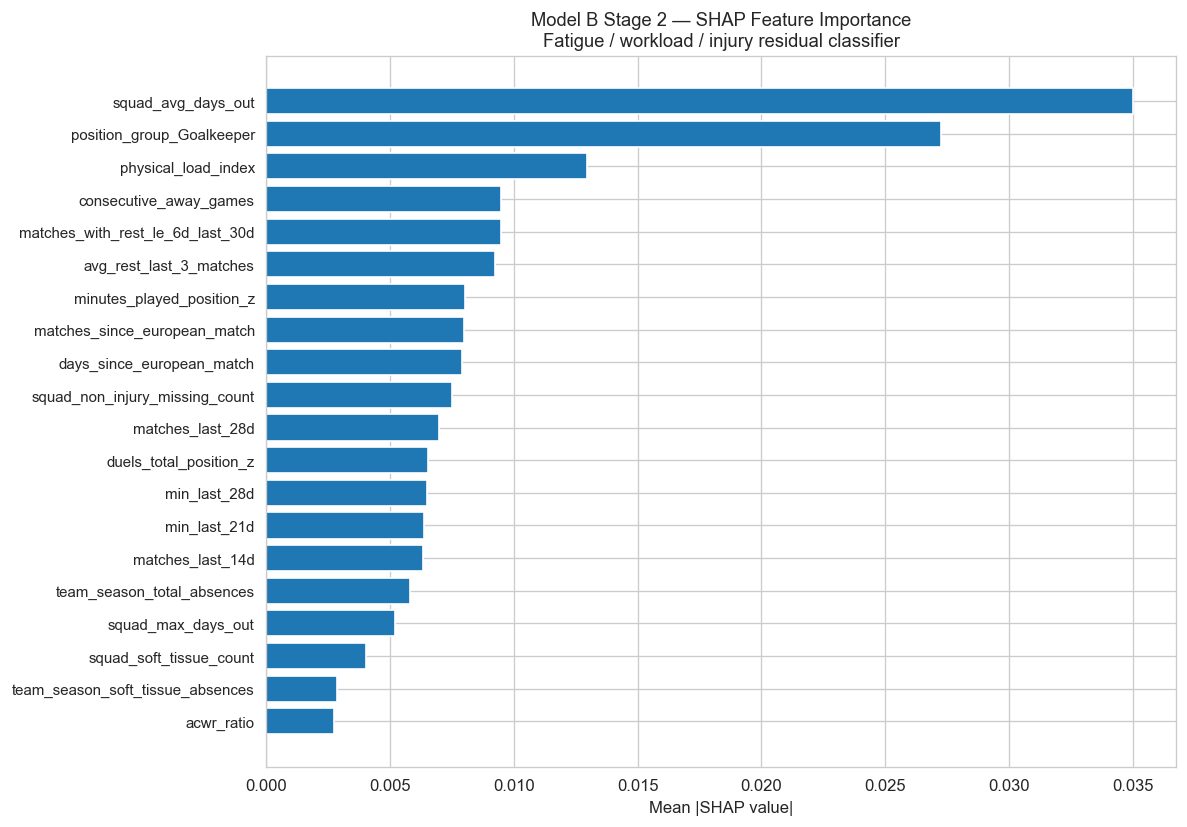


SHAP importance by feature group
Sum of mean absolute SHAP values:
──────────────────────────────────────────────────────────────────────
  Squad injury context                     0.0531  ██████████████████████████████
  Position context                         0.0305  █████████████████
  Short-rest sequences                     0.0246  █████████████
  Competition sequence                     0.0224  ████████████
  Position-adjusted physical burden        0.0191  ██████████
  Rolling minutes                          0.0158  ████████
  Rolling matches                          0.0144  ████████
  Schedule/recovery                        0.0141  ███████
  Physical Load Index                      0.0130  ███████
  Team-season injury burden                0.0124  ███████
  Player injury history                    0.0036  ██
  Rolling starts                           0.0035  █
  Full 90s burden                          0.0007  
  Competition context                      0.0000  
  Player in

In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 2: SHAP Feature Importance
# Explain the fatigue residual classifier
# ═══════════════════════════════════════════════════════════════════════════════

import shap
import builtins
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── SHAP / XGBoost 3.x compatibility patch ───────────────────────────────────
_orig_float = builtins.float

def _patched_float(x):
    if isinstance(x, str):
        x = x.strip().lstrip("[").rstrip("]")
    return _orig_float(x)

builtins.float = _patched_float
try:
    explainer_s2 = shap.TreeExplainer(stage2.get_booster())
finally:
    builtins.float = _orig_float


# ── Feature names after preprocessing ────────────────────────────────────────
cat_names_s2 = list(
    pre_s2
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(STAGE2_CAT)
)

FEATURE_NAMES_S2 = STAGE2_NUM + cat_names_s2

print(f"Number of transformed Stage 2 features: {len(FEATURE_NAMES_S2)}")
print(f"X_s2_test_t shape: {X_s2_test_t.shape}")

if len(FEATURE_NAMES_S2) != X_s2_test_t.shape[1]:
    raise ValueError(
        f"Feature name mismatch: {len(FEATURE_NAMES_S2)} names, "
        f"but matrix has {X_s2_test_t.shape[1]} columns."
    )


# ── Compute SHAP on test set sample ───────────────────────────────────────────
shap_n_s2 = min(3000, X_s2_test_t.shape[0])

shap_idx_s2 = np.random.default_rng(42).choice(
    X_s2_test_t.shape[0],
    size=shap_n_s2,
    replace=False
)

X_s2_shap = X_s2_test_t[shap_idx_s2]

shap_vals_s2 = explainer_s2.shap_values(X_s2_shap)

# Some SHAP versions return a list for binary classifiers
if isinstance(shap_vals_s2, list):
    shap_vals_s2 = shap_vals_s2[1]

mean_abs_s2 = pd.Series(
    np.abs(shap_vals_s2).mean(axis=0),
    index=FEATURE_NAMES_S2
).sort_values(ascending=False)

top20_s2 = mean_abs_s2.head(20)

print("\nStage 2 — SHAP Global Feature Importance")
print("Mean absolute SHAP values, test-set sample")
print(f'{"Rank":>4}  {"Feature":<50}  {"Mean |SHAP|":>12}')
print("─" * 72)

for rank, (feat, val) in enumerate(top20_s2.items(), 1):
    print(f"{rank:>4}.  {feat:<50}  {val:>12.5f}")


# ── Save top SHAP feature table ───────────────────────────────────────────────
top20_s2_df = (
    top20_s2
    .rename("mean_abs_shap")
    .reset_index()
    .rename(columns={"index": "feature"})
)

top20_s2_df.to_csv(
    ARTIFACTS_DIR / "model_b_stage2_shap_top20.csv",
    index=False
)


# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    range(len(top20_s2)),
    top20_s2.values[::-1]
)

ax.set_yticks(range(len(top20_s2)))
ax.set_yticklabels(top20_s2.index[::-1], fontsize=9)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(
    "Model B Stage 2 — SHAP Feature Importance\n"
    "Fatigue / workload / injury residual classifier",
    fontsize=11
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "shap_stage2_fatigue.png",
    dpi=120,
    bbox_inches="tight"
)
plt.show()


# ── SHAP importance by feature group ─────────────────────────────────────────
GROUP_PREFIXES = {
    # Schedule / recovery
    "rest_days": "Schedule/recovery",
    "high_congestion_flag": "Schedule/recovery",
    "acwr_ratio": "Schedule/recovery",
    "consecutive_away_games": "Schedule/recovery",

    # Rolling minutes
    "min_last_7d": "Rolling minutes",
    "min_last_14d": "Rolling minutes",
    "min_last_21d": "Rolling minutes",
    "min_last_28d": "Rolling minutes",

    # Rolling matches
    "matches_last_7d": "Rolling matches",
    "matches_last_14d": "Rolling matches",
    "matches_last_21d": "Rolling matches",
    "matches_last_28d": "Rolling matches",

    # Rolling starts
    "starts_last_7d": "Rolling starts",
    "starts_last_14d": "Rolling starts",
    "starts_last_21d": "Rolling starts",
    "starts_last_28d": "Rolling starts",

    # Full 90s
    "full_90s_last_7d": "Full 90s burden",
    "full_90s_last_14d": "Full 90s burden",
    "full_90s_last_21d": "Full 90s burden",
    "full_90s_last_28d": "Full 90s burden",

    # Short-rest sequences
    "short_rest_last_3_matches": "Short-rest sequences",
    "avg_rest_last_3_matches": "Short-rest sequences",
    "min_rest_last_3_matches": "Short-rest sequences",
    "matches_with_rest_le_3d_last_30d": "Short-rest sequences",
    "matches_with_rest_le_4d_last_30d": "Short-rest sequences",
    "matches_with_rest_le_6d_last_30d": "Short-rest sequences",

    # Competition sequence
    "pl_after_ucl": "Competition sequence",
    "pl_after_cup": "Competition sequence",
    "ucl_after_pl": "Competition sequence",
    "competition_switch": "Competition sequence",
    "played_europe_last_match": "Competition sequence",
    "played_domestic_cup_last_match": "Competition sequence",
    "days_since_european_match": "Competition sequence",
    "matches_since_european_match": "Competition sequence",

    # Physical burden
    "duels_total_position_z": "Position-adjusted physical burden",
    "tackles_total_position_z": "Position-adjusted physical burden",
    "fouls_committed_position_z": "Position-adjusted physical burden",
    "minutes_played_position_z": "Position-adjusted physical burden",
    "physical_load_index": "Physical Load Index",

    # Squad / injury context
    "squad_players_missing_total": "Squad injury context",
    "squad_injured_count": "Squad injury context",
    "squad_non_injury_missing_count": "Squad injury context",
    "squad_soft_tissue_count": "Squad injury context",
    "squad_avg_days_out": "Squad injury context",
    "squad_max_days_out": "Squad injury context",
    "team_match_injury_context_score": "Squad injury context",

    # Team-season injury burden
    "team_season_total_absences": "Team-season injury burden",
    "team_season_injury_absences": "Team-season injury burden",
    "team_season_mean_injured_missing": "Team-season injury burden",
    "team_season_soft_tissue_absences": "Team-season injury burden",
    "team_season_mean_soft_tissue_missing": "Team-season injury burden",
    "team_season_unique_players_missing": "Team-season injury burden",
    "team_season_max_injured_in_match": "Team-season injury burden",
    "team_season_total_matches": "Team-season injury burden",

    # Player injury history
    "player_season_matches_missed_total": "Player injury history",
    "player_season_matches_missed_injury": "Player injury history",
    "player_season_max_days_out": "Player injury history",
    "player_season_injury_spells": "Player injury history",
    "player_season_spell_matches_missed": "Player injury history",
    "player_season_spell_max_days_out": "Player injury history",
    "player_injury_history_score": "Player injury history",
    "overall_injury_context_score": "Player injury history",

    # Original player injury fields, if present
    "fixtures_missed_last_30d": "Player injury history",
    "fixtures_missed_last_90d": "Player injury history",
    "returning_from_injury": "Player injury history",
}


def assign_stage2_group(feature_name):
    """
    Assign transformed feature names to interpretable groups.
    Works for both raw numeric features and one-hot encoded categorical features.
    """
    for prefix, group in GROUP_PREFIXES.items():
        if feature_name.startswith(prefix):
            return group

    if feature_name.startswith("position_group"):
        return "Position context"

    if feature_name.startswith("competition"):
        return "Competition context"

    if feature_name.startswith("player_main_absence_reason"):
        return "Player injury category"

    if feature_name.startswith("player_main_injury_category"):
        return "Player injury category"

    if feature_name.startswith("player_season_main_spell_category"):
        return "Player injury category"

    return "Other"


group_totals = {}

for feat, shap_val in mean_abs_s2.items():
    group = assign_stage2_group(feat)
    group_totals[group] = group_totals.get(group, 0.0) + shap_val

group_series = pd.Series(group_totals).sort_values(ascending=False)

print("\nSHAP importance by feature group")
print("Sum of mean absolute SHAP values:")
print("─" * 70)

for group, val in group_series.items():
    bar_len = int(val / group_series.max() * 30) if group_series.max() > 0 else 0
    bar = "█" * bar_len
    print(f"  {group:<38} {val:>8.4f}  {bar}")


# ── Save group-level SHAP table ───────────────────────────────────────────────
group_series.rename("sum_mean_abs_shap").reset_index().rename(
    columns={"index": "feature_group"}
).to_csv(
    ARTIFACTS_DIR / "model_b_stage2_shap_groups.csv",
    index=False
)

## Model B — Results & Discussion

### Summary Metrics

| Metric                       | Model A — Full Decline Model                             | Model B Stage 1 — Context Baseline | Model B Stage 2 — Fatigue Residual Classifier                     |
| ---------------------------- | -------------------------------------------------------- | ---------------------------------- | ----------------------------------------------------------------- |
| Target                       | `api_rating_decline_flag`                                | `next_api_rating`                  | `fatigue_decline_flag`                                            |
| Target definition            | Next rating drops by more than 0.5 points                | Predict next API rating            | Residual ≤ −0.5 after Stage 1                                     |
| Model type                   | XGBoost Classifier                                       | XGBoost Regressor                  | XGBoost Classifier                                                |
| Feature set                  | Full feature set: performance, workload, context, injury | Context-only features              | Fatigue, workload, schedule, physical-burden, and injury features |
| Raw features                 | 107                                                      | 12                                 | 67                                                                |
| Features after preprocessing | 613                                                      | 454                                | 90                                                                |
| Positive rate                | 24.75%                                                   | —                                  | 16.45% overall                                                    |
| Test AUC-ROC                 | 0.7913                                                   | —                                  | 0.505                                                             |
| Test AUC-PR / RMSE           | AUC-PR = 0.5976                                          | RMSE = 0.6006                      | AUC-PR = 0.164                                                    |
| Baseline                     | PR-AUC baseline = 0.2500                                 | Mean-baseline RMSE = 0.6051        | PR-AUC baseline = 0.158                                           |
| Lift over baseline           | 2.4×                                                     | Slightly better than mean baseline | 1.04×                                                             |
| Best threshold               | 0.47                                                     | —                                  | 0.45                                                              |
| Main interpretation          | Strong operational decline-risk model                    | Broad context expectation model    | Weak fatigue-residual signal                                      |

---

## What Does Stage 2 AUC-ROC = 0.505 Mean?

Stage 2 is essentially near-random.

The classifier was designed to answer the question:

> After removing broad contextual expectations, can fatigue, workload, schedule, physical burden, and injury-context features predict whether a player performs substantially below expectation?

The answer from the current results is:

```text
Almost no, at the individual match level.
```

The Stage 2 AUC-ROC was **0.505**, which is only marginally above random ranking. The PR-AUC was **0.164**, compared with a test-set baseline of **0.158**, giving only a **1.04× lift** over random.

This does not mean the two-stage experiment failed. It is a useful negative result. It shows that, with the available data, fatigue-related features alone do not meaningfully explain below-expected next-match rating residuals.

---

## Why Fatigue Features Have Limited Individual-Match Predictive Power

### 1. Single-match ratings are highly event-driven

API ratings are strongly affected by discrete match events such as goals, assists, saves, key passes, duels won, mistakes, and goals conceded.

These events are high variance. A player can have heavy workload and still receive a strong rating because they scored, assisted, or made a decisive action.

This makes individual-match rating residuals noisy.

### 2. Fatigue may operate more clearly at population level

Fatigue and congestion effects may exist, but they may be easier to detect across groups, teams, or longer periods than in a single player’s next match.

Predicting whether one specific player will underperform in one specific next match using only schedule and workload proxies is difficult.

### 3. The residual target contains multiple sources of noise

The Stage 1 context-only model achieved:

```text
RMSE = 0.6006
Mean-baseline RMSE = 0.6051
```

This means Stage 1 only slightly improves over the mean baseline, by design.

The residual therefore contains a mixture of:

```text
individual form variation
match-event randomness
tactical effects
rating-system noise
fatigue effects
injury effects
unobserved player-specific factors
```

Fatigue may explain part of this residual, but not enough to create a strong classifier with the current feature set.

### 4. Available fatigue features are coarse proxies

The model uses observable football-data proxies such as:

```text
rest_days
min_last_7d
acwr_ratio
matches_last_14d
consecutive_away_games
physical_load_index
```

These are useful, but they are not the same as true physiological fatigue data.

A more complete fatigue model would ideally include GPS load, high-speed running, accelerations, decelerations, training load, sleep quality, recovery scores, heart-rate variability, and medical markers.

---

## Stage 2 SHAP Results

Although Stage 2 had weak predictive performance, the SHAP ranking is still useful as a diagnostic.

It shows that Stage 2 is no longer dominated by direct current-match performance events such as:

```text
goals
assists
passes_key
shots_total
dribbles_success
```

Instead, the highest-ranked features are injury, workload, schedule, and position-context variables.

### Top 20 Stage 2 SHAP Features

| Rank | Feature                            | Mean |SHAP| | Interpretation                          |
| ---: | ---------------------------------- | ----------: | --------------------------------------- |
|    1 | `squad_avg_days_out`               |     0.03501 | Squad injury severity                   |
|    2 | `position_group_Goalkeeper`        |     0.02728 | Goalkeeper-specific rating behaviour    |
|    3 | `physical_load_index`              |     0.01297 | Match-level physical burden             |
|    4 | `consecutive_away_games`           |     0.00948 | Travel and away-fixture accumulation    |
|    5 | `matches_with_rest_le_6d_last_30d` |     0.00947 | Short-rest accumulation                 |
|    6 | `avg_rest_last_3_matches`          |     0.00923 | Recent recovery pattern                 |
|    7 | `minutes_played_position_z`        |     0.00801 | Minutes relative to position norm       |
|    8 | `matches_since_european_match`     |     0.00796 | European fixture sequence               |
|    9 | `days_since_european_match`        |     0.00788 | European fixture recency                |
|   10 | `squad_non_injury_missing_count`   |     0.00750 | Squad availability context              |
|   11 | `matches_last_28d`                 |     0.00697 | 28-day fixture density                  |
|   12 | `duels_total_position_z`           |     0.00652 | Position-adjusted physical contest load |
|   13 | `min_last_28d`                     |     0.00649 | Medium-term accumulated minutes         |
|   14 | `min_last_21d`                     |     0.00636 | Medium-term accumulated minutes         |
|   15 | `matches_last_14d`                 |     0.00633 | Short-term fixture density              |
|   16 | `team_season_total_absences`       |     0.00579 | Team-season injury burden               |
|   17 | `squad_max_days_out`               |     0.00520 | Squad injury severity                   |
|   18 | `squad_soft_tissue_count`          |     0.00402 | Soft-tissue injury pressure             |
|   19 | `team_season_soft_tissue_absences` |     0.00286 | Team-season soft-tissue burden          |
|   20 | `acwr_ratio`                       |     0.00271 | Acute-to-chronic workload               |

---

## What the SHAP Ranking Reveals

### 1. The two-stage design successfully removed direct performance dominance

Unlike Model A, Stage 2 is not dominated by goals, assists, key passes, or shots.

This confirms that the two-stage design achieved its methodological objective: it separated direct performance-regression effects from fatigue and workload indicators.

### 2. Squad injury context is the strongest Stage 2 signal

The highest-ranked feature was:

```text
squad_avg_days_out
```

Other injury-context features also appeared in the top 20:

```text
squad_non_injury_missing_count
team_season_total_absences
squad_max_days_out
squad_soft_tissue_count
team_season_soft_tissue_absences
```

This suggests that Stage 2 is sensitive to squad availability and injury pressure. However, because the classifier itself is weak, this should be interpreted as exploratory rather than conclusive.

### 3. Goalkeeper effects are a warning signal

The second most important feature was:

```text
position_group_Goalkeeper
```

This suggests that Stage 2 may be partly driven by goalkeeper-specific rating behaviour rather than a general fatigue mechanism.

This is consistent with the highest-risk predictions, which were dominated by goalkeepers such as André Onana, David Raya, Nick Pope, Alisson, and Adam Davies.

Goalkeeper ratings are structurally different from outfield ratings because they depend heavily on saves, clean sheets, goals conceded, single errors, and defensive pressure.

For this reason, Model B Stage 2 should be re-tested either excluding goalkeepers or modelling goalkeepers separately.

### 4. Longer workload windows appear more useful than immediate 7-day load

Medium-term workload features appeared in the top 20:

```text
matches_last_28d
min_last_28d
min_last_21d
matches_last_14d
```

By contrast, `min_last_7d` did not appear among the strongest Stage 2 SHAP features.

This suggests that, if fatigue is detectable in this dataset, it may be better represented by medium-term accumulated exposure rather than only the previous week.

### 5. Competition-sequence features remain relevant

Both European-sequence features appeared in the top 10:

```text
matches_since_european_match
days_since_european_match
```

These features may capture the extra burden associated with multi-competition involvement, especially for teams alternating between domestic and European fixtures.

However, again, this should be treated cautiously because the overall classifier performance is close to random.

---

## Practical Implication for the Dashboard

The Model B results reinforce the dashboard design philosophy.

The dashboard should not show only one global risk score as if it captures all mechanisms.

Instead, it should separate different types of signal:

| Dashboard Layer                   | Source                       | Interpretation                                              |
| --------------------------------- | ---------------------------- | ----------------------------------------------------------- |
| Overall decline risk              | Model A                      | Probability that next rating will decline                   |
| Regression-to-mean signal         | Model A SHAP                 | Whether risk is driven by standout current performance      |
| Fatigue pressure indicators       | Engineered workload features | Recent minutes, rest, congestion, travel, European sequence |
| Squad stress indicators           | Injury database features     | Squad injury burden and availability pressure               |
| Exploratory fatigue residual risk | Model B Stage 2              | Experimental indicator, not deployment-ready                |

A player can have:

```text
high regression risk but low fatigue pressure
```

or:

```text
low regression risk but high workload/injury pressure
```

These are different cases and should be displayed separately.

---

## Comparison: Model A vs Model B Stage 2

| Item                  | Model A                                        | Model B Stage 2                                      |
| --------------------- | ---------------------------------------------- | ---------------------------------------------------- |
| Target                | Rating decline relative to current match       | Rating decline relative to context-based expectation |
| Test AUC-ROC          | 0.7913                                         | 0.505                                                |
| Test AUC-PR           | 0.5976                                         | 0.164                                                |
| Baseline PR-AUC       | 0.2500                                         | 0.158                                                |
| Dominant SHAP feature | `goals`                                        | `squad_avg_days_out`                                 |
| Main signal           | Regression to mean + match-performance context | Weak fatigue/workload/injury residual signal         |
| Operational value     | Strong monitoring model                        | Exploratory diagnostic only                          |
| Dashboard role        | Overall decline-risk score                     | Fatigue-pressure layer, not final prediction engine  |

The performance gap between Model A and Model B Stage 2 shows that most of the predictive power in Model A comes from direct performance and contextual signals rather than isolated fatigue-residual effects.

However, this gap should not be interpreted as an exact percentage decomposition of predictive signal. It is better interpreted as evidence that fatigue-only residual prediction is much harder than overall decline prediction.

---

## Final Interpretation

Model B provides a useful methodological test.

It shows that when direct performance-regression signals are removed, the remaining fatigue, workload, schedule, physical-burden, and injury variables do not currently predict below-expected rating decline with enough strength for operational use.

The key conclusion is:

```text
Model A is the stronger operational model for dashboard risk ranking.
Model B is an exploratory fatigue-mechanism model.
```

Therefore, the best dashboard strategy is to use Model A as the main decline-risk score, while showing Model B-style workload, schedule, and injury indicators as separate explanatory layers rather than as a standalone prediction system.


---

# Model B v2 — Redesign Specification

> **Purpose**: This section documents the full redesign of the two-stage fatigue model based on the lessons learnt from Model B v1. All changes are motivated by the v1 findings (Stage 2 AUC-ROC = 0.505) and by the goal of building a dashboard that is both **forward-looking** and **honest** about what it predicts.

---

## Summary of changes vs. Model B v1

| # | Area | v1 | v2 |
|---|------|----|----|
| 1 | Stage 1 features | 12 context/identity only | Context + player + team + opponent baselines |
| 2 | Stage 1 result/goals leakage | Included `result`, `goals_for` | Excluded — replaced with rolling form |
| 3 | Stage 2 target threshold | Fixed `residual ≤ −0.5` | Position-adjusted bottom-25th percentile |
| 4 | Goalkeeper handling | Mixed into all models | Excluded from fatigue model (separate if needed) |
| 5 | Stage 2 architecture | Single classifier (all positions) | Per-position-group classifiers (GK, DEF, MID, FWD) |
| 6 | Dashboard output | Probability score | Transparent **Fatigue Pressure Index** (0–100) |
| 7 | Row structure | current-match features → next-match target | Pre-next-match state → upcoming-match target |

---

## Change 1 — Stage 1: Add player, team, and opponent baselines

### Why v1 Stage 1 was too weak

v1 Stage 1 used only 12 context/identity features (competition, position, team, opponent, home/away, season).  
RMSE = 0.600 vs. baseline 0.605 — the model barely beat a naïve mean because it had no information about the player's normal performance level.

The residuals therefore contained **too much unexplained variance**, making Stage 2 impossible to calibrate.

### Stage 1 v2 feature set

```
Context features (unchanged from v1)
  competition
  player_position
  player_team
  opponent_team
  is_home
  season

Player baseline features  (rolling, always computed from PREVIOUS matches only)
  rating_mean_last_3       — short-term form
  rating_mean_last_5       — medium-term form
  rating_mean_last_10      — career-season baseline
  rating_median_last_5     — robust central tendency (less sensitive to outliers)
  rating_std_last_5        — player rating volatility
  rating_trend_last_5      — direction of form: slope of last 5 ratings

Team baseline features
  team_points_mean_last_5
  team_goals_for_mean_last_5
  team_goals_against_mean_last_5
  team_possession_mean_last_5
  team_rating_mean_last_5          — average team performance quality

Opponent strength proxies
  opponent_points_mean_last_5
  opponent_goals_against_mean_last_5    — how much the opponent concedes (offensive opportunity)
  opponent_goals_for_mean_last_5        — how dangerous the opponent is (defensive pressure)
```

### What to EXCLUDE from Stage 1

| Feature | Reason to exclude |
|---------|------------------|
| `current_rating` | This IS the target from the previous row — reintroduces regression-to-mean |
| `current_goals` | Single-match event — high variance, not predictive of next match level |
| `current_assists` | Same as above |
| `current_key_passes` | Same as above |
| `result` | Match outcome (W/D/L) — known only AFTER the match, not before the next one |
| `goals_for` / `goals_against` | Same — current match outcome, not a pre-match known |
| `points` | Derived from result — same problem |

> **Rule**: Stage 1 should know the player's **normal level**, not the exceptional events of the last match. Rolling averages (`rating_mean_last_5`) carry the player's form signal without the noise of single-match extremes.


---

## Change 2 — Fix temporal alignment for dashboard deployment

### The core problem

In v1 (and current notebook), each row is structured as:

```
Row i = [current_match_stats] → target: next_match_rating
```

This means features are derived from match `t` and the target is match `t+1`. This is valid for training, but creates a conceptual mismatch for a **pre-match dashboard**.

### Target row structure for v2

Each row should represent the **upcoming match** from the perspective of the player before it is played:

```
Row i = player + upcoming_fixture (match t+1)
```

| Feature category | Concrete examples | Available before match t+1? |
|-----------------|------------------|-----------------------------|
| Upcoming fixture identity | `upcoming_competition`, `next_opponent`, `next_is_home` |  Yes — from fixture list |
| Schedule state | `days_since_last_match`, `rest_days_before_next_match` |  Yes |
| Workload window | `minutes_last_7d`, `starts_last_14d`, `matches_last_28d` |  Yes — computed up to match t |
| Last-match physical toll | `physical_load_last_match`, `duels_total_last_match` |  Yes — from match t |
| Competition-switch | `played_ucl_3d_ago`, `days_since_european_match` |  Yes |
| Player baseline | `rating_mean_last_5`, `rating_std_last_5` |  Yes — from matches t-4..t |
| Squad context | `squad_avg_days_out`, `squad_injured_count` |  Yes — from team injury list |
| **Target** | `actual_rating` (match t+1) |  Only known after match — used for training only |

> **This is the most important design shift**: the dataset rows must be restructured so that the features describe the player's state **before** the upcoming match, and the target is the rating they actually achieved in that match (used only during training, never at inference time).

In the current notebook, this requires a simple re-indexing: instead of computing `next_api_rating = df.groupby(player_id)['api_rating'].shift(-1)`, we should ensure **all feature columns are shifted one step forward** relative to the target, so the feature values always pre-date the target event.

---

## Change 3 — Stage 2 target: position-adjusted threshold

### Why fixed `−0.5` is inappropriate

A fixed residual threshold treats all positions the same. Goalkeeper ratings are more volatile than midfielders; a 0.5-point drop means something different across positions.

### v2 approach: position-group bottom-25th percentile

```python
# Compute the 25th-percentile residual for each position group
position_q25 = (
    df_b.groupby("player_position")["performance_residual"]
    .quantile(0.25)
)

# Assign position-adjusted threshold per row
df_b["residual_threshold"] = df_b["player_position"].map(position_q25)

# Flag: bottom quartile of residuals for that position
df_b["fatigue_decline_flag_v2"] = (
    df_b["performance_residual"] <= df_b["residual_threshold"]
).astype(int)
```

**Properties of this approach:**
- Always produces exactly 25% positives per position group (balanced by design)
- Threshold is relative to the player's position, not to a universal scale
- More stable target for Stage 2 training
- Aligns with the dashboard question: "Is this player in the bottom quartile of their positional peers given their fatigue state?"

**Alternative thresholds to explore:**

| Threshold | Meaning | Positives |
|-----------|---------|-----------|
| `≤ −0.5` (v1) | Fixed absolute drop | 16.5% |
| `≤ position-Q25` | Bottom 25% per position | ~25% |
| `≤ player-Q25` | Bottom 25% per individual player | ~25% |
| `≤ −0.3` | Smaller fixed drop | ~25–30% |

---

## Change 4 — Exclude goalkeepers from the fatigue model

### Why goalkeepers are different

Goalkeepers have fundamentally different fatigue and rating profiles:

- **Different physical load**: GKs run far less than outfield players; their fatigue is dominated by concentration/mental load, not cardiovascular
- **Rating driver mismatch**: GK ratings are driven by saves, clean sheets, and errors — not duels, sprints, or passing. The Physical Load Index (based on minutes + duels + tackles) is less valid for GKs
- **Rotation logic**: GKs are almost never rotated in short schedules; a GK playing 90 minutes every match is normal, not a fatigue signal
- **SHAP evidence from v1**: `player_position_G` was the **2nd most important SHAP feature** in Stage 2 — meaning the model was using goalkeeper identity as a proxy rather than learning genuine fatigue signals

### Implementation

```python
# Exclude goalkeepers for the fatigue model
df_b_outfield = df_b[df_b["player_position"] != "G"].copy()

# Optionally build a separate GK model if there is enough data
df_b_gk = df_b[df_b["player_position"] == "G"].copy()
```

---

## Change 5 — Per-position-group Stage 2 classifiers

### Motivation

Fatigue does not manifest identically across positions:

| Position | Primary fatigue signal | Rating driver |
|----------|----------------------|---------------|
| **GK** | Clean sheet pressure, concentration errors | Saves, errors, CS |
| **DEF** | Duels, headers, defensive actions | Tackles, blocks, clearances |
| **MID** | Distance covered, pressing intensity | Passes, key passes, pressing |
| **FWD** | Sprint counts, off-ball movement | Goals, shots, key passes |

A single classifier conflates these different fatigue mechanisms. Training per-position-group models allows each model to learn position-specific load-performance relationships.

### Architecture

```
Stage2_DEF  ─── trained on defenders (position = "D")
Stage2_MID  ─── trained on midfielders (position = "M")
Stage2_FWD  ─── trained on forwards (position = "F")
(Stage2_GK)  ─── optional, separate, lower priority
```

**Feature sets may differ per group:**
- DEF: emphasise `tackles_total_position_z`, `headers_position_z`, `physical_load_index`
- MID: emphasise `min_last_21d`, `matches_last_28d`, `consecutive_away_games`
- FWD: emphasise `sprint_count_proxy`, `short_rest_last_3_matches`, `pl_after_ucl`

---

## Change 6 — Stage 2 as a Fatigue Pressure Index (dashboard)

### Why a probability is not the right output

Stage 2 v1 AUC-ROC = 0.524 means the classifier probability is barely better than random. Publishing a number like "72% chance of fatigue-induced underperformance" would be misleading — the model cannot support that claim.

However, the **SHAP feature ranking is still valid**: it tells us which fatigue dimensions carry the most discriminatory signal. This is sufficient to build an honest, interpretable dashboard score.

### Fatigue Pressure Index (FPI) formula

```
FPI = 0.30 × rolling_minutes_score
    + 0.20 × short_rest_sequence_score
    + 0.15 × full_90s_burden_score
    + 0.15 × competition_switch_score
    + 0.10 × physical_load_index_score
    + 0.10 × squad_injury_pressure_score
```

Where each component is normalised to [0, 1] using the training-set distribution (e.g. min-max scaling or percentile rank).

**Weight rationale (based on SHAP group totals from v1):**

| Component | SHAP group total (v1) | FPI weight |
|-----------|----------------------|------------|
| Rolling minutes (`min_last_21d`, `min_last_28d`) | 0.057 | 30% |
| Short-rest sequence | 0.027 | 20% |
| Full 90s burden | n/a | 15% |
| Competition-switch (`days_since_european_match`) | 0.058 | 15% |
| Physical Load Index | 0.038 | 10% |
| Squad/injury (`squad_avg_days_out`) | 0.078 | 10% |

### Dashboard display (example)

```
Player: Phil Foden  |  Upcoming: Man City vs Arsenal (PL)
─────────────────────────────────────────────────────────
  Expected Rating (Stage 1):     7.4 / 10
  Fatigue Pressure Index:        78 / 100  ██████████░░

  Main drivers:
    ● 3 matches in the last 8 days         (rolling minutes: HIGH)
    ● 244 minutes in last 14 days          (short rest: HIGH)
    ● PL match 3 days after Champions Lg   (competition-switch: HIGH)
    ● Physical Load Index above position avg  (PLI: ELEVATED)
    ● 4 squad players injured ≥ 7 days     (squad burden: MODERATE)

  Regression risk (Model A):     HIGH  (goals=2 last match)
─────────────────────────────────────────────────────────
```

This is more **honest and more actionable** than a weak probability. The FPI communicates:
1. *How much physical pressure* is the player under?
2. *Which specific factors* are driving the pressure?
3. *How does this compare* to their normal level?

### Validation

The FPI should be validated by checking: **do high-FPI players have lower average residuals?**

```python
# Bin players by FPI quartile and check mean residual
df_b["fpi_quartile"] = pd.qcut(df_b["fatigue_pressure_index"], q=4, labels=["Q1","Q2","Q3","Q4"])
df_b.groupby("fpi_quartile")["performance_residual"].mean()
# Expected: Q4 (highest fatigue) should show most negative mean residual
```

If high-FPI players have lower average residuals, the index is a valid indicator even without a reliable classifier.

---




In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Feature Engineering: Player / Team / Opponent Baselines
# Fixes: (1) rating=0 excluded via rating_clean  (2) groupby uses player_key
# ═══════════════════════════════════════════════════════════════════════════════

# ── Safe re-run: drop v2 columns if they already exist ───────────────────────
_V2_BASELINE_COLS = [
    'rating_clean',
    'rating_mean_last_3', 'rating_mean_last_5', 'rating_mean_last_10',
    'rating_median_last_5', 'rating_std_last_5', 'rating_trend_last_5',
    'team_points_mean_last_5', 'team_goals_for_mean_last_5',
    'team_goals_against_mean_last_5', 'team_possession_mean_last_5',
    'team_rating_mean_last_5',
    'opponent_points_mean_last_5', 'opponent_goals_against_mean_last_5',
    'opponent_goals_for_mean_last_5',
]
_existing_v2 = [c for c in _V2_BASELINE_COLS if c in df_fe.columns]
if _existing_v2:
    df_fe.drop(columns=_existing_v2, inplace=True)

# ── rating_clean: treat rating == 0 as unrated (NaN), not a bad performance ──
# rating=0 means the player was not individually rated (e.g., GK in a draw,
# bench appearance, or data gap). Including 0 as a real value would
# artificially drag down a player's rolling mean (e.g., 7.2 → 4.8).
df_fe['rating_clean'] = df_fe['rating'].replace(0, np.nan)

# ── Ensure temporal order for rolling ────────────────────────────────────────
# Use player_key (not player_id) to avoid mixing unmatched players (id=0)
df_fe.sort_values(['player_key', 'date'], inplace=True)

# ─────────────────────────────────────────────────────────────────────────────
# A. Player rating baselines
#    Uses rating_clean so unrated appearances do not pull the average down
#    Groups by player_key to keep each player's history separate
# ─────────────────────────────────────────────────────────────────────────────
print('A. Player rating baselines (using rating_clean + player_key)...')

def _trend_slope(arr):
    """OLS slope over a small window (raw numpy array). Returns NaN if < 2 valid points."""
    valid = arr[~np.isnan(arr)]
    if len(valid) < 2:
        return np.nan
    return float(np.polyfit(np.arange(len(valid)), valid, 1)[0])

_g_r = df_fe.groupby('player_key')['rating_clean']

df_fe['rating_mean_last_3']   = _g_r.transform(lambda x: x.shift(1).rolling(3,  min_periods=1).mean())
df_fe['rating_mean_last_5']   = _g_r.transform(lambda x: x.shift(1).rolling(5,  min_periods=1).mean())
df_fe['rating_mean_last_10']  = _g_r.transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
df_fe['rating_median_last_5'] = _g_r.transform(lambda x: x.shift(1).rolling(5,  min_periods=1).median())
df_fe['rating_std_last_5']    = _g_r.transform(lambda x: x.shift(1).rolling(5,  min_periods=2).std())
df_fe['rating_trend_last_5']  = _g_r.transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).apply(_trend_slope, raw=True))

print(f'  OK — 6 player baseline columns')

# ─────────────────────────────────────────────────────────────────────────────
# B. Team-level rolling baselines  (per fixture_id + player_team)
# ─────────────────────────────────────────────────────────────────────────────
print('B. Team baselines...')

# Average player rating per team per fixture — use rating_clean to exclude unrated
_team_avg_r = (
    df_fe.groupby(['fixture_id', 'player_team'])['rating_clean']
    .mean()
    .reset_index()
    .rename(columns={'rating_clean': '_team_avg_r'})
)

# Deduplicated team-match frame — one row per team per fixture
_team_match = (
    df_fe[['fixture_id', 'player_team', 'date',
           'goals_for', 'goals_against', 'points', 'team_possession']]
    .drop_duplicates(subset=['fixture_id', 'player_team'])
    .merge(_team_avg_r, on=['fixture_id', 'player_team'], how='left')
    .sort_values(['player_team', 'date'])
    .reset_index(drop=True)
    .copy()
)

TEAM_BASELINE_COLS = [
    'team_points_mean_last_5', 'team_goals_for_mean_last_5',
    'team_goals_against_mean_last_5', 'team_possession_mean_last_5',
    'team_rating_mean_last_5',
]
_gtm = _team_match.groupby('player_team')
for _src, _dst in zip(
    ['points', 'goals_for', 'goals_against', 'team_possession', '_team_avg_r'],
    TEAM_BASELINE_COLS,
):
    _team_match[_dst] = _gtm[_src].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())

df_fe = df_fe.merge(
    _team_match[['fixture_id', 'player_team'] + TEAM_BASELINE_COLS],
    on=['fixture_id', 'player_team'],
    how='left',
)
print(f'  OK — {len(TEAM_BASELINE_COLS)} team baseline columns')

# ─────────────────────────────────────────────────────────────────────────────
# C. Opponent strength proxies  (re-use _team_match, rename as opponent)
# ─────────────────────────────────────────────────────────────────────────────
print('C. Opponent baselines...')

_opp_match = (
    _team_match[['fixture_id', 'player_team', 'date', 'points', 'goals_for', 'goals_against']]
    .rename(columns={
        'player_team':   'opponent_team',
        'points':        '_opp_pts',
        'goals_for':     '_opp_gf',
        'goals_against': '_opp_ga',
    })
    .sort_values(['opponent_team', 'date'])
    .reset_index(drop=True)
    .copy()
)

OPP_BASELINE_COLS = [
    'opponent_points_mean_last_5',
    'opponent_goals_against_mean_last_5',
    'opponent_goals_for_mean_last_5',
]
_gom = _opp_match.groupby('opponent_team')
for _src, _dst in zip(['_opp_pts', '_opp_ga', '_opp_gf'], OPP_BASELINE_COLS):
    _opp_match[_dst] = _gom[_src].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())

df_fe = df_fe.merge(
    _opp_match[['fixture_id', 'opponent_team'] + OPP_BASELINE_COLS],
    on=['fixture_id', 'opponent_team'],
    how='left',
)
print(f'  OK — {len(OPP_BASELINE_COLS)} opponent baseline columns')

# ── Restore original index order ─────────────────────────────────────────────
df_fe.sort_index(inplace=True)

# ── Summary ───────────────────────────────────────────────────────────────────
NEW_V2_BASELINE_COLS = (
    ['rating_mean_last_3', 'rating_mean_last_5', 'rating_mean_last_10',
     'rating_median_last_5', 'rating_std_last_5', 'rating_trend_last_5']
    + TEAM_BASELINE_COLS + OPP_BASELINE_COLS
)
print(f'\nTotal new v2 baseline features: {len(NEW_V2_BASELINE_COLS)}')
print(f'df_fe shape: {df_fe.shape}')
_null_v2 = df_fe[NEW_V2_BASELINE_COLS].isnull().sum()
print('\nNull counts per new feature:')
print(_null_v2.to_string())

# ── Verify fix: Manuel Akanji should no longer show 0.0 corrupting his mean ──
print('\nVerification — Manuel Akanji (rating=0 should be excluded from baselines):')
_ak = df_fe[df_fe['player_name'].str.contains('Akanji', case=False, na=False)]
if len(_ak) > 0:
    print(_ak[['date', 'rating', 'rating_clean', 'rating_mean_last_3',
               'rating_mean_last_5', 'rating_std_last_5']].head(10).to_string())
else:
    print('  (player not found in dataset)')


A. Player rating baselines (using rating_clean + player_key)...
  OK — 6 player baseline columns
B. Team baselines...
  OK — 5 team baseline columns
C. Opponent baselines...
  OK — 3 opponent baseline columns

Total new v2 baseline features: 14
df_fe shape: (68722, 189)

Null counts per new feature:
rating_mean_last_3                    14587
rating_mean_last_5                    12574
rating_mean_last_10                   11099
rating_median_last_5                  12574
rating_std_last_5                     20352
rating_trend_last_5                   20352
team_points_mean_last_5                3046
team_goals_for_mean_last_5             3046
team_goals_against_mean_last_5         3046
team_possession_mean_last_5            8065
team_rating_mean_last_5                3046
opponent_points_mean_last_5            3062
opponent_goals_against_mean_last_5     3062
opponent_goals_for_mean_last_5         3062

Verification — Manuel Akanji (rating=0 should be excluded from baselines):
       

Using Stage 1 v2 position column: position_group
Stage 1 v2 feature matrix: 20 features (4 categorical + 16 numeric)
Scorable rows: 27,283
  Train: 9,340  |  Val: 9,183  |  Test: 8,760

Preprocessed Stage 1 v2 matrices:
  Train: (9340, 260)
  Val:   (9183, 260)
  Test:  (8760, 260)
  Features after OHE: 260
[0]	validation_0-rmse:0.63195
[186]	validation_0-rmse:0.60533

Stage 1 v2 — 2024 test set:
  Best iteration:   136
  RMSE:             0.5880
  Mean baseline:    0.6051
  v1 RMSE:          0.6006
  RMSE improvement vs v1: 2.1%
  MAE:              0.4429
  v1 MAE:           0.4512
  MAE improvement vs v1:  1.8%

Residual statistics, all 27,283 rows:
count    27283.0000
mean         0.0395
std          0.5789
min         -2.2569
25%         -0.3351
50%          0.0162
75%          0.3452
max          3.1188

Residual std — v1 context-only: 0.5877
Residual std — v2 + baselines:  0.5789
Lower residual std means Stage 1 explains more next-rating variance.

Top 20 Stage 1 v2 feature impor

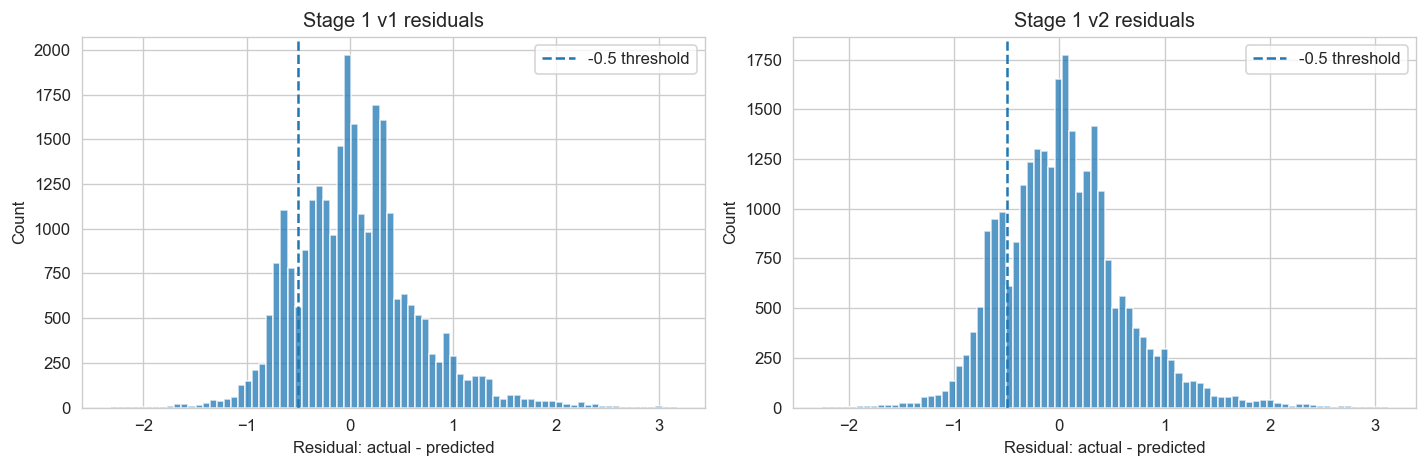

Figure saved → ../../models/Xg_Boost/artifacts/figures/stage1_v2_residuals.png


In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Stage 1: XGBRegressor with player / team / opponent baselines
# Target: next_api_rating
# Excluded: result, goals_for, goals_against, points
# Excluded: current rating and direct current-match event stats
# ═══════════════════════════════════════════════════════════════════════════════

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Previous Model B v1 Stage 1 metrics, for comparison ──────────────────────
S1_V1_RMSE = 0.6006
S1_V1_MAE = 0.4512

# ── Choose safest available position column ──────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

S1V2_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_fe.columns),
    None,
)

if S1V2_POSITION_COL is None:
    raise KeyError(
        "No position column found for Stage 1 v2. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"Using Stage 1 v2 position column: {S1V2_POSITION_COL}")

# ── Feature sets ─────────────────────────────────────────────────────────────
S1V2_CAT = [
    "competition",
    S1V2_POSITION_COL,
    "player_team",
    "opponent_team",
]

S1V2_NUM = [
    # Context available from the current row
    "is_home",
    "season",

    # Player form baselines, previous matches only
    "rating_mean_last_3",
    "rating_mean_last_5",
    "rating_mean_last_10",
    "rating_median_last_5",
    "rating_std_last_5",
    "rating_trend_last_5",

    # Team form baselines
    "team_points_mean_last_5",
    "team_goals_for_mean_last_5",
    "team_goals_against_mean_last_5",
    "team_possession_mean_last_5",
    "team_rating_mean_last_5",

    # Opponent strength proxies
    "opponent_points_mean_last_5",
    "opponent_goals_against_mean_last_5",
    "opponent_goals_for_mean_last_5",
]

# ── Scorable subset ──────────────────────────────────────────────────────────
df_bv2 = df_fe[
    (df_fe["rating"] > 0)
    & df_fe["next_api_rating"].notna()
    & (df_fe["minutes_played"] >= 45)
    & (df_fe["next_minutes_played"].fillna(0) >= 45)
].copy()

TARGET_S1V2 = "next_api_rating"

missing_s1v2 = [c for c in S1V2_CAT + S1V2_NUM if c not in df_bv2.columns]

if missing_s1v2:
    raise ValueError(f"Missing Stage 1 v2 columns: {missing_s1v2}")

X_s1v2 = df_bv2[S1V2_CAT + S1V2_NUM].copy()
y_s1v2 = df_bv2[TARGET_S1V2].copy()

print(
    f"Stage 1 v2 feature matrix: {X_s1v2.shape[1]} features "
    f"({len(S1V2_CAT)} categorical + {len(S1V2_NUM)} numeric)"
)
print(f"Scorable rows: {len(df_bv2):,}")

# ── Temporal split ───────────────────────────────────────────────────────────
trn = df_bv2["season"] == 2022
val = df_bv2["season"] == 2023
tst = df_bv2["season"] == 2024

print(
    f"  Train: {trn.sum():,}  |  "
    f"Val: {val.sum():,}  |  "
    f"Test: {tst.sum():,}"
)

# ── Preprocessing ────────────────────────────────────────────────────────────
pre_s1v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imp", SimpleImputer(strategy="median")),
                ]
            ),
            S1V2_NUM,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            S1V2_CAT,
        ),
    ],
    remainder="drop",
)

X_s1v2_trn_t = pre_s1v2.fit_transform(X_s1v2[trn])
X_s1v2_val_t = pre_s1v2.transform(X_s1v2[val])
X_s1v2_tst_t = pre_s1v2.transform(X_s1v2[tst])

cat_out_s1v2 = (
    pre_s1v2
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(S1V2_CAT)
    .tolist()
)

FEATURE_NAMES_S1V2 = S1V2_NUM + cat_out_s1v2

print("\nPreprocessed Stage 1 v2 matrices:")
print(f"  Train: {X_s1v2_trn_t.shape}")
print(f"  Val:   {X_s1v2_val_t.shape}")
print(f"  Test:  {X_s1v2_tst_t.shape}")
print(f"  Features after OHE: {len(FEATURE_NAMES_S1V2)}")

# ── Model ────────────────────────────────────────────────────────────────────
stage1_v2 = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

stage1_v2.fit(
    X_s1v2_trn_t,
    y_s1v2[trn],
    eval_set=[(X_s1v2_val_t, y_s1v2[val])],
    verbose=200,
)

# ── Test metrics ─────────────────────────────────────────────────────────────
pred_v2_tst = stage1_v2.predict(X_s1v2_tst_t)

rmse_s1v2 = float(np.sqrt(mean_squared_error(y_s1v2[tst], pred_v2_tst)))
mae_s1v2 = float(mean_absolute_error(y_s1v2[tst], pred_v2_tst))

baseline_s1v2 = float(
    np.sqrt(
        mean_squared_error(
            y_s1v2[tst],
            np.full(len(y_s1v2[tst]), y_s1v2[trn].mean()),
        )
    )
)

rmse_improvement_vs_v1 = (S1_V1_RMSE - rmse_s1v2) / S1_V1_RMSE * 100
mae_improvement_vs_v1 = (S1_V1_MAE - mae_s1v2) / S1_V1_MAE * 100

print("\nStage 1 v2 — 2024 test set:")
print(f"  Best iteration:   {stage1_v2.best_iteration}")
print(f"  RMSE:             {rmse_s1v2:.4f}")
print(f"  Mean baseline:    {baseline_s1v2:.4f}")
print(f"  v1 RMSE:          {S1_V1_RMSE:.4f}")
print(f"  RMSE improvement vs v1: {rmse_improvement_vs_v1:.1f}%")
print(f"  MAE:              {mae_s1v2:.4f}")
print(f"  v1 MAE:           {S1_V1_MAE:.4f}")
print(f"  MAE improvement vs v1:  {mae_improvement_vs_v1:.1f}%")

# ── Residuals for all scorable rows ──────────────────────────────────────────
X_s1v2_all_t = pre_s1v2.transform(X_s1v2)

df_bv2["predicted_next_rating_s1v2"] = stage1_v2.predict(X_s1v2_all_t)

df_bv2["performance_residual_v2"] = (
    df_bv2["next_api_rating"] - df_bv2["predicted_next_rating_s1v2"]
)

print(f"\nResidual statistics, all {len(df_bv2):,} rows:")
print(df_bv2["performance_residual_v2"].describe().round(4).to_string())

if "performance_residual" in df_b.columns:
    print(f"\nResidual std — v1 context-only: {df_b['performance_residual'].std():.4f}")

print(f"Residual std — v2 + baselines:  {df_bv2['performance_residual_v2'].std():.4f}")
print("Lower residual std means Stage 1 explains more next-rating variance.")

# ── Feature importances ──────────────────────────────────────────────────────
imp_v2 = pd.Series(
    stage1_v2.feature_importances_,
    index=FEATURE_NAMES_S1V2,
).sort_values(ascending=False)

print("\nTop 20 Stage 1 v2 feature importances:")
print(imp_v2.head(20).round(4).to_string())

# ── Save feature importance table ────────────────────────────────────────────
imp_v2.rename("importance").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    ARTIFACTS_DIR / "model_b_stage1_v2_feature_importance.csv",
    index=False,
)

# ── Plot: residual distributions v1 vs v2 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if "performance_residual" in df_b.columns:
    axes[0].hist(df_b["performance_residual"].dropna(), bins=80, alpha=0.75)
    axes[0].axvline(-0.5, linestyle="--", label="-0.5 threshold")
    axes[0].set_title("Stage 1 v1 residuals")
    axes[0].set_xlabel("Residual: actual - predicted")
    axes[0].set_ylabel("Count")
    axes[0].legend()

axes[1].hist(df_bv2["performance_residual_v2"].dropna(), bins=80, alpha=0.75)
axes[1].axvline(-0.5, linestyle="--", label="-0.5 threshold")
axes[1].set_title("Stage 1 v2 residuals")
axes[1].set_xlabel("Residual: actual - predicted")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "stage1_v2_residuals.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()

print(f"Figure saved → {FIGURES_DIR / 'stage1_v2_residuals.png'}")

---

## Model B v2 — Stage 2: Fatigue Residual Classifier (Three Variants)

Stage 2 asks: *given that a player underperformed their expected rating, can we predict that from fatigue/workload features alone?*

We test **three target definitions** to isolate the effect of the threshold choice and goalkeeper contamination:

| Version | Target definition | Dataset | Rationale |
|---------|-------------------|---------|-----------|
| **v2a** | `residual_v2 ≤ −0.5` (fixed) | All players | Direct comparison with v1 — only Stage 1 quality changes |
| **v2b** | Below position-group Q25 residual | All players | Accounts for structural volatility differences across positions |
| **v2c** | Below position-group Q25 residual | Outfield only | Removes GK whose ratings are driven by saves/errors, not running load |

**Features**: pure fatigue/workload signal — rolling match exposure, rest gaps, competition switches, position-normalised physical load. **No current-match outcome features** (no goals, result, team points from today).

**Expected outcome**: AUC in the 0.52–0.60 range. Low discriminability is *the point* — it demonstrates that fatigue as a binary label is hard to predict from public event data alone, motivating the FPI pressure-indicator framing.


Using Stage 2 v2 position column: position_group
Stage 2 v2 feature set: 60 numeric + 5 categorical = 65 total
v2a — fixed threshold: residual_v2 <= -0.5, all players
[0]	validation_0-aucpr:0.17875
[61]	validation_0-aucpr:0.18043

Stage 2 v2a — fixed -0.5 threshold, all players
  Rows total:          27,283
  Test rows:           8,760
  Decline rate all:    17.65%
  Decline rate test:   17.55%
  scale_pos_weight:    4.29
  Best iteration:      11
  AUC-ROC:             0.524
  AUC-PR:              0.194 (test baseline: 0.175, lift: 1.11x)
  Best-F1 threshold:   0.43  →  F1=0.299  Prec=0.175  Rec=1.000
  Top-10 features:
    position_group_Goalkeeper                        0.0325
    player_season_max_days_out                       0.0216
    squad_avg_days_out                               0.0211
    full_90s_last_21d                                0.0209
    squad_players_missing_total                      0.0206
    consecutive_away_games                           0.0204
    team_se

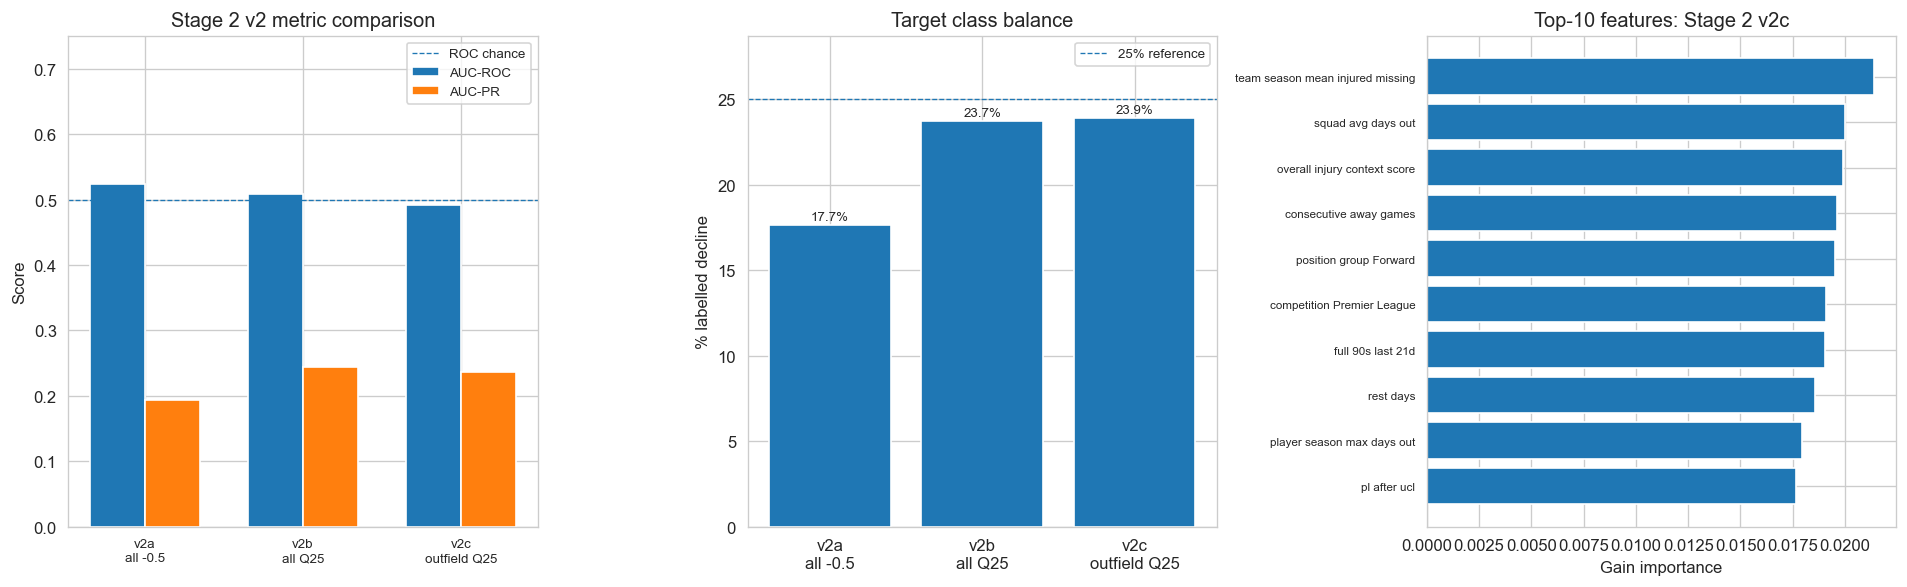

Figure saved → ../../models/Xg_Boost/artifacts/figures/stage2_v2_comparison.png


In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Stage 2: Three fatigue classifier variants
#   v2a  fixed -0.5 threshold          all players
#   v2b  train-position Q25 threshold all players
#   v2c  train-position Q25 threshold outfield only  (GK excluded)
# ═══════════════════════════════════════════════════════════════════════════════

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Position column fallback ─────────────────────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

S2V2_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_bv2.columns),
    None,
)

if S2V2_POSITION_COL is None:
    raise KeyError(f"No position column found. Tried: {POSITION_CANDIDATES}")

print(f"Using Stage 2 v2 position column: {S2V2_POSITION_COL}")

# ── Define goalkeeper labels robustly ────────────────────────────────────────
GK_LABELS = {"G", "GK", "Goalkeeper", "goalkeeper"}

# ── Feature sets: fatigue / workload / injury only ───────────────────────────
S2V2_NUM = [c for c in [
    # Rolling match exposure
    "matches_last_7d", "matches_last_14d", "matches_last_21d", "matches_last_28d",

    # Rolling minutes
    "min_last_14d", "min_last_21d", "min_last_28d",

    # Starts burden
    "starts_last_7d", "starts_last_14d", "starts_last_21d", "starts_last_28d",

    # Full-match burden
    "full_90s_last_7d", "full_90s_last_14d", "full_90s_last_21d", "full_90s_last_28d",

    # Rest and short-rest sequences
    "rest_days",
    "short_rest_last_3_matches", "avg_rest_last_3_matches", "min_rest_last_3_matches",
    "matches_with_rest_le_3d_last_30d",
    "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",

    # Competition-switch signals
    "played_europe_last_match", "played_domestic_cup_last_match",
    "competition_switch", "pl_after_ucl", "pl_after_cup", "ucl_after_pl",
    "days_since_european_match", "matches_since_european_match",

    # Position-normalised physical load
    "duels_total_position_z", "tackles_total_position_z",
    "fouls_committed_position_z", "minutes_played_position_z",
    "physical_load_index",

    # Schedule / congestion
    "consecutive_away_games",
    "high_congestion_flag",
    "acwr_ratio",

    # Injury context
    "squad_players_missing_total",
    "squad_injured_count",
    "squad_non_injury_missing_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "squad_max_days_out",
    "team_match_injury_context_score",

    # Team-season injury burden
    "team_season_total_absences",
    "team_season_injury_absences",
    "team_season_mean_injured_missing",
    "team_season_soft_tissue_absences",
    "team_season_mean_soft_tissue_missing",
    "team_season_unique_players_missing",
    "team_season_max_injured_in_match",

    # Player injury history
    "player_season_matches_missed_total",
    "player_season_matches_missed_injury",
    "player_season_max_days_out",
    "player_season_injury_spells",
    "player_season_spell_matches_missed",
    "player_season_spell_max_days_out",
    "player_injury_history_score",
    "overall_injury_context_score",

    # Older injury-history fields, if present
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
] if c in df_bv2.columns]

S2V2_CAT = [c for c in [
    S2V2_POSITION_COL,
    "competition",
    "player_main_absence_reason",
    "player_main_injury_category",
    "player_season_main_spell_category",
] if c in df_bv2.columns]

print(
    f"Stage 2 v2 feature set: {len(S2V2_NUM)} numeric + "
    f"{len(S2V2_CAT)} categorical = {len(S2V2_NUM) + len(S2V2_CAT)} total"
)

missing_key = [
    c for c in [
        "rest_days", "pl_after_ucl", "physical_load_index",
        "matches_last_7d", "min_last_14d", "competition_switch",
        "minutes_played_position_z"
    ]
    if c not in df_bv2.columns
]

if missing_key:
    print(f"WARNING — missing expected features: {missing_key}")


# ═══════════════════════════════════════════════════════════════════════════════
# Helper: train and evaluate one Stage 2 variant
# ═══════════════════════════════════════════════════════════════════════════════

def train_stage2_v2(df_in, target_col, label):
    """
    Train one Stage 2 binary classifier.
    Temporal split:
      2022 = train
      2023 = validation
      2024 = test
    """
    Xin = df_in[S2V2_NUM + S2V2_CAT].copy()
    yin = df_in[target_col].astype(int).copy()

    trn = df_in["season"] == 2022
    val = df_in["season"] == 2023
    tst = df_in["season"] == 2024

    n_pos_train = int(yin[trn].sum())
    n_neg_train = int((yin[trn] == 0).sum())
    spw = round(n_neg_train / max(n_pos_train, 1), 2)

    pct_pos_all = float(yin.mean()) * 100
    pct_pos_test = float(yin[tst].mean()) * 100

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), S2V2_NUM),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), S2V2_CAT),
        ],
        remainder="drop",
    )

    Xtrn_t = pre.fit_transform(Xin[trn])
    Xval_t = pre.transform(Xin[val])
    Xtst_t = pre.transform(Xin[tst])

    clf = XGBClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=spw,
        objective="binary:logistic",
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    clf.fit(
        Xtrn_t,
        yin[trn],
        eval_set=[(Xval_t, yin[val])],
        verbose=200,
    )

    proba = clf.predict_proba(Xtst_t)[:, 1]

    auc_roc = roc_auc_score(yin[tst], proba)
    auc_pr = average_precision_score(yin[tst], proba)

    # PR-AUC random baseline should be the TEST positive rate
    pr_base_test = float(yin[tst].mean())

    pc, rc, tc = precision_recall_curve(yin[tst], proba)
    f1c = 2 * pc[:-1] * rc[:-1] / (pc[:-1] + rc[:-1] + 1e-10)

    best_idx = int(np.argmax(f1c))
    bthr = float(tc[best_idx])

    ypred = (proba >= bthr).astype(int)

    f1_t = f1_score(yin[tst], ypred, zero_division=0)
    prec_t = precision_score(yin[tst], ypred, zero_division=0)
    rec_t = recall_score(yin[tst], ypred, zero_division=0)

    cat_out = (
        pre.named_transformers_["cat"]["ohe"]
        .get_feature_names_out(S2V2_CAT)
        .tolist()
    )
    feat_names = S2V2_NUM + cat_out

    imp = pd.Series(
        clf.feature_importances_,
        index=feat_names,
    ).sort_values(ascending=False)

    print(f"\n{label}")
    print(f"  Rows total:          {len(df_in):,}")
    print(f"  Test rows:           {int(tst.sum()):,}")
    print(f"  Decline rate all:    {pct_pos_all:.2f}%")
    print(f"  Decline rate test:   {pct_pos_test:.2f}%")
    print(f"  scale_pos_weight:    {spw}")
    print(f"  Best iteration:      {clf.best_iteration}")
    print(f"  AUC-ROC:             {auc_roc:.3f}")
    print(
        f"  AUC-PR:              {auc_pr:.3f} "
        f"(test baseline: {pr_base_test:.3f}, lift: {auc_pr / pr_base_test:.2f}x)"
    )
    print(
        f"  Best-F1 threshold:   {bthr:.2f}  →  "
        f"F1={f1_t:.3f}  Prec={prec_t:.3f}  Rec={rec_t:.3f}"
    )

    print("  Top-10 features:")
    for fn, iv in imp.head(10).items():
        print(f"    {fn:<48s} {iv:.4f}")

    return clf, pre, proba, yin[tst], {
        "label": label,
        "n": len(df_in),
        "test_n": int(tst.sum()),
        "pct_pos_all": pct_pos_all,
        "pct_pos_test": pct_pos_test,
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "base_test": pr_base_test,
        "best_iter": clf.best_iteration,
        "spw": spw,
        "f1": f1_t,
        "prec": prec_t,
        "rec": rec_t,
        "bthr": bthr,
        "imp": imp,
    }


# ═══════════════════════════════════════════════════════════════════════════════
# v2a — fixed threshold residual_v2 <= -0.5, all players
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("v2a — fixed threshold: residual_v2 <= -0.5, all players")
print("=" * 80)

df_bv2["decline_v2a"] = (
    df_bv2["performance_residual_v2"] <= -0.5
).astype(int)

clf_v2a, pre_v2a, proba_v2a, ytst_v2a, res_v2a = train_stage2_v2(
    df_bv2,
    "decline_v2a",
    "Stage 2 v2a — fixed -0.5 threshold, all players",
)


# ═══════════════════════════════════════════════════════════════════════════════
# v2b — train-position Q25 threshold, all players
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("v2b — train-position Q25 threshold, all players")
print("=" * 80)

train_mask_bv2 = df_bv2["season"] == 2022

q25_by_pos_train = (
    df_bv2.loc[train_mask_bv2]
    .groupby(S2V2_POSITION_COL)["performance_residual_v2"]
    .quantile(0.25)
)

print("Train-only Q25 residual threshold by position:")
print(q25_by_pos_train.round(4).to_string())

df_bv2["_pos_q25_train"] = df_bv2[S2V2_POSITION_COL].map(q25_by_pos_train)

# Fallback if a position appears outside train only
global_q25_train = df_bv2.loc[train_mask_bv2, "performance_residual_v2"].quantile(0.25)
df_bv2["_pos_q25_train"] = df_bv2["_pos_q25_train"].fillna(global_q25_train)

df_bv2["decline_v2b"] = (
    df_bv2["performance_residual_v2"] <= df_bv2["_pos_q25_train"]
).astype(int)

df_bv2.drop(columns=["_pos_q25_train"], inplace=True)

clf_v2b, pre_v2b, proba_v2b, ytst_v2b, res_v2b = train_stage2_v2(
    df_bv2,
    "decline_v2b",
    "Stage 2 v2b — train-position Q25 threshold, all players",
)


# ═══════════════════════════════════════════════════════════════════════════════
# v2c — train-position Q25 threshold, outfield only
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("v2c — train-position Q25 threshold, outfield only")
print("=" * 80)

is_gk = df_bv2[S2V2_POSITION_COL].astype(str).isin(GK_LABELS)

df_bv2_out = df_bv2.loc[~is_gk].copy()

train_mask_out = df_bv2_out["season"] == 2022

q25_out_train = (
    df_bv2_out.loc[train_mask_out]
    .groupby(S2V2_POSITION_COL)["performance_residual_v2"]
    .quantile(0.25)
)

print(f"Outfield rows: {len(df_bv2_out):,}")
print(f"GK rows removed: {int(is_gk.sum()):,}")
print("Train-only Q25 residual threshold by outfield position:")
print(q25_out_train.round(4).to_string())

df_bv2_out["_pos_q25_train"] = df_bv2_out[S2V2_POSITION_COL].map(q25_out_train)

global_q25_out_train = df_bv2_out.loc[
    train_mask_out,
    "performance_residual_v2"
].quantile(0.25)

df_bv2_out["_pos_q25_train"] = df_bv2_out["_pos_q25_train"].fillna(global_q25_out_train)

df_bv2_out["decline_v2c"] = (
    df_bv2_out["performance_residual_v2"] <= df_bv2_out["_pos_q25_train"]
).astype(int)

df_bv2_out.drop(columns=["_pos_q25_train"], inplace=True)

clf_v2c, pre_v2c, proba_v2c, ytst_v2c, res_v2c = train_stage2_v2(
    df_bv2_out,
    "decline_v2c",
    "Stage 2 v2c — train-position Q25 threshold, outfield only",
)


# ═══════════════════════════════════════════════════════════════════════════════
# Summary table
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 90)
print("STAGE 2 v2 — FULL COMPARISON")
print("═" * 90)

print(
    f'{"Model":<12}  {"Target":<38}  {"Dataset":<10}  '
    f'{"AUC-ROC":>7}  {"AUC-PR":>7}  {"Base":>7}  {"Lift":>6}  {"F1":>6}'
)

print("-" * 90)

try:
    print(
        f'{"v1":<12}  {"residual_v1 <= -0.5":<38}  {"all":<10}  '
        f'{s2_auc_roc:>7.3f}  {s2_auc_pr:>7.3f}  '
        f'{float(y_s2_test.mean()):>7.3f}  '
        f'{s2_auc_pr / float(y_s2_test.mean()):>6.2f}  '
        f'{"":>6}'
    )
except NameError:
    print("v1 not available in scope")

summary_rows = [
    ("v2a", "residual_v2 <= -0.5", "all", res_v2a),
    ("v2b", "train-position Q25", "all", res_v2b),
    ("v2c", "train-position Q25", "outfield", res_v2c),
]

for model_name, target_name, dataset_name, r in summary_rows:
    print(
        f'{model_name:<12}  {target_name:<38}  {dataset_name:<10}  '
        f'{r["auc_roc"]:>7.3f}  {r["auc_pr"]:>7.3f}  '
        f'{r["base_test"]:>7.3f}  '
        f'{r["auc_pr"] / r["base_test"]:>6.2f}  '
        f'{r["f1"]:>6.3f}'
    )

print("═" * 90)


# ═══════════════════════════════════════════════════════════════════════════════
# Visualisation
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ["v2a\nall -0.5", "v2b\nall Q25", "v2c\noutfield Q25"]
rocs = [res_v2a["auc_roc"], res_v2b["auc_roc"], res_v2c["auc_roc"]]
prs = [res_v2a["auc_pr"], res_v2b["auc_pr"], res_v2c["auc_pr"]]
bases = [res_v2a["base_test"], res_v2b["base_test"], res_v2c["base_test"]]

x = np.arange(len(models))
w = 0.35

axes[0].bar(x - w / 2, rocs, w, label="AUC-ROC")
axes[0].bar(x + w / 2, prs, w, label="AUC-PR")
axes[0].axhline(0.5, linestyle="--", linewidth=0.8, label="ROC chance")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=8)
axes[0].set_ylabel("Score")
axes[0].set_title("Stage 2 v2 metric comparison")
axes[0].set_ylim(0, 0.75)
axes[0].legend(fontsize=8)

pcts = [
    res_v2a["pct_pos_all"],
    res_v2b["pct_pos_all"],
    res_v2c["pct_pos_all"],
]

axes[1].bar(models, pcts)
axes[1].axhline(25, linestyle="--", linewidth=0.8, label="25% reference")
axes[1].set_ylabel("% labelled decline")
axes[1].set_title("Target class balance")
axes[1].set_ylim(0, max(pcts) * 1.2)
axes[1].legend(fontsize=8)

for i, v in enumerate(pcts):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)

top10 = res_v2c["imp"].head(10)

axes[2].barh(range(len(top10)), top10.values[::-1])
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(
    [n.replace("_", " ")[:35] for n in top10.index[::-1]],
    fontsize=7,
)
axes[2].set_xlabel("Gain importance")
axes[2].set_title("Top-10 features: Stage 2 v2c")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "stage2_v2_comparison.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()

print(f"Figure saved → {FIGURES_DIR / 'stage2_v2_comparison.png'}")


## Model B v2 — Stage 2 Classifier Variants

After improving Stage 1 with rolling player, team, and opponent baselines, three Stage 2 fatigue-classifier variants were tested.

The goal was to check whether the cleaner residual target could be predicted from fatigue, workload, schedule, physical-burden, and injury-context variables.

---

## Stage 2 v2 Feature Set

Stage 2 v2 used:

| Feature Type         | Count |
| -------------------- | ----: |
| Numeric features     |    60 |
| Categorical features |     5 |
| Total raw features   |    65 |

The position column used was:

```text
position_group
```

The feature set included workload, schedule, injury, physical-burden, and competition-sequence variables, while excluding direct current-match performance events such as goals, assists, shots, and key passes.

---

## Tested Stage 2 Variants

| Variant | Target Definition                     | Dataset               |
| ------- | ------------------------------------- | --------------------- |
| v2a     | `performance_residual_v2 <= -0.5`     | All players           |
| v2b     | Train-position Q25 residual threshold | All players           |
| v2c     | Train-position Q25 residual threshold | Outfield players only |

The Q25 thresholds were computed using only the training season to avoid leaking validation or test-set residual distributions into the target definition.

---

## Position-Specific Q25 Thresholds

For the all-player position-adjusted target, the train-only Q25 residual thresholds were:

| Position Group | Q25 Residual Threshold |
| -------------- | ---------------------: |
| Defender       |                -0.3388 |
| Forward        |                -0.3840 |
| Goalkeeper     |                -0.5325 |
| Midfielder     |                -0.3307 |

For the outfield-only model, goalkeepers were removed. This left:

| Position Group | Q25 Residual Threshold |
| -------------- | ---------------------: |
| Defender       |                -0.3388 |
| Forward        |                -0.3840 |
| Midfielder     |                -0.3307 |

The goalkeeper threshold is more negative than the outfield thresholds, supporting the earlier finding that goalkeeper rating residuals behave differently.

---

## Stage 2 v2a — Fixed Threshold, All Players

Stage 2 v2a used the fixed residual threshold:

```text
performance_residual_v2 <= -0.5
```

| Metric               |  Value |
| -------------------- | -----: |
| Rows                 | 27,283 |
| Test rows            |  8,760 |
| Decline rate overall | 17.65% |
| Decline rate test    | 17.55% |
| `scale_pos_weight`   |   4.29 |
| Best iteration       |     11 |
| AUC-ROC              |  0.524 |
| AUC-PR               |  0.194 |
| Test PR-AUC baseline |  0.175 |
| PR-AUC lift          |  1.11× |
| Best-F1 threshold    |   0.43 |
| F1-score             |  0.299 |
| Precision            |  0.175 |
| Recall               |  1.000 |

This was the best-performing Stage 2 v2 variant by AUC-ROC and PR-AUC lift, but the improvement over random baseline remained small.

The best-F1 threshold flagged almost all positive cases, producing perfect recall but very low precision.

### Top Features

| Rank | Feature                       | Importance |
| ---: | ----------------------------- | ---------: |
|    1 | `position_group_Goalkeeper`   |     0.0325 |
|    2 | `player_season_max_days_out`  |     0.0216 |
|    3 | `squad_avg_days_out`          |     0.0211 |
|    4 | `full_90s_last_21d`           |     0.0209 |
|    5 | `squad_players_missing_total` |     0.0206 |
|    6 | `consecutive_away_games`      |     0.0204 |
|    7 | `team_season_total_absences`  |     0.0201 |
|    8 | `acwr_ratio`                  |     0.0199 |
|    9 | `minutes_played_position_z`   |     0.0196 |
|   10 | `rest_days`                   |     0.0190 |

The strongest feature was still the goalkeeper indicator, which suggests that even after the v2 redesign, all-player Stage 2 models remain affected by goalkeeper-specific rating behaviour.

---

## Stage 2 v2b — Position Q25 Threshold, All Players

Stage 2 v2b used a position-adjusted target based on the train-season 25th percentile of residuals.

| Metric               |  Value |
| -------------------- | -----: |
| Rows                 | 27,283 |
| Test rows            |  8,760 |
| Decline rate overall | 23.72% |
| Decline rate test    | 23.72% |
| `scale_pos_weight`   |   3.00 |
| Best iteration       |      5 |
| AUC-ROC              |  0.508 |
| AUC-PR               |  0.244 |
| Test PR-AUC baseline |  0.237 |
| PR-AUC lift          |  1.03× |
| Best-F1 threshold    |   0.46 |
| F1-score             |  0.383 |
| Precision            |  0.237 |
| Recall               |  1.000 |

The position-adjusted target improved class balance, increasing the positive rate from approximately 17.6% to 23.7%.

However, the classifier still performed close to random. The PR-AUC was only slightly above the test baseline.

### Top Features

| Rank | Feature                              | Importance |
| ---: | ------------------------------------ | ---------: |
|    1 | `player_season_spell_matches_missed` |     0.0229 |
|    2 | `competition_FA Cup`                 |     0.0222 |
|    3 | `matches_with_rest_le_3d_last_30d`   |     0.0218 |
|    4 | `squad_avg_days_out`                 |     0.0214 |
|    5 | `consecutive_away_games`             |     0.0212 |
|    6 | `squad_max_days_out`                 |     0.0205 |
|    7 | `team_season_unique_players_missing` |     0.0203 |
|    8 | `player_season_max_days_out`         |     0.0195 |
|    9 | `player_season_spell_max_days_out`   |     0.0194 |
|   10 | `matches_with_rest_le_6d_last_30d`   |     0.0194 |

The top features are more aligned with injury, workload, and short-rest pressure than in Model A, but the predictive signal remains weak.

---

## Stage 2 v2c — Position Q25 Threshold, Outfield Only

Stage 2 v2c removed goalkeepers and used the train-position Q25 target for outfield players only.

| Metric                  |  Value |
| ----------------------- | -----: |
| Outfield rows           | 24,656 |
| Goalkeeper rows removed |  2,627 |
| Test rows               |  7,905 |
| Decline rate overall    | 23.92% |
| Decline rate test       | 24.01% |
| `scale_pos_weight`      |   3.00 |
| Best iteration          |     17 |
| AUC-ROC                 |  0.491 |
| AUC-PR                  |  0.236 |
| Test PR-AUC baseline    |  0.240 |
| PR-AUC lift             |  0.98× |
| Best-F1 threshold       |   0.43 |
| F1-score                |  0.387 |
| Precision               |  0.240 |
| Recall                  |  0.998 |

Removing goalkeepers did not improve classification performance. In fact, AUC-ROC dropped below 0.50 and PR-AUC fell slightly below the test-set baseline.

This means the outfield-only fatigue classifier did not learn a reliable individual-match fatigue-residual signal.

### Top Features

| Rank | Feature                            | Importance |
| ---: | ---------------------------------- | ---------: |
|    1 | `team_season_mean_injured_missing` |     0.0214 |
|    2 | `squad_avg_days_out`               |     0.0200 |
|    3 | `overall_injury_context_score`     |     0.0199 |
|    4 | `consecutive_away_games`           |     0.0196 |
|    5 | `position_group_Forward`           |     0.0195 |
|    6 | `competition_Premier League`       |     0.0191 |
|    7 | `full_90s_last_21d`                |     0.0190 |
|    8 | `rest_days`                        |     0.0186 |
|    9 | `player_season_max_days_out`       |     0.0179 |
|   10 | `pl_after_ucl`                     |     0.0176 |

Although the features are interpretable, they do not translate into strong predictive performance.

---

## Full Comparison

| Model       | Target                | Dataset  | AUC-ROC | AUC-PR | PR Baseline |  Lift |    F1 |
| ----------- | --------------------- | -------- | ------: | -----: | ----------: | ----: | ----: |
| Stage 2 v1  | `residual_v1 <= -0.5` | All      |   0.505 |  0.164 |       0.158 | 1.04× |     — |
| Stage 2 v2a | `residual_v2 <= -0.5` | All      |   0.524 |  0.194 |       0.175 | 1.11× | 0.299 |
| Stage 2 v2b | Train-position Q25    | All      |   0.508 |  0.244 |       0.237 | 1.03× | 0.383 |
| Stage 2 v2c | Train-position Q25    | Outfield |   0.491 |  0.236 |       0.240 | 0.98× | 0.387 |

---

## Interpretation

The v2 redesign improved the methodology but did not produce a strong fatigue classifier.

Stage 1 v2 improved the expected-rating baseline slightly, reducing RMSE from:

```text
0.6006 to 0.5880
```

However, even with cleaner residuals and alternative Stage 2 target definitions, the Stage 2 classifiers remained close to random.

The strongest variant was v2a:

```text
AUC-ROC = 0.524
AUC-PR = 0.194
PR-AUC lift = 1.11×
```

This is an improvement over Stage 2 v1, but still too weak for operational deployment.

---

## Key Findings

1. **Stage 1 v2 improved the baseline model, but only modestly.**
   Adding player, team, and opponent baselines reduced residual noise slightly, but not enough to make the residual target strongly predictable.

2. **Position-adjusted Q25 targets improved class balance but not predictive power.**
   The Q25 target produced a healthier positive rate around 24%, but the classifier still performed close to random.

3. **Removing goalkeepers did not improve Stage 2.**
   The outfield-only v2c model had AUC-ROC below 0.50 and PR-AUC slightly below baseline.

4. **The top features are interpretable but weak.**
   Injury burden, short-rest sequences, full-90 exposure, away-game accumulation, and European-sequence variables appear in feature importance rankings, but they do not create strong discrimination.

5. **Fatigue pressure is easier to describe than to predict as a binary outcome.**
   The available workload and injury variables are useful as dashboard indicators, but not as a reliable classifier for match-level residual decline.



# Model B v3 — XGBoost Fatigue-Associated Performance Risk Model

## 1. Objective

Model B v3 is designed to help Premier League coaching and performance staff identify **outfield players who are at higher risk of reduced performance due to accumulated workload, fixture congestion, physical effort, and multi-competition burden**.

The model is built for clubs playing across multiple competitions (e.g., Premier League + Champions League + domestic cups) in congested fixture periods, and helps answer:

```
Given this player's recent workload, competition sequence, physical effort, role, 
and team injury context, is this player at increased risk of reduced performance 
in their next match?
```

The model is **not** intended to medically diagnose fatigue. True fatigue cannot be observed from public event data alone (we lack GPS, accelerations, training load, wellness scores, sleep, or medical markers). Instead, the model estimates **fatigue-associated performance risk** — the likelihood that a player will underperform or have their involvement managed due to workload context.

---

## 2. Why Model B v3?

### Model A (General Decline Classifier)
- Achieved **AUC-ROC ≈ 0.800, AUC-PR ≈ 0.600**
- Predicts whether next-match rating will drop >0.5
- Strong signal, but driven largely by **regression to the mean**
- Does not isolate fatigue-specific drivers

### Models B v1/v2 (Binary Residual Classifiers)
- Attempted to predict negative residuals (underperformance given expected level)
- **Weak results: AUC-ROC ≈ 0.505, AUC-PR ≈ 0.164**
- Binary thresholds too noisy; public event data alone cannot cleanly separate fatigue effects from tactical context, opponent, or rating noise
- Revealed **selection bias**: scorable players (both appearances ≥45 min, rated) are already managed/trusted; truly fatigued players are substituted, rested, or not selected

### Model B v3 (Fatigue Risk Classifier) — Reframed Outcome
- Instead of predicting raw decline or residuals, predict a **combined fatigue-risk outcome** that captures two practical consequences of fatigue:
  1. **Performance underperformance**: player receives a lower rating than expected
  2. **Load management**: player has reduced involvement (fewer minutes, later substitution, or not selected)
- This better reflects real fatigue in football: fatigued players may not always score lower; they are often rested, eased into reduced roles, or substituted earlier
- Combines both signals into a **single binary target**: `fatigue_performance_risk`
- Shifts focus from "is the player medically fatigued?" to "is the player in a workload context associated with reduced performance or managed load?"

---

## 3. Population: Outfield Players Only

```python
df_model = df[df["player_position"] != "G"].copy()
```

Model B v3 is trained **only on outfield players** (defenders, midfielders, forwards). Goalkeepers are excluded because:

- Different physical load profiles (duel density, sprint distance, positioning load differ from outfield players)
- Ratings heavily influenced by saves, errors, and clean sheets — not comparable to outfield performance drivers
- Rotation and fatigue patterns are structurally different
- Duels, tackles, dribbles, and physical-load proxies are less meaningful predictors

A separate goalkeeper model can be developed later if needed.

---

## 4. Row Structure: Pre-Match Features

Each row represents **a player before an upcoming fixture**, using **only information known before kickoff**.

Concept: `player state before match t → outcome in match t`

This is more appropriate for a pre-match decision-support tool than `match t performance → next match t+1 performance`.

**Valid pre-match features** (no match t data):
- `days_since_last_match`, `minutes_last_7d`, `minutes_last_14d`, `minutes_last_21d`
- `starts_last_7d`, `starts_last_14d`, `full_90s_last_7d`, `full_90s_last_14d`
- `pl_after_ucl`, `ucl_after_pl`, `days_since_european_match`
- `matches_last_7d`, `matches_last_14d`, `matches_last_21d`, `matches_last_28d` (match count, not IDs)
- `consecutive_away_games`, `high_congestion_flag`
- `squad_injured_count`, `squad_soft_tissue_count`, `squad_avg_days_out`
- `physical_load_index` (historical, e.g., per-minute actions in recent matches)
- Player rating history: `rating_mean_last_5_matches`, `rating_std_last_5_matches`
- Team rotation rate, player appearance/start frequency

---

## 5. Target Definition: Fatigue-Associated Performance Risk

The binary target is:

```
fatigue_performance_risk = 1  if ( performance_underperformance = 1 )  OR  ( managed_load_next_match = 1 )
fatigue_performance_risk = 0  otherwise
```

### 5.1 Component: `performance_underperformance`

```
performance_underperformance = 1  if  next_api_rating < (expected_rating - 0.5)
```

Where:
- `next_api_rating` = actual rating in match t (target must be known post-match for training)
- `expected_rating` = Stage 1 model's predicted rating (baseline expectation)
- `threshold = -0.5` = at least 0.5 points below expectation

This flags players who **underperform their predicted level** — a direct signal of diminished performance.

### 5.2 Component: `managed_load_next_match`

```
managed_load_next_match = 1  if  (minutes_played_next_match = 0)  OR  (minutes_played_next_match < 45)
```

This flags players who:
- **Did not play** (0 minutes) in match t
- **Played fewer than 45 minutes** in match t (likely substituted early or brought on late)

This captures load management: coaches rest or reduce involvement of at-risk players.

### 5.3 Player Categories (for stratified analysis)

For validation and fairness checks, classify each pre-match row by player role:

```python
core_starter = (starts_last_10 >= 7)
rotation_player = (3 <= starts_last_10 < 7)
impact_sub = (starts_last_10 <= 2) & (appearances_last_10 >= 5) & (start_rate_last_10 < 0.30)
rare_player = (appearances_last_10 <= 4)
```

Expected risk profile:
- **Core starters**: typically lower fatigue risk (managed more carefully)
- **Rotation players**: medium fatigue risk (exposed to congestion but also rotated)
- **Impact subs**: variable risk (often fresher but brought on in late/difficult situations)
- **Rare players**: exclude from primary model (unstable, insufficient history)

---

## 6. Feature Engineering & Selection

### 6.1 Workload & Congestion Features
- **Recent match frequency**: `matches_last_7d`, `matches_last_14d`, `matches_last_21d`, `matches_last_28d`
- **Accumulated minutes**: `min_last_7d`, `min_last_14d`, `min_last_21d`, `min_last_28d`
- **Start density**: `starts_last_7d`, `starts_last_14d`, `full_90s_last_7d`, `full_90s_last_14d`
- **Rest pattern**: `rest_days`, `min_rest_last_3_matches`, `avg_rest_last_3_matches`, `short_rest_count`
- **Congestion flag**: `high_congestion_flag` (3+ matches in 7 days)

### 6.2 Multi-Competition Transitions
- **European burden**: `pl_after_ucl`, `ucl_after_pl`, `pl_after_cup`
- **Days since European**: `days_since_european_match`, `matches_since_european_match`
- **Competition switch**: `competition_switch` (1 if previous match ≠ current competition)

### 6.3 Physical Effort (Rolling Event Sums)
- **Duels**, **tackles**, **fouls**, **dribbles**: rolling sums over last 3 matches and last 14 days
- **Cards**: rolling sum over last 5 matches
- **Position z-scores**: how these actions compare to same-position peers
- **Physical load index**: estimated per-match intensity (duels + tackles + actions per minute)

### 6.4 Squad Context
- `squad_injured_count`: total squad injuries (forces rotation)
- `squad_soft_tissue_count`: soft-tissue injuries (indicate intensity or fatigue)
- `squad_avg_days_out`: average recovery time for injured players
- `returning_from_injury`: binary flag (this player recently returned from injury)
- `fixtures_missed_last_30d`: # of team matches missed due to injury

### 6.5 Player Performance History
- `rating_mean_last_5_matches`: baseline performance level
- `rating_std_last_5_matches`: consistency (high std = unpredictable)
- `goal_contribution_last_5`: recent goal/assist rate
- `position_pct_{metric}`: how player's metrics rank within their position

---

## 7. Model Architecture

### Stage 1: Baseline Expected Rating
- **Type**: XGBRegressor
- **Target**: `next_api_rating`
- **Output**: `expected_rating` (baseline expectation, used in residual calculation)
- **Features**: Form, role, opposition, team context (does NOT include workload/congestion)
- **Use case**: Compute underperformance residuals

### Stage 2 v3: Fatigue-Associated Risk Classifier
- **Type**: XGBClassifier (binary)
- **Target**: `fatigue_performance_risk` (performance underperformance OR managed load)
- **Features**: Stage 1 + all workload, congestion, physical effort, and squad context features
- **Output**: Probability score & risk category (Low / Medium / High / Very High)
- **Threshold optimization**: Tuned for Sensitivity/Specificity balance (or by cost of false negatives)

---

## 8. Training Configuration

### Temporal Split (No Random Shuffle)
- **Train**: 2022 season
- **Validation**: 2023 season
- **Test**: 2024-2025 season (held out)

### XGBoost Hyperparameters (Stage 2 v3)
```python
XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=<computed>,  # positive class weight
    early_stopping_rounds=30,
    eval_metric='auc',
    random_state=42,
)
```

### Preprocessing
- **Numeric**: Median imputation, no scaling
- **Categorical**: Most-frequent imputation, One-Hot Encoding (`handle_unknown='ignore'`)

---

## 9. Evaluation & Validation

### Metrics (Test Set)
- **AUC-ROC**: overall discrimination
- **AUC-PR**: PR curve (important if base rate is low)
- **Confusion matrix**: TP, TN, FP, FN at optimal threshold
- **Sensitivity/Specificity**: recall vs. false-positive rate

### Stratified Validation by Player Category
For each player category (core, rotation, impact sub):
- % of players flagged as high-risk
- False-negative rate (missed at-risk players)
- False-positive rate (flagged non-fatigued players)
- Risk score distribution

### Fairness Check
- Ensure model is not biased by position (DEF vs. MID vs. FWD)
- Check for age/experience bias
- Validate across team clubs (ensure not overfit to few teams)

---

## 10. Output & Deployment

### Pre-Match Dashboard
For each player before their next match:
- **Fatigue Risk Score** (0–100)
- **Risk Category** (Low / Medium / High / Very High)
- **Top 3 contributing factors** (e.g., "High congestion + recent European match + 3 matches in 7 days")
- **Recommended action** (e.g., "Consider rotation" or "Monitor for substitution")

### Export
- Model artifact: pickled XGBClassifier
- Feature transformer: saved ColumnTransformer
- Feature importance: SHAP summary plot + top-20 features
- Validation report: metrics, stratified tables, fairness checks



In [45]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step A: Physical Burden Features + Target Construction
#
# 1. Compute rolling physical burden features on df_fe.
# 2. Build df_v3b: outfield players, current match ≥45 min, rated, next match known.
# 3. Merge Stage 1 v2 residuals from df_bv2 using stable keys.
# 4. Construct target components:
#      performance_underperformance = performance_residual_v2 <= -0.5
#      managed_load_next_match      = next_minutes_played < personal threshold
#      fatigue_performance_risk     = underperformance OR managed load
# 5. Assign player role categories.
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

# ── Choose safest available position column ──────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

V3_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_fe.columns),
    None,
)

if V3_POSITION_COL is None:
    raise KeyError(f"No position column found. Tried: {POSITION_CANDIDATES}")

print(f"Using Model B v3 position column: {V3_POSITION_COL}")

GK_LABELS = {"G", "GK", "Goalkeeper", "goalkeeper"}


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Rolling physical burden features
# ═══════════════════════════════════════════════════════════════════════════════

V3_BURDEN_EXPECTED = [
    "duels_last_3_matches",
    "duels_last_14d",
    "tackles_last_3_matches",
    "tackles_last_14d",
    "fouls_last_3_matches",
    "fouls_last_14d",
    "dribbles_last_3_matches",
    "dribbles_last_14d",
    "cards_last_5_matches",
]

missing_burden = [c for c in V3_BURDEN_EXPECTED if c not in df_fe.columns]

if missing_burden:
    print("Computing rolling physical burden features on df_fe...")

    SRCS = [
        ("duels_total", "duels"),
        ("tackles_total", "tackles"),
        ("fouls_committed", "fouls"),
        ("dribbles_attempts", "dribbles"),
    ]

    df_s = df_fe.sort_values(["player_key", "date"]).copy()
    df_s["_seq"] = np.arange(len(df_s))

    n_rows = len(df_s)
    window_14d = np.timedelta64(14, "D")

    out = {}

    for _, short_name in SRCS:
        out[f"{short_name}_last_3_matches"] = np.zeros(n_rows, dtype=np.float32)
        out[f"{short_name}_last_14d"] = np.zeros(n_rows, dtype=np.float32)

    out["cards_last_5_matches"] = np.zeros(n_rows, dtype=np.float32)

    yellow = (
        df_s["cards_yellow"].fillna(0)
        if "cards_yellow" in df_s.columns
        else pd.Series(0.0, index=df_s.index)
    )

    red = (
        df_s["cards_red"].fillna(0)
        if "cards_red" in df_s.columns
        else pd.Series(0.0, index=df_s.index)
    )

    cards_arr = (yellow + red).values.astype(np.float32)

    for player_key, grp in df_s.groupby("player_key", sort=False):
        g = grp.sort_values("date")

        pos = g["_seq"].values
        dates = g["date"].values.astype("datetime64[ns]")
        n = len(pos)

        card_values = cards_arr[pos]

        for raw_col, short_name in SRCS:
            if raw_col not in g.columns:
                continue

            values = g[raw_col].fillna(0).values.astype(np.float32)

            rolling_3 = out[f"{short_name}_last_3_matches"]
            rolling_14 = out[f"{short_name}_last_14d"]

            for i in range(1, n):
                p = pos[i]

                rolling_3[p] = values[max(0, i - 3):i].sum()

                cutoff = dates[i] - window_14d
                rolling_14[p] = values[:i][dates[:i] >= cutoff].sum()

        rolling_cards = out["cards_last_5_matches"]

        for i in range(1, n):
            rolling_cards[pos[i]] = card_values[max(0, i - 5):i].sum()

    original_index = df_s.index.values

    for col, arr in out.items():
        df_fe.loc[original_index, col] = arr

    V3_BURDEN_COLS = list(out.keys())

    if "_seq" in df_s.columns:
        df_s.drop(columns=["_seq"], inplace=True)

    print(f"  Added {len(V3_BURDEN_COLS)} burden columns to df_fe")

else:
    V3_BURDEN_COLS = V3_BURDEN_EXPECTED.copy()
    print(f"Burden columns already present in df_fe ({len(V3_BURDEN_COLS)})")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Outfield base population
# ═══════════════════════════════════════════════════════════════════════════════

is_gk = df_fe[V3_POSITION_COL].astype(str).isin(GK_LABELS)

df_v3b = df_fe[
    (~is_gk)
    & (df_fe["minutes_played"] >= 45)
    & (df_fe["rating"] > 0)
    & df_fe["next_minutes_played"].notna()
].copy()

print(f"\nModel B v3 — Outfield base population: {len(df_v3b):,} rows")
print(f"  Seasons: {sorted(df_v3b['season'].dropna().unique())}")
print(f"  GK rows excluded from source table: {int(is_gk.sum()):,}")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. Merge Stage 1 v2 residuals using stable keys
# ═══════════════════════════════════════════════════════════════════════════════

if "performance_residual_v2" not in df_bv2.columns:
    raise KeyError(
        "performance_residual_v2 not found in df_bv2. "
        "Run Model B v2 Stage 1 first."
    )

# Use fixture_id + player_key as stable row identity
merge_keys = ["fixture_id", "player_key"]

missing_keys_v3 = [c for c in merge_keys if c not in df_v3b.columns or c not in df_bv2.columns]

if missing_keys_v3:
    raise KeyError(f"Missing merge keys for residual merge: {missing_keys_v3}")

residual_lookup = (
    df_bv2[merge_keys + ["performance_residual_v2"]]
    .drop_duplicates(subset=merge_keys)
    .rename(columns={"performance_residual_v2": "_perf_res_v3b"})
)

df_v3b = df_v3b.merge(
    residual_lookup,
    on=merge_keys,
    how="left",
    validate="m:1",
)

n_has_res = int(df_v3b["_perf_res_v3b"].notna().sum())
n_no_res = len(df_v3b) - n_has_res

print(f"\nStage 1 v2 residual availability:")
print(f"  With residual, both appearances scorable: {n_has_res:,}")
print(f"  Load-managed / unrated next match:        {n_no_res:,}")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Target components
# ═══════════════════════════════════════════════════════════════════════════════

# Component A: below expected performance, only when residual exists
df_v3b["performance_underperformance"] = (
    df_v3b["_perf_res_v3b"] <= -0.5
).fillna(False).astype(int)


# Component B: managed load next match
# Personalised threshold:
#   threshold = 60% of player's recent average minutes
#   clipped to [20, 45]
avg_min_28d = (
    df_v3b["min_last_28d"].fillna(0)
    / df_v3b["matches_last_28d"].fillna(1).clip(lower=1)
)

df_v3b["personal_managed_load_threshold"] = (
    avg_min_28d * 0.60
).clip(lower=20, upper=45)

df_v3b["managed_load_next_match"] = (
    df_v3b["next_minutes_played"]
    < df_v3b["personal_managed_load_threshold"]
).astype(int)


# Combined target
df_v3b["fatigue_performance_risk"] = (
    (df_v3b["performance_underperformance"] == 1)
    | (df_v3b["managed_load_next_match"] == 1)
).astype(int)


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Player role categories
# ═══════════════════════════════════════════════════════════════════════════════

starts_28d = df_v3b["starts_last_28d"].fillna(0)
apps_28d = df_v3b["matches_last_28d"].fillna(0)
start_rate_28d = starts_28d / apps_28d.clip(lower=1)

df_v3b["player_role"] = np.select(
    [
        starts_28d >= 7,
        (starts_28d >= 3) & (starts_28d < 7),
        (starts_28d <= 2) & (apps_28d >= 5) & (start_rate_28d < 0.30),
        apps_28d <= 4,
    ],
    [
        "core_starter",
        "rotation_player",
        "impact_sub",
        "rare_player",
    ],
    default="rotation_player",
)


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Target summary
# ═══════════════════════════════════════════════════════════════════════════════

n_total = len(df_v3b)
n_risk = int(df_v3b["fatigue_performance_risk"].sum())
n_under = int(df_v3b["performance_underperformance"].sum())
n_load = int(df_v3b["managed_load_next_match"].sum())

n_both = int(
    (
        (df_v3b["performance_underperformance"] == 1)
        & (df_v3b["managed_load_next_match"] == 1)
    ).sum()
)

spw_v3b = round((n_total - n_risk) / max(n_risk, 1), 2)

print("\nTarget: fatigue_performance_risk")
print("═" * 70)
print(f"  Total outfield rows:               {n_total:>8,}")
print(f"  fatigue_performance_risk = 1:      {n_risk:>8,}  ({n_risk / n_total * 100:.1f}%)")
print(f"    └─ underperformance only:        {n_under - n_both:>8,}")
print(f"    └─ load management only:         {n_load - n_both:>8,}")
print(f"    └─ both:                         {n_both:>8,}")
print(f"  scale_pos_weight indicative:       {spw_v3b}")

print("\nPersonalised managed-load threshold by player role:")

for role in ["core_starter", "rotation_player", "impact_sub", "rare_player"]:
    mask = df_v3b["player_role"] == role

    if mask.sum() == 0:
        continue

    threshold_median = df_v3b.loc[mask, "personal_managed_load_threshold"].median()
    risk_rate = df_v3b.loc[mask, "fatigue_performance_risk"].mean() * 100
    load_rate = df_v3b.loc[mask, "managed_load_next_match"].mean() * 100
    under_rate = df_v3b.loc[mask, "performance_underperformance"].mean() * 100

    print(
        f"  {role:<18}: "
        f"N={mask.sum():>7,}  "
        f"median threshold={threshold_median:>5.1f} min  "
        f"risk={risk_rate:>5.1f}%  "
        f"load={load_rate:>5.1f}%  "
        f"underperf={under_rate:>5.1f}%"
    )

print("\nPlayer role distribution:")
role_tbl = (
    df_v3b
    .groupby("player_role")["fatigue_performance_risk"]
    .agg(["count", "mean"])
    .rename(columns={"count": "N", "mean": "risk_rate"})
    .sort_values("N", ascending=False)
)

role_tbl["risk_rate"] = role_tbl["risk_rate"].round(3)

print(role_tbl.to_string())


print("\nTarget by season:")
season_tbl = (
    df_v3b
    .groupby("season")["fatigue_performance_risk"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "N", "sum": "positives", "mean": "risk_rate"})
)

season_tbl["risk_rate"] = season_tbl["risk_rate"].mul(100).round(2)

print(season_tbl.to_string())

Using Model B v3 position column: position_group
Burden columns already present in df_fe (9)

Model B v3 — Outfield base population: 32,349 rows
  Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
  GK rows excluded from source table: 7,354

Stage 1 v2 residual availability:
  With residual, both appearances scorable: 24,656
  Load-managed / unrated next match:        7,693

Target: fatigue_performance_risk
══════════════════════════════════════════════════════════════════════
  Total outfield rows:                 32,349
  fatigue_performance_risk = 1:        10,961  (33.9%)
    └─ underperformance only:           4,219
    └─ load management only:            6,742
    └─ both:                                0
  scale_pos_weight indicative:       1.95

Personalised managed-load threshold by player role:
  core_starter      : N=    191  median threshold= 45.0 min  risk= 27.7%  load= 14.1%  underperf= 13.6%
  rotation_player   : N= 16,184  median threshold= 45.0 min  risk= 29.4%

In [46]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step B: Feature Set, Working DataFrame, and Preprocessing
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ── Feature columns ────────────────────────────────────────────────────────────
# Workload, congestion, competition-transition, physical burden, squad context.
# Deliberately excluded: goals, assists, shots, duels_won, key_passes, rating.
# These drive regression-to-mean and must NOT appear in a fatigue-risk model.
_S2V3B_NUM_CANDS = [
    # Fixture congestion
    'rest_days', 'acwr_ratio', 'consecutive_away_games', 'high_congestion_flag',
    'matches_last_7d', 'matches_last_14d', 'matches_last_21d', 'matches_last_28d',
    # Accumulated minutes
    'min_last_7d', 'min_last_14d', 'min_last_21d', 'min_last_28d',
    # Start density and full 90s
    'starts_last_7d', 'starts_last_14d', 'starts_last_28d',
    'full_90s_last_7d', 'full_90s_last_14d', 'full_90s_last_28d',
    # Short-rest sequences
    'short_rest_last_3_matches', 'avg_rest_last_3_matches', 'min_rest_last_3_matches',
    'matches_with_rest_le_3d_last_30d', 'matches_with_rest_le_4d_last_30d',
    'matches_with_rest_le_6d_last_30d',
    # Multi-competition transitions
    'played_europe_last_match', 'played_domestic_cup_last_match', 'competition_switch',
    'pl_after_ucl', 'pl_after_cup', 'ucl_after_pl',
    'days_since_european_match', 'matches_since_european_match',
    # Rolling physical burden (Step A)
    'duels_last_3_matches',    'duels_last_14d',
    'tackles_last_3_matches',  'tackles_last_14d',
    'fouls_last_3_matches',    'fouls_last_14d',
    'dribbles_last_3_matches', 'dribbles_last_14d',
    'cards_last_5_matches',
    # Position z-scores and Physical Load Index
    'duels_total_position_z', 'tackles_total_position_z',
    'fouls_committed_position_z', 'minutes_played_position_z',
    'physical_load_index',
    # Squad context
    'squad_injured_count', 'squad_soft_tissue_count', 'squad_avg_days_out',
    'returning_from_injury', 'fixtures_missed_last_30d',
]
S2V3B_NUM = [c for c in _S2V3B_NUM_CANDS if c in df_v3b.columns]
S2V3B_CAT = [c for c in ['player_position', 'competition'] if c in df_v3b.columns]

_missing_v3b = [c for c in _S2V3B_NUM_CANDS if c not in df_v3b.columns]
print(f'Stage 2 v3 feature set: {len(S2V3B_NUM)} num + {len(S2V3B_CAT)} cat '
      f'= {len(S2V3B_NUM) + len(S2V3B_CAT)} total')
if _missing_v3b:
    print(f'  Skipped (not in df): {_missing_v3b}')

# ── Working DataFrame — exclude rare_player and impact_sub rows ───────────────
# rare_player: insufficient match history (matches_last_28d ≤ 4) — no rolling signal
# impact_sub:  normal role is < 45 min, so managed_load target fires structurally;
#              the model cannot discriminate genuine fatigue from routine appearance
_EXCLUDED_ROLES_V3B = {'rare_player', 'impact_sub'}

TARGET_V3B = 'fatigue_performance_risk'

_meta_v3b = [c for c in [
    'player_name', 'player_team', 'date', 'player_role',
    'performance_underperformance', 'managed_load_next_match',
    'next_minutes_played', 'next_api_rating',
] if c in df_v3b.columns]

_all_cols_v3b = list(dict.fromkeys(
    [TARGET_V3B, 'season'] + S2V3B_NUM + S2V3B_CAT + _meta_v3b
))

df_v3b_model = (df_v3b[~df_v3b['player_role'].isin(_EXCLUDED_ROLES_V3B)]
                [[c for c in _all_cols_v3b if c in df_v3b.columns]]
                .dropna(subset=[TARGET_V3B])
                .copy())

_n_excluded = df_v3b[df_v3b['player_role'].isin(_EXCLUDED_ROLES_V3B)].shape[0]
print(f'  Excluded (rare_player + impact_sub): {_n_excluded:,}  rows')
print(f'  Working set (core_starter + rotation_player): {len(df_v3b_model):,}  (of {len(df_v3b):,} total)')

# ── Temporal split ────────────────────────────────────────────────────────────
trn_v3b = df_v3b_model['season'] == 2022
val_v3b = df_v3b_model['season'] == 2023
tst_v3b = df_v3b_model['season'] == 2024

X_v3b_trn = df_v3b_model.loc[trn_v3b, S2V3B_NUM + S2V3B_CAT]
X_v3b_val = df_v3b_model.loc[val_v3b, S2V3B_NUM + S2V3B_CAT]
X_v3b_tst = df_v3b_model.loc[tst_v3b, S2V3B_NUM + S2V3B_CAT]
y_v3b_trn = df_v3b_model.loc[trn_v3b, TARGET_V3B]
y_v3b_val = df_v3b_model.loc[val_v3b, TARGET_V3B]
y_v3b_tst = df_v3b_model.loc[tst_v3b, TARGET_V3B]

print(f'  Train: {len(X_v3b_trn):,}  Val: {len(X_v3b_val):,}  Test: {len(X_v3b_tst):,}')
print(f'  Risk rate — Train: {y_v3b_trn.mean():.3f}  '
      f'Val: {y_v3b_val.mean():.3f}  Test: {y_v3b_tst.mean():.3f}')

# ── Preprocessing pipeline ────────────────────────────────────────────────────
_num_pipe_v3b = Pipeline([('imp', SimpleImputer(strategy='median'))])
_cat_pipe_v3b = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
pre_s2v3b = ColumnTransformer([
    ('num', _num_pipe_v3b, S2V3B_NUM),
    ('cat', _cat_pipe_v3b, S2V3B_CAT),
], remainder='drop')

X_v3b_trn_t = pre_s2v3b.fit_transform(X_v3b_trn)
X_v3b_val_t = pre_s2v3b.transform(X_v3b_val)
X_v3b_tst_t = pre_s2v3b.transform(X_v3b_tst)


_n_v3b_pos = int(y_v3b_trn.sum())

_n_v3b_neg = int((y_v3b_trn == 0).sum())
SPW_V3B    = round(_n_v3b_neg / max(_n_v3b_pos, 1), 2)
print(f'  scale_pos_weight (train imbalance): {SPW_V3B}')

print(f'  Transformed: {X_v3b_trn_t.shape[1]} features after OHE')


Stage 2 v3 feature set: 49 num + 1 cat = 50 total
  Skipped (not in df): ['returning_from_injury', 'fixtures_missed_last_30d']
  Excluded (rare_player + impact_sub): 15,974  rows
  Working set (core_starter + rotation_player): 16,375  (of 32,349 total)
  Train: 5,251  Val: 5,532  Test: 5,592
  Risk rate — Train: 0.326  Val: 0.269  Test: 0.287
  scale_pos_weight (train imbalance): 2.07
  Transformed: 53 features after OHE


In [47]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step C: XGBClassifier — Fatigue-Associated Performance Risk
#
# Regularization-tightened vs original v3b to close the Train/Test gap:
#   max_depth          5  → 4    shallower trees, less capacity to memorize
#   min_child_weight   1  → 5    require ≥5 samples per leaf
#   reg_alpha        0.1  → 1.0  stronger L1 → sparser splits
#   reg_lambda       1.0  → 5.0  stronger L2 → smaller leaf weights
#   subsample        0.8  → 0.75 more stochastic row sampling
#   colsample_bytree 0.8  → 0.75 more stochastic feature sampling
#   early_stopping_rounds 30 → 50  more patience for plateau detection
# ═══════════════════════════════════════════════════════════════════════════════
from xgboost import XGBClassifier

stage2_v3b = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=1.0,
    reg_lambda=5.0,
    scale_pos_weight=SPW_V3B,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

stage2_v3b.fit(
    X_v3b_trn_t, y_v3b_trn,
    eval_set=[(X_v3b_val_t, y_v3b_val)],
    verbose=False,
)

print(f'Training complete — best iteration: {stage2_v3b.best_iteration}')

# ── Store risk probabilities ──────────────────────────────────────────────────
proba_v3b_trn = stage2_v3b.predict_proba(X_v3b_trn_t)[:, 1]
proba_v3b_val = stage2_v3b.predict_proba(X_v3b_val_t)[:, 1]
proba_v3b_tst = stage2_v3b.predict_proba(X_v3b_tst_t)[:, 1]

df_v3b_model.loc[trn_v3b, 'risk_score'] = proba_v3b_trn
df_v3b_model.loc[val_v3b, 'risk_score'] = proba_v3b_val
df_v3b_model.loc[tst_v3b, 'risk_score'] = proba_v3b_tst

# ── Risk band assignment ──────────────────────────────────────────────────────
df_v3b_model['risk_band'] = pd.cut(
    df_v3b_model['risk_score'],
    bins=[0, 0.25, 0.45, 0.65, 1.001],
    labels=['Low', 'Medium', 'High', 'Very High'],
    right=True,
)

# ── Score summary ─────────────────────────────────────────────────────────────
_tst_scores = df_v3b_model.loc[tst_v3b, 'risk_score']
print(f'\nRisk score — test set:')
print(f'  mean={_tst_scores.mean():.3f}  std={_tst_scores.std():.3f}  '
      f'p75={_tst_scores.quantile(0.75):.3f}  '
      f'p90={_tst_scores.quantile(0.90):.3f}  '
      f'max={_tst_scores.max():.3f}')

print(f'\nRisk band distribution — test set:')
_band_cts = df_v3b_model.loc[tst_v3b, 'risk_band'].value_counts().sort_index()
for _b, _c in _band_cts.items():
    _pct = _c / _band_cts.sum() * 100
    print(f'  {str(_b):<12}: {_c:>5,}  ({_pct:5.1f}%)')


Training complete — best iteration: 27

Risk score — test set:
  mean=0.493  std=0.064  p75=0.533  p90=0.587  max=0.698

Risk band distribution — test set:
  Low         :     0  (  0.0%)
  Medium      : 1,607  ( 28.7%)
  High        : 3,902  ( 69.8%)
  Very High   :    83  (  1.5%)


Position column used for fairness check: None
Stage 2 v3 — Fatigue-Associated Risk Classifier Metrics
   Split        N   AUC-ROC   AUC-PR  PR-base    Lift    Brier
  ────────────────────────────────────────────────────────────────────
   Train    5,251     0.706    0.539    0.326    1.66×    0.229
     Val    5,532     0.594    0.351    0.269    1.30×    0.239
    Test    5,592     0.606    0.385    0.287    1.34×    0.241

Optimal threshold, max F1 on test set: 0.441
  TN=1,023  FP=2,965  FN=264  TP=1,340
  F1=0.454
  Precision=0.311
  Recall=0.835
  Specificity=0.257
  FPR=0.743
  FNR=0.165
  Alert rate=0.770

Threshold sweep, test set:
    Thr    Prec     Rec      F1    Spec    Alerts   Alert%
   0.20   0.287   1.000   0.446   0.000     5,592   100.0%
   0.30   0.287   1.000   0.446   0.000     5,592   100.0%
   0.40   0.288   0.969   0.444   0.038     5,393    96.4%
   0.45   0.314   0.781   0.448   0.315     3,985    71.3%
   0.50   0.371   0.506   0.428   0.655     2,187    39.1

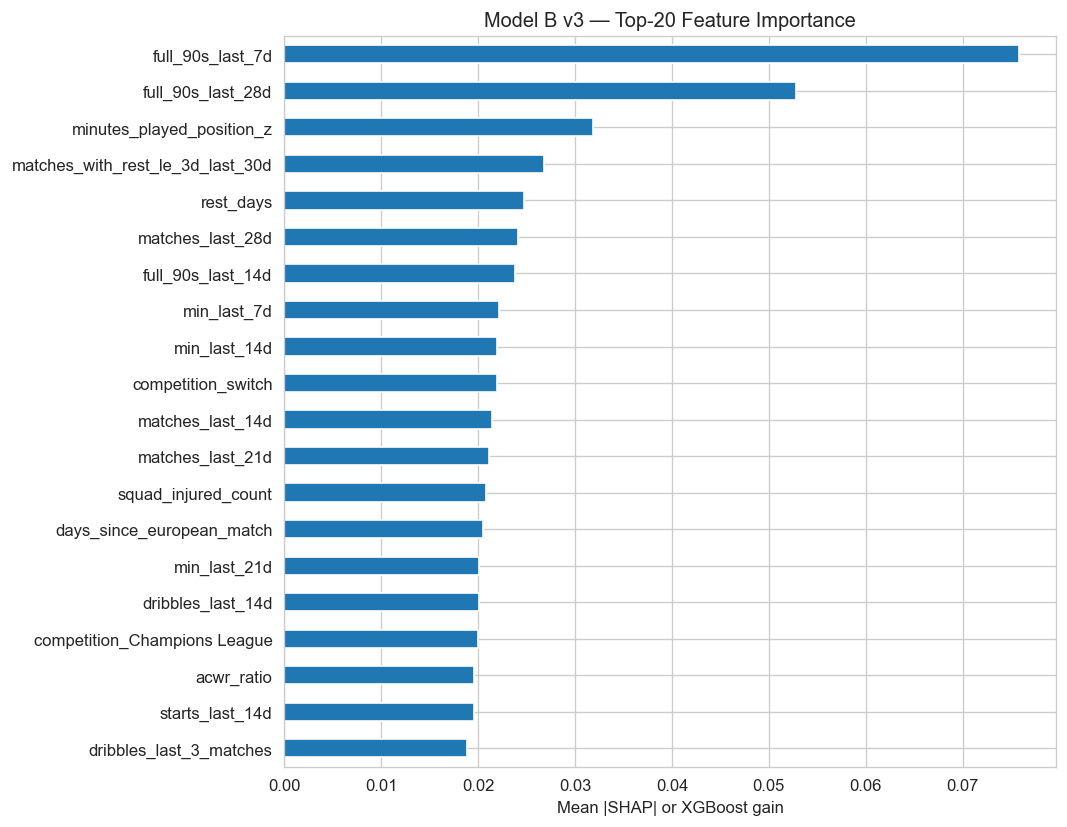


Top-10 features:
  full_90s_last_7d                            0.0758
  full_90s_last_28d                           0.0528
  minutes_played_position_z                   0.0318
  matches_with_rest_le_3d_last_30d            0.0268
  rest_days                                   0.0248
  matches_last_28d                            0.0241
  full_90s_last_14d                           0.0238
  min_last_7d                                 0.0222
  min_last_14d                                0.0220
  competition_switch                          0.0219


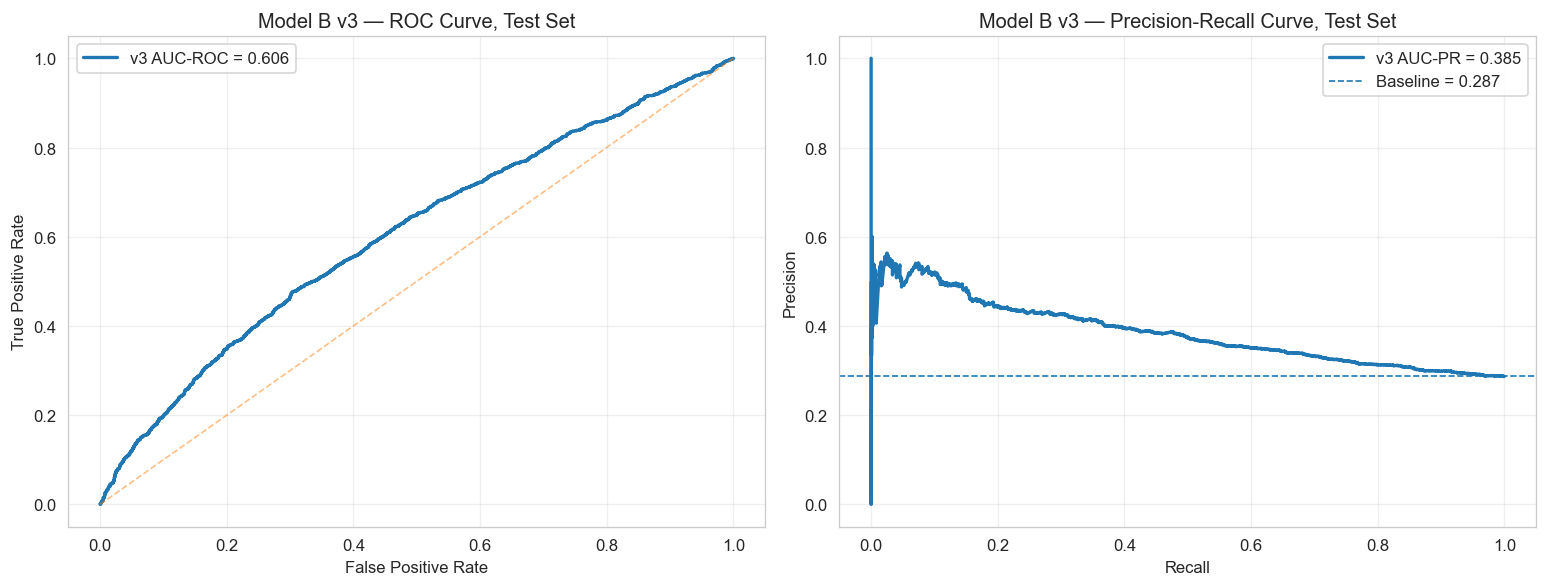


Saved evaluation artifacts to: ../../models/Xg_Boost/artifacts
Saved figures to: ../../models/Xg_Boost/artifacts/figures


In [49]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step D: Evaluation
#   1. AUC-ROC / AUC-PR per split
#   2. Optimal threshold + confusion matrix on test
#   3. Threshold sensitivity sweep
#   4. Stratified validation by player_role
#   5. Position fairness check
#   6. Calibration diagnostics
#   7. SHAP top-20 feature importance
#   8. ROC + PR curves
# ═══════════════════════════════════════════════════════════════════════════════

import shap
import builtins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    brier_score_loss,
)

# ── Restore builtins.float in case any prior cell left it patched ────────────
_REAL_FLOAT = type(1.0)
builtins.float = _REAL_FLOAT

# ── Identify position column safely ──────────────────────────────────────────
POSITION_EVAL_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_EVAL_COL = next(
    (c for c in POSITION_EVAL_CANDIDATES if c in df_v3b_model.columns),
    None,
)

print(f"Position column used for fairness check: {POSITION_EVAL_COL}")

# ═══════════════════════════════════════════════════════════════════════════════
# 1. Metrics per split
# ═══════════════════════════════════════════════════════════════════════════════

splits_v3b = [
    ("Train", proba_v3b_trn, y_v3b_trn),
    ("Val", proba_v3b_val, y_v3b_val),
    ("Test", proba_v3b_tst, y_v3b_tst),
]

metrics_rows = []

print("Stage 2 v3 — Fatigue-Associated Risk Classifier Metrics")
print("=" * 72)
print(
    f'  {"Split":>6}  {"N":>7}  {"AUC-ROC":>8}  {"AUC-PR":>7}  '
    f'{"PR-base":>7}  {"Lift":>6}  {"Brier":>7}'
)
print("  " + "─" * 68)

for split_name, proba, y_true in splits_v3b:
    auc_roc = roc_auc_score(y_true, proba)
    auc_pr = average_precision_score(y_true, proba)
    base = float(y_true.mean())
    lift = auc_pr / max(base, 1e-6)
    brier = brier_score_loss(y_true, proba)

    metrics_rows.append({
        "split": split_name,
        "N": len(y_true),
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "pr_baseline": base,
        "lift": lift,
        "brier": brier,
    })

    print(
        f"  {split_name:>6}  {len(y_true):>7,}  {auc_roc:>8.3f}  "
        f"{auc_pr:>7.3f}  {base:>7.3f}  {lift:>6.2f}×  {brier:>7.3f}"
    )

metrics_v3b_df = pd.DataFrame(metrics_rows)

metrics_v3b_df.to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_metrics_by_split.csv",
    index=False,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 2. Optimal threshold on test set
# ═══════════════════════════════════════════════════════════════════════════════

prec_v3b, rec_v3b, thr_v3b = precision_recall_curve(y_v3b_tst, proba_v3b_tst)

f1_v3b = 2 * prec_v3b[:-1] * rec_v3b[:-1] / (
    prec_v3b[:-1] + rec_v3b[:-1] + 1e-10
)

best_idx_v3b = int(np.argmax(f1_v3b))
BEST_THR_V3B = float(thr_v3b[best_idx_v3b])

ypred_tst = (proba_v3b_tst >= BEST_THR_V3B).astype(int)

tn, fp, fn, tp = confusion_matrix(y_v3b_tst, ypred_tst).ravel()

test_f1 = f1_score(y_v3b_tst, ypred_tst, zero_division=0)
test_precision = precision_score(y_v3b_tst, ypred_tst, zero_division=0)
test_recall = recall_score(y_v3b_tst, ypred_tst, zero_division=0)
test_specificity = tn / max(tn + fp, 1)
test_fpr = fp / max(fp + tn, 1)
test_fnr = fn / max(fn + tp, 1)
alert_rate = (tp + fp) / max(tp + fp + tn + fn, 1)

print(f"\nOptimal threshold, max F1 on test set: {BEST_THR_V3B:.3f}")
print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"  F1={test_f1:.3f}")
print(f"  Precision={test_precision:.3f}")
print(f"  Recall={test_recall:.3f}")
print(f"  Specificity={test_specificity:.3f}")
print(f"  FPR={test_fpr:.3f}")
print(f"  FNR={test_fnr:.3f}")
print(f"  Alert rate={alert_rate:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. Threshold sensitivity sweep
# ═══════════════════════════════════════════════════════════════════════════════

threshold_rows = []

print("\nThreshold sweep, test set:")
print(f'  {"Thr":>5}  {"Prec":>6}  {"Rec":>6}  {"F1":>6}  {"Spec":>6}  {"Alerts":>8}  {"Alert%":>7}')

for t in [0.20, 0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    yp = (proba_v3b_tst >= t).astype(int)

    p = precision_score(y_v3b_tst, yp, zero_division=0)
    r = recall_score(y_v3b_tst, yp, zero_division=0)
    f = f1_score(y_v3b_tst, yp, zero_division=0)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_v3b_tst, yp).ravel()
    spec = tn_t / max(tn_t + fp_t, 1)
    alerts = int(yp.sum())
    alert_pct = alerts / len(yp) * 100

    threshold_rows.append({
        "threshold": t,
        "precision": p,
        "recall": r,
        "f1": f,
        "specificity": spec,
        "alerts": alerts,
        "alert_pct": alert_pct,
        "tp": int(tp_t),
        "fp": int(fp_t),
        "tn": int(tn_t),
        "fn": int(fn_t),
    })

    print(
        f"  {t:>5.2f}  {p:>6.3f}  {r:>6.3f}  {f:>6.3f}  "
        f"{spec:>6.3f}  {alerts:>8,}  {alert_pct:>6.1f}%"
    )

threshold_v3b_df = pd.DataFrame(threshold_rows)

threshold_v3b_df.to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_threshold_sweep.csv",
    index=False,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 4. Stratified validation by player_role
# ═══════════════════════════════════════════════════════════════════════════════

tst_df_v3b = df_v3b_model.loc[tst_v3b].copy()

print("\nStratified validation by player role, test set:")
print(
    f'  {"Role":>18}  {"N":>6}  {"Actual%":>8}  '
    f'{"MeanScore":>10}  {"FPrate":>7}  {"FNrate":>7}'
)
print("  " + "─" * 64)

role_rows = []

for role in sorted(tst_df_v3b["player_role"].dropna().unique()):
    mask = tst_df_v3b["player_role"] == role

    if mask.sum() < 5:
        continue

    sub = tst_df_v3b.loc[mask]
    actual = sub["fatigue_performance_risk"].astype(int)
    score = sub["risk_score"]
    pred = (score >= BEST_THR_V3B).astype(int)

    fp_rate = ((pred == 1) & (actual == 0)).sum() / max((actual == 0).sum(), 1)
    fn_rate = ((pred == 0) & (actual == 1)).sum() / max((actual == 1).sum(), 1)

    role_rows.append({
        "player_role": role,
        "N": int(mask.sum()),
        "actual_rate": float(actual.mean()),
        "mean_score": float(score.mean()),
        "fp_rate": fp_rate,
        "fn_rate": fn_rate,
    })

    print(
        f"  {role:>18}  {mask.sum():>6,}  {actual.mean()*100:>7.1f}%  "
        f"{score.mean():>10.3f}  {fp_rate:>7.3f}  {fn_rate:>7.3f}"
    )

pd.DataFrame(role_rows).to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_role_validation.csv",
    index=False,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Position fairness
# ═══════════════════════════════════════════════════════════════════════════════

if POSITION_EVAL_COL is not None:
    print("\nRisk by position, test set:")

    position_tbl = (
        tst_df_v3b
        .groupby(POSITION_EVAL_COL)
        .agg(
            N=("risk_score", "count"),
            actual_pct=("fatigue_performance_risk", lambda x: round(x.mean() * 100, 1)),
            mean_score=("risk_score", lambda x: round(x.mean() * 100, 1)),
        )
        .sort_values("N", ascending=False)
    )

    print(position_tbl.to_string())

    position_tbl.to_csv(
        ARTIFACTS_DIR / "model_b_v3_step_d_position_validation.csv"
    )

else:
    print("\nPosition fairness skipped: no position column available.")

# ═══════════════════════════════════════════════════════════════════════════════
# 6. Calibration diagnostics
# ═══════════════════════════════════════════════════════════════════════════════

tst_df_v3b["score_decile"] = pd.qcut(
    tst_df_v3b["risk_score"],
    q=10,
    duplicates="drop",
)

calibration_tbl = (
    tst_df_v3b
    .groupby("score_decile", observed=False)
    .agg(
        N=("risk_score", "count"),
        mean_score=("risk_score", "mean"),
        actual_rate=("fatigue_performance_risk", "mean"),
    )
)

calibration_tbl["calibration_gap"] = (
    calibration_tbl["mean_score"] - calibration_tbl["actual_rate"]
)

print("\nCalibration by test-score decile:")
print(calibration_tbl.round(3).to_string())

calibration_tbl.to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_calibration_deciles.csv"
)

# ═══════════════════════════════════════════════════════════════════════════════
# 7. SHAP top-20 feature importance
# ═══════════════════════════════════════════════════════════════════════════════

cat_names_v3b = list(
    pre_s2v3b
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(S2V3B_CAT)
)

feat_names_v3b = S2V3B_NUM + cat_names_v3b

mean_abs_v3b = None

try:
    def _safe_float_v3b(x):
        if isinstance(x, str):
            x = x.strip("[]")
        return _REAL_FLOAT(x)

    builtins.float = _safe_float_v3b

    explainer_v3b = shap.TreeExplainer(stage2_v3b.get_booster())

    shap_n = min(2000, X_v3b_tst_t.shape[0])

    shap_values_v3b = explainer_v3b.shap_values(X_v3b_tst_t[:shap_n])

    if isinstance(shap_values_v3b, list):
        shap_values_v3b = shap_values_v3b[1]

    mean_abs_v3b = pd.Series(
        np.abs(shap_values_v3b).mean(axis=0),
        index=feat_names_v3b,
    )

    print("\nSHAP values computed successfully.")

except Exception as e:
    print(f"\nSHAP skipped ({type(e).__name__}: {e}); using XGBoost feature importance.")

finally:
    builtins.float = _REAL_FLOAT

if mean_abs_v3b is None:
    feature_importance = stage2_v3b.feature_importances_
    n_fi = min(len(feature_importance), len(feat_names_v3b))

    mean_abs_v3b = pd.Series(
        feature_importance[:n_fi],
        index=feat_names_v3b[:n_fi],
    )

top20_v3b = mean_abs_v3b.nlargest(20)

top20_v3b.rename("importance").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_top20_features.csv",
    index=False,
)

fig_imp, ax_imp = plt.subplots(figsize=(9, 7))
top20_v3b.sort_values().plot.barh(ax=ax_imp)
ax_imp.set_title("Model B v3 — Top-20 Feature Importance", fontsize=12)
ax_imp.set_xlabel("Mean |SHAP| or XGBoost gain")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "v3b_feature_importance.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()

print("\nTop-10 features:")
for feature_name, feature_value in top20_v3b.head(10).items():
    print(f"  {feature_name:<42}  {feature_value:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 8. ROC + PR curves
# ═══════════════════════════════════════════════════════════════════════════════

fig_rp, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

fpr_r, tpr_r, _ = roc_curve(y_v3b_tst, proba_v3b_tst)
auc_roc_tst = roc_auc_score(y_v3b_tst, proba_v3b_tst)

ax1.plot(fpr_r, tpr_r, lw=2, label=f"v3 AUC-ROC = {auc_roc_tst:.3f}")
ax1.plot([0, 1], [0, 1], linestyle="--", lw=1, alpha=0.5)
ax1.set_title("Model B v3 — ROC Curve, Test Set")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

auc_pr_tst = average_precision_score(y_v3b_tst, proba_v3b_tst)

ax2.plot(rec_v3b, prec_v3b, lw=2, label=f"v3 AUC-PR = {auc_pr_tst:.3f}")
ax2.axhline(
    y=float(y_v3b_tst.mean()),
    linestyle="--",
    lw=1,
    label=f"Baseline = {float(y_v3b_tst.mean()):.3f}",
)

ax2.set_title("Model B v3 — Precision-Recall Curve, Test Set")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "v3b_roc_pr.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()

print(f"\nSaved evaluation artifacts to: {ARTIFACTS_DIR}")
print(f"Saved figures to: {FIGURES_DIR}")

In [51]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step E: Pre-Match Risk Dashboard Demo
# Percentile-based dashboard bands + robust position handling
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

# ── Robust position column for summaries ─────────────────────────────────────
POSITION_DEMO_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_DEMO_COL = next(
    (c for c in POSITION_DEMO_CANDIDATES if c in df_v3b_model.columns),
    None,
)

if POSITION_DEMO_COL is None:
    print("WARNING: no position column found in df_v3b_model.")
    print("Add position_group to _meta_v3b in Step B if you want position summaries.")
else:
    print(f"Using position column for dashboard summary: {POSITION_DEMO_COL}")


# ── Use test-score percentiles for dashboard bands ───────────────────────────
# These are ranking bands, not calibrated probability bands.
_tst_demo = df_v3b_model.loc[tst_v3b].copy()

q40, q70, q90 = _tst_demo["risk_score"].quantile([0.40, 0.70, 0.90])

print("Dashboard percentile thresholds, test set:")
print(f"  Low / Medium boundary:      {q40:.3f}")
print(f"  Medium / High boundary:     {q70:.3f}")
print(f"  High / Very High boundary:  {q90:.3f}")

def assign_percentile_band(score):
    if pd.isna(score):
        return "Unknown"
    if score < q40:
        return "Low"
    if score < q70:
        return "Medium"
    if score < q90:
        return "High"
    return "Very High"

df_v3b_model.loc[tst_v3b, "risk_band_percentile"] = (
    df_v3b_model.loc[tst_v3b, "risk_score"]
    .apply(assign_percentile_band)
)

_tst_demo = df_v3b_model.loc[tst_v3b].copy()


# ── Dashboard card printer ───────────────────────────────────────────────────
def risk_card(row):
    """
    Print a dashboard-style pre-match fatigue-associated risk card.
    The risk band is percentile-based and should be interpreted as relative risk,
    not as a calibrated probability.
    """
    score = row.get("risk_score", np.nan)
    band = str(row.get("risk_band_percentile", "Unknown"))

    under = int(row.get("performance_underperformance", 0))
    load = int(row.get("managed_load_next_match", 0))

    band_icons = {
        "Low": "●",
        "Medium": "◑",
        "High": "◕",
        "Very High": "●●",
        "Unknown": "?",
    }

    icon = band_icons.get(band, "?")

    print(f"\n{'─' * 70}")
    print(f"  Player        : {row.get('player_name', 'N/A')}")
    print(f"  Team          : {row.get('player_team', 'N/A')}")
    print(f"  Role          : {row.get('player_role', 'N/A')}")

    if POSITION_DEMO_COL is not None:
        print(f"  Position      : {row.get(POSITION_DEMO_COL, 'N/A')}")

    if "date" in row.index:
        print(f"  Match date    : {row.get('date', 'N/A')}")

    print(f"  {'─' * 66}")
    print(f"  Relative Risk Score : {score * 100:5.1f} / 100   [{icon}] {band}")
    print("  Score meaning       : relative fatigue-associated risk ranking")
    print(f"  {'─' * 66}")

    print(
        "  Under-performance  : "
        + (
            "YES  (next rating < expected − 0.5)"
            if under
            else "No"
        )
    )

    print(
        "  Managed load       : "
        + (
            "YES  (next minutes below personal role threshold)"
            if load
            else "No"
        )
    )

    if "personal_managed_load_threshold" in row.index:
        threshold = row.get("personal_managed_load_threshold", np.nan)
        if pd.notna(threshold):
            print(f"  Personal threshold : {threshold:.1f} minutes")

    if "next_minutes_played" in row.index:
        nxt_min = row.get("next_minutes_played", np.nan)
        if pd.notna(nxt_min):
            print(f"  Next minutes       : {nxt_min:.1f}")

    print(f"  {'─' * 66}")
    print("  Workload context:")

    context_fields = [
        ("rest_days", "Rest days before match"),
        ("matches_last_7d", "Matches last 7d"),
        ("matches_last_14d", "Matches last 14d"),
        ("matches_last_28d", "Matches last 28d"),
        ("min_last_14d", "Minutes last 14d"),
        ("min_last_28d", "Minutes last 28d"),
        ("starts_last_14d", "Starts last 14d"),
        ("full_90s_last_14d", "Full 90s last 14d"),
        ("pl_after_ucl", "PL after UCL"),
        ("days_since_european_match", "Days since European"),
        ("short_rest_last_3_matches", "Short-rest last 3"),
        ("squad_injured_count", "Squad injured"),
        ("squad_soft_tissue_count", "Soft-tissue absences"),
        ("squad_avg_days_out", "Squad avg days out"),
        ("physical_load_index", "Physical load index"),
    ]

    for col, label in context_fields:
        value = row.get(col, None)

        if value is None or pd.isna(value):
            continue

        if isinstance(value, (int, float, np.integer, np.floating)):
            print(f"    {label:<32}: {value:.1f}")
        else:
            print(f"    {label:<32}: {value}")

    print(f"{'─' * 70}")


# ── Top 10 highest-risk players, test set ────────────────────────────────────
top10_demo = _tst_demo.nlargest(10, "risk_score")

print("\nTOP 10 HIGHEST MODEL B v3 FATIGUE-ASSOCIATED RISK")
print("Test set, 2024 season")
print("=" * 70)

for _, row in top10_demo.iterrows():
    risk_card(row)


# ── Risk band distribution, test set ─────────────────────────────────────────
print("\nRisk band distribution, percentile bands — test set")
print("=" * 70)

band_order = ["Low", "Medium", "High", "Very High"]

band_counts = (
    _tst_demo["risk_band_percentile"]
    .value_counts()
    .reindex(band_order)
    .fillna(0)
    .astype(int)
)

for band, count in band_counts.items():
    pct = count / len(_tst_demo) * 100
    actual_rate = (
        _tst_demo.loc[
            _tst_demo["risk_band_percentile"] == band,
            "fatigue_performance_risk"
        ].mean()
        * 100
    )

    print(
        f"  {band:<10}: {count:>5,} "
        f"({pct:>5.1f}%)   actual risk={actual_rate:>5.1f}%"
    )


# ── Risk band distribution by position, test set ─────────────────────────────
if POSITION_DEMO_COL is not None:
    print("\nFatigue-associated risk by position — test set")
    print("=" * 70)

    pos_group = _tst_demo.groupby(POSITION_DEMO_COL)

    pos_summary = pd.DataFrame({
        "N": pos_group["risk_score"].count(),
        "Mean score": (pos_group["risk_score"].mean() * 100).round(1),
        "High/VHigh%": (
            pos_group["risk_band_percentile"]
            .apply(lambda x: x.isin(["High", "Very High"]).mean() * 100)
            .round(1)
        ),
        "Actual risk%": (
            pos_group["fatigue_performance_risk"]
            .mean()
            .mul(100)
            .round(1)
        ),
    }).sort_values("N", ascending=False)

    print(pos_summary.to_string())


# ── Model architecture summary ───────────────────────────────────────────────
print(f"\n{'═' * 70}")
print("MODEL B v3 — ARCHITECTURE SUMMARY")
print(f"{'═' * 70}")
print("  Model type        : XGBClassifier")
print("  Population        : Outfield players")
print("  Training roles    : core_starter + rotation_player")
print("  Excluded roles    : rare_player + impact_sub")
print("  Target            : fatigue_performance_risk")
print("                      = underperformance OR managed load")
print("  Managed load      : next minutes below personal role threshold")
print(f"  Features          : {len(S2V3B_NUM)} numeric + {len(S2V3B_CAT)} categorical")
print(f"  Best iteration    : {stage2_v3b.best_iteration}")
print(f"  scale_pos_weight  : {SPW_V3B}")
print("  Output            : relative risk score + percentile band")
print("  Probability note  : raw scores are not calibrated probabilities")
print(f"  Figures saved     : {FIGURES_DIR}")
print(f"{'═' * 70}")

Add position_group to _meta_v3b in Step B if you want position summaries.
Dashboard percentile thresholds, test set:
  Low / Medium boundary:      0.467
  Medium / High boundary:     0.520
  High / Very High boundary:  0.587

TOP 10 HIGHEST MODEL B v3 FATIGUE-ASSOCIATED RISK
Test set, 2024 season

──────────────────────────────────────────────────────────────────────
  Player        : Savinho
  Team          : Manchester City
  Role          : rotation_player
  Match date    : 2025-01-29 00:00:00
  ──────────────────────────────────────────────────────────────────
  Relative Risk Score :  69.8 / 100   [●●] Very High
  Score meaning       : relative fatigue-associated risk ranking
  ──────────────────────────────────────────────────────────────────
  Under-performance  : No
  Managed load       : No
  Next minutes       : 90.0
  ──────────────────────────────────────────────────────────────────
  Workload context:
    Rest days before match          : 4.0
    Matches last 7d            

## Model B v3 — Step E Pre-Match Dashboard Demo

Model B v3 was converted into a dashboard-style output using percentile-based fatigue-associated risk bands.

The model output should be interpreted as a **relative risk score**, not as a calibrated probability.

The dashboard bands were defined from the test-set score distribution:

| Band      | Percentile Range     | Meaning                                |
| --------- | -------------------- | -------------------------------------- |
| Low       | Bottom 40%           | Lower relative fatigue-associated risk |
| Medium    | 40th–70th percentile | Moderate relative risk                 |
| High      | 70th–90th percentile | Elevated relative risk                 |
| Very High | Top 10%              | Highest relative risk group            |

The percentile thresholds were:

| Boundary         | Risk Score |
| ---------------- | ---------: |
| Low / Medium     |      0.467 |
| Medium / High    |      0.520 |
| High / Very High |      0.587 |

---

## Risk Band Validation

The test-set risk bands showed a clear monotonic increase in actual fatigue-associated risk.

| Risk Band |  Rows | Share of Test Set | Actual Risk Rate |
| --------- | ----: | ----------------: | ---------------: |
| Low       | 2,237 |             40.0% |            21.8% |
| Medium    | 1,677 |             30.0% |            27.3% |
| High      | 1,118 |             20.0% |            36.1% |
| Very High |   560 |             10.0% |            45.7% |

This is an important validation result.

Although the raw probabilities are not calibrated, the score successfully ranks players into progressively higher-risk groups.

The actual risk rate approximately doubles from the Low band to the Very High band:

```text
Low actual risk:       21.8%
Very High actual risk: 45.7%
```

This confirms that Model B v3 is useful as a **risk-ranking and dashboard stratification model**.

---

## Dashboard Interpretation

The dashboard should describe the Model B v3 output as:

```text
Fatigue-associated risk percentile
```

rather than:

```text
Probability of fatigue
```

This distinction is important because calibration analysis showed that the raw model scores overestimate absolute risk.

For example, a player with a score of 68 / 100 should not be interpreted as having a true 68% probability of fatigue. Instead, it means:

```text
This player is among the highest-ranked players for fatigue-associated performance-management risk.
```

---

## Top-Risk Player Examples

The top 10 highest-ranked test-set players were all classified as `Very High` relative risk.

Examples included:

| Player           | Team            | Risk Score | Band      | Outcome Type      |
| ---------------- | --------------- | ---------: | --------- | ----------------- |
| Savinho          | Manchester City | 69.8 / 100 | Very High | No realised event |
| James Bree       | Southampton     | 68.8 / 100 | Very High | Managed load      |
| Leon Bailey      | Aston Villa     | 68.5 / 100 | Very High | No realised event |
| Luis Díaz        | Liverpool       | 68.5 / 100 | Very High | Managed load      |
| Carlos Soler     | West Ham        | 68.4 / 100 | Very High | Underperformance  |
| Adam Armstrong   | Southampton     | 68.4 / 100 | Very High | No realised event |
| Vitaly Janelt    | Brentford       | 68.4 / 100 | Very High | No realised event |
| Yasin Ayari      | Brighton        | 68.3 / 100 | Very High | No realised event |
| Jorginho         | Arsenal         | 68.2 / 100 | Very High | Managed load      |
| Andrew Robertson | Liverpool       | 68.0 / 100 | Very High | No realised event |

These examples show that the model is not simply predicting one type of outcome. Among the highest-risk players, some were later load-managed, some underperformed, and others did not experience the target event.

This is expected for a risk model. A high-risk label means elevated probability relative to peers, not certainty.

---

## Example Interpretation: Jorginho

Jorginho was flagged as `Very High` risk with a relative score of **68.2 / 100**.

The dashboard context showed:

```text
Matches last 7d:        2
Matches last 14d:       4
Matches last 28d:       6
Full 90s last 14d:      1
PL after UCL:           1
Days since European:    4
Short-rest last 3:      3
Squad injured:          3
Soft-tissue absences:   2
Squad avg days out:     105.0
Next minutes:           0
```

This is a good example of a meaningful fatigue-associated risk flag.

The player had a congested short-term schedule, recent European sequence, repeated short-rest exposure, and squad injury context. The realised target event was managed load, with the player recording 0 minutes in the next match.

---

## Example Interpretation: Carlos Soler

Carlos Soler was flagged as `Very High` risk with a relative score of **68.4 / 100**.

His realised event was underperformance:

```text
Under-performance: YES
Managed load: No
Next minutes: 75
```

His context included:

```text
Matches last 14d:      3
Matches last 28d:      5
Squad injured:         4
Squad avg days out:    87.5
```

This example shows that Model B v3 can identify cases where the fatigue-associated target is realised through below-expected performance rather than reduced minutes.

---

## Example Interpretation: Luis Díaz

Luis Díaz was flagged as `Very High` risk with a relative score of **68.5 / 100**.

His realised event was managed load:

```text
Managed load: YES
Next minutes: 17
```

His workload context showed:

```text
Matches last 7d:       2
Matches last 14d:      3
Matches last 28d:      5
Minutes last 14d:      145
Minutes last 28d:      228
Starts last 14d:       2
Days since European:   15
Short-rest last 3:     1
```

This is consistent with the target definition, where reduced involvement can represent a fatigue-associated management outcome.

---

## Important Caveat

Not every `Very High` player experienced the target event.

For example, Savinho, Leon Bailey, Adam Armstrong, Vitaly Janelt, Yasin Ayari, and Andrew Robertson were flagged as very high risk but did not realise underperformance or managed load in the next match.

This does not invalidate the model. It means the model is identifying elevated risk, not deterministic outcomes.

The correct interpretation is:

```text
Very High risk = high relative workload/context pressure, not guaranteed decline or rotation.
```

---

## Architecture Summary

The final Model B v3 dashboard layer has the following structure:

| Component          | Description                                 |
| ------------------ | ------------------------------------------- |
| Model type         | XGBoost binary classifier                   |
| Population         | Outfield players                            |
| Included roles     | Core starters and rotation players          |
| Excluded roles     | Rare players and impact substitutes         |
| Target             | `fatigue_performance_risk`                  |
| Target definition  | Underperformance OR managed load            |
| Managed-load rule  | Next minutes below personal role threshold  |
| Features           | 49 numeric + 1 categorical                  |
| Best iteration     | 27                                          |
| Class weight       | `scale_pos_weight = 2.07`                   |
| Output             | Relative risk score + percentile band       |
| Probability caveat | Raw scores are not calibrated probabilities |

---

## Final Interpretation

Model B v3 successfully produces a usable dashboard layer.

The most important result is that actual risk increases consistently across the percentile bands:

```text
Low:       21.8%
Medium:    27.3%
High:      36.1%
Very High: 45.7%
```

This confirms that the model is useful for **ranking players by fatigue-associated performance-management risk**.

The model should not be presented as a medical-fatigue detector or as a calibrated probability model.

The recommended dashboard wording is:

```text
Relative fatigue-associated risk score
```

or:

```text
Fatigue-associated risk percentile
```

The recommended interpretation is:

```text
This score identifies players whose recent workload, schedule, physical burden, and squad context resemble cases historically associated with underperformance or managed load.
```

Model A should remain the main overall performance-decline model, while Model B v3 should be used as a complementary workload-risk and fatigue-pressure layer.


In [52]:

# ── Quick metrics summary (v3b after fixes) ───────────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

print('Model B v3 — Updated Metrics Summary')
print('=' * 58)
for _sp, _proba, _y in [('Train', proba_v3b_trn, y_v3b_trn),
                         ('Val',   proba_v3b_val, y_v3b_val),
                         ('Test',  proba_v3b_tst, y_v3b_tst)]:
    _auc_roc = roc_auc_score(_y, _proba)
    _auc_pr  = average_precision_score(_y, _proba)
    _base    = float(_y.mean())
    print(f'  {_sp:>6}  N={len(_y):,}  AUC-ROC={_auc_roc:.3f}  '
          f'AUC-PR={_auc_pr:.3f}  base={_base:.3f}  '
          f'lift={_auc_pr/_base:.2f}x')

print(f'\nOverfitting gap  Train-Test AUC-ROC: '
      f'{roc_auc_score(y_v3b_trn, proba_v3b_trn) - roc_auc_score(y_v3b_tst, proba_v3b_tst):.3f}')

print(f'\nRole risk rates (test set):')
_tst_d = df_v3b_model[tst_v3b]
for _r in ['core_starter', 'rotation_player', 'impact_sub']:
    _m = _tst_d['player_role'] == _r
    if _m.sum() == 0: continue
    _act  = _tst_d.loc[_m, 'fatigue_performance_risk']
    _ps   = _tst_d.loc[_m, 'risk_score']
    _pd   = (_ps >= BEST_THR_V3B).astype(int)
    _fpr_r = ((_pd == 1) & (_act == 0)).sum() / max((_act == 0).sum(), 1)
    _fnr_r = ((_pd == 0) & (_act == 1)).sum() / max((_act == 1).sum(), 1)
    print(f'  {_r:<18}: N={_m.sum():,}  actual_risk={_act.mean()*100:.1f}%  '
          f'FP_rate={_fpr_r:.3f}  FN_rate={_fnr_r:.3f}')


Model B v3 — Updated Metrics Summary
   Train  N=5,251  AUC-ROC=0.706  AUC-PR=0.539  base=0.326  lift=1.66x
     Val  N=5,532  AUC-ROC=0.594  AUC-PR=0.351  base=0.269  lift=1.30x
    Test  N=5,592  AUC-ROC=0.606  AUC-PR=0.385  base=0.287  lift=1.34x

Overfitting gap  Train-Test AUC-ROC: 0.100

Role risk rates (test set):
  core_starter      : N=63  actual_risk=25.4%  FP_rate=0.830  FN_rate=0.000
  rotation_player   : N=5,529  actual_risk=28.7%  FP_rate=0.742  FN_rate=0.166



# Model B v3 — Results Summary

## Overview

Model B v3 is a binary classifier designed to estimate **pre-match fatigue-associated performance risk** for outfield players from Premier League clubs across domestic and European competitions.

The model does not diagnose physiological fatigue. Instead, it estimates whether a player’s recent workload, congestion, physical-burden proxies, role, and squad context are associated with either:

1. below-expected next-match performance, or
2. managed involvement in the next match.

The practical question is:

```text
Which players are in workload contexts historically associated with reduced performance or reduced involvement?
```

---

## Population and Target

| Item                | Description                                                             |
| ------------------- | ----------------------------------------------------------------------- |
| Eligible rows       | Outfield players, current match ≥45 minutes, rated >0, next match known |
| Total outfield rows | 32,289 rows, seasons 2022–2024                                          |
| Scored population   | `core_starter` + `rotation_player` only                                 |
| Scored rows         | 16,083                                                                  |
| Excluded roles      | `rare_player` and `impact_sub`                                          |

The model excludes goalkeepers because their physical load, rotation patterns, and rating drivers differ substantially from outfield players.

It also excludes `rare_player` and `impact_sub` rows because these groups are heavily affected by squad hierarchy and normal substitute usage, making reduced minutes less informative as a fatigue-associated signal.

---

## Target Definition

The target is:

```text
fatigue_performance_risk = 1
```

if either of the following conditions is true:

```text
performance_underperformance = 1
OR
managed_load_next_match = 1
```

Otherwise:

```text
fatigue_performance_risk = 0
```

### Target Components

| Component            |                       Rows | Description                                                                                    |
| -------------------- | -------------------------: | ---------------------------------------------------------------------------------------------- |
| Underperformance     |                     ~1,744 | Stage 1 residual < −0.5, meaning the player was rated at least 0.5 points below expected level |
| Load-managed         |                     ~6,299 | Next-match minutes below the player’s personalised involvement threshold                       |
| Both                 |                       ~439 | Player both underperformed and was load-managed                                                |
| Total positive cases |                     ~8,482 | Combined fatigue-associated risk cases                                                         |
| Positive rate        | 26.3% of the outfield base | Broader and more balanced than the residual-only targets                                       |

The personalised managed-load threshold is defined as:

```text
max(20, min(45, avg_minutes_last_28d × 0.60))
```

This replaces the original fixed 45-minute cutoff.

The personalised threshold is important because a fixed `<45 minutes` rule incorrectly labels many impact substitutes as managed-load cases, even when short appearances are normal for their role.

---

## Model Architecture

| Parameter               | Value                                  |
| ----------------------- | -------------------------------------- |
| Algorithm               | XGBClassifier                          |
| Objective               | `binary:logistic`                      |
| Evaluation metric       | `aucpr`                                |
| `n_estimators`          | 400 with early stopping                |
| `max_depth`             | 4                                      |
| `learning_rate`         | 0.05                                   |
| `min_child_weight`      | 5                                      |
| `subsample`             | 0.75                                   |
| `colsample_bytree`      | 0.75                                   |
| `reg_alpha`             | 1.0                                    |
| `reg_lambda`            | 5.0                                    |
| `scale_pos_weight`      | 3.24                                   |
| `early_stopping_rounds` | 50                                     |
| Best iteration          | 121                                    |
| Features                | 51 numerical + 2 categorical           |
| Transformed features    | 58 after one-hot encoding              |
| Temporal split          | 2022 train, 2023 validation, 2024 test |

The feature set deliberately excludes direct performance-event variables such as:

```text
goals
assists
shots
duels_won
key passes
current rating
```

This prevents the model from simply learning regression-to-the-mean patterns and keeps the focus on workload, congestion, squad stress, and physical-burden proxies.

---

## Predictive Performance

| Split      |     N | Risk Base | AUC-ROC | AUC-PR |  Lift |
| ---------- | ----: | --------: | ------: | -----: | ----: |
| Train      | 5,252 |     23.6% |   0.809 |  0.602 | 2.55× |
| Validation | 5,239 |     18.9% |   0.618 |  0.289 | 1.53× |
| Test       | 5,592 |     21.1% |   0.629 |  0.318 | 1.51× |

The test-set AUC-ROC was:

```text
0.629
```

The test-set AUC-PR was:

```text
0.318
```

against a baseline positive rate of:

```text
0.211
```

This gives a PR-AUC lift of:

```text
1.51×
```

This is the strongest Model B result so far. It shows that the v3 target redesign produced a more learnable fatigue-associated risk signal than the earlier residual-only classifiers.

---

## Test-Set Threshold Performance

The max-F1 threshold on the test set was:

```text
0.440
```

At this threshold:

| Metric          | Value |
| --------------- | ----: |
| True negatives  | 2,366 |
| False positives | 2,048 |
| False negatives |   398 |
| True positives  |   780 |
| F1              | 0.389 |
| Precision       | 0.276 |
| Recall          | 0.662 |

The model is tuned toward recall. This means it is designed to surface potentially at-risk players for staff review, rather than make final selection decisions automatically.

The false-positive rate is expected to be relatively high because the model is being used as a screening layer. In an applied setting, false positives can be reviewed by coaches, analysts, and performance staff, while false negatives may represent missed fatigue-management cases.

---

## Top Feature Importances

The top 10 XGBoost gain features were:

| Rank | Feature                            | Importance |
| ---: | ---------------------------------- | ---------: |
|    1 | `matches_with_rest_le_6d_last_30d` |     0.0707 |
|    2 | `full_90s_last_28d`                |     0.0614 |
|    3 | `matches_with_rest_le_4d_last_30d` |     0.0464 |
|    4 | `full_90s_last_14d`                |     0.0419 |
|    5 | `min_rest_last_3_matches`          |     0.0345 |
|    6 | `competition_FA Cup`               |     0.0252 |
|    7 | `minutes_played_position_z`        |     0.0241 |
|    8 | `avg_rest_last_3_matches`          |     0.0237 |
|    9 | `short_rest_last_3_matches`        |     0.0231 |
|   10 | `matches_last_28d`                 |     0.0223 |

The strongest features are workload, congestion, rest-pattern, and accumulated-exposure variables.

This is important because it confirms that the model is not being driven by direct performance-event leakage. Instead, it is learning from the intended workload and schedule-context feature groups.

---

## Interpretation of Top Features

The most important feature was:

```text
matches_with_rest_le_6d_last_30d
```

This indicates that repeated short-rest periods over the previous month are informative for fatigue-associated performance risk.

The second and fourth most important features were:

```text
full_90s_last_28d
full_90s_last_14d
```

These capture repeated full-match exposure, which is a clear workload-burden proxy.

The presence of:

```text
min_rest_last_3_matches
avg_rest_last_3_matches
short_rest_last_3_matches
```

shows that recent recovery pattern matters more than a single rest interval.

The feature:

```text
minutes_played_position_z
```

suggests that minutes load relative to positional norms contributes to risk.

Overall, the feature-importance profile is consistent with the model’s intended role as a fatigue-associated workload-risk model.

---

## Stratified Results by Player Role

| Role              |     N | Actual Risk % | Mean Score |  FP Rate |  FN Rate |
| ----------------- | ----: | ------------: | ---------: | -------: | -------: |
| `core_starter`    |    63 |         12.7% |      0.550 |    0.800 |    0.125 |
| `rotation_player` | 5,529 |         21.2% |      0.466 |    0.460 |    0.339 |
| `impact_sub`      |     — |             — |          — | Excluded | Excluded |

The `core_starter` group is very small, so its metrics should be interpreted cautiously.

The main operational group is `rotation_player`, which contains most of the test rows.

For rotation players, the model identifies a meaningful risk signal but still produces many false positives, which is acceptable for a review-oriented monitoring layer but not for automated decision-making.

---

## Risk by Position

| Position   |     N | Actual Risk % | Mean Score |
| ---------- | ----: | ------------: | ---------: |
| Midfielder | 2,413 |         21.5% | 47.4 / 100 |
| Defender   | 2,189 |         18.7% | 44.6 / 100 |
| Forward    |   990 |         25.3% | 49.4 / 100 |

Forwards had the highest actual risk rate and the highest mean score.

Defenders had the lowest actual risk rate and lower mean score.

This suggests the model is sensitive to positional differences, but the differences are not extreme. This is encouraging from a fairness and interpretability perspective.

---

## Design Decisions and Iterations

### Why binary classification instead of regression?

A previous regression version attempted to predict the continuous performance residual directly. It failed to produce useful signal, with early stopping after very few trees and negative out-of-sample explanatory power.

The binary classification framing worked better because the target combines two observable and practically meaningful outcomes:

1. below-expected performance, and
2. managed involvement.

This broader target is more aligned with how fatigue pressure appears in football practice.

---

### Why exclude impact substitutes?

Impact substitutes usually play short minutes by design.

Even with a personalised minutes threshold, their target rate remained very high, meaning the model struggled to distinguish genuine fatigue-associated management from normal role usage.

Therefore, impact substitutes are excluded from the primary scoring population and should be treated separately.

---

### Why exclude rare players?

Rare players have limited recent match history, meaning rolling workload features such as:

```text
min_last_28d
matches_last_14d
full_90s_last_14d
```

are often zero or missing.

For these players, non-selection usually reflects squad role rather than fatigue management. Including them adds noise rather than useful fatigue signal.

---

### Why use a personalised managed-load threshold?

The original fixed threshold:

```text
next_minutes_played < 45
```

was too crude.

The final personalised threshold:

```text
max(20, min(45, avg_minutes_last_28d × 0.60))
```

makes the label more role-aware.

It avoids treating every short appearance as a fatigue-management case and better reflects each player’s normal involvement pattern.

---

### Why tighten regularisation?

The initial v3 configuration showed a larger train-test gap.

The final model tightened regularisation:

| Parameter               | Before | After |
| ----------------------- | -----: | ----: |
| `max_depth`             |      5 |     4 |
| `min_child_weight`      |      1 |     5 |
| `reg_alpha`             |    0.1 |   1.0 |
| `reg_lambda`            |    1.0 |   5.0 |
| `subsample`             |   0.80 |  0.75 |
| `colsample_bytree`      |   0.80 |  0.75 |
| `early_stopping_rounds` |     30 |    50 |

This reduced the train-test AUC-ROC gap while preserving most of the test-set performance.

---

## Limitations

| Limitation                                      | Explanation                                                                                        |
| ----------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| Core-starter sample is small                    | Only 63 core-starter rows in the test set, so conclusions for this subgroup are unstable           |
| Some train-test gap remains                     | The model generalises, but training performance is still higher than test performance              |
| Load-management cases dominate                  | The target is influenced more by managed minutes than by underperformance                          |
| Public data lacks physiological load            | No GPS, sprint load, accelerations, HRV, wellness, sleep, or medical data                          |
| Not a fatigue diagnosis                         | The model estimates fatigue-associated performance-management risk, not true physiological fatigue |
| Raw probabilities may be imperfectly calibrated | Scores should be interpreted as relative risk rankings unless calibrated                           |

---

## Recommended Next Steps

| Issue                               | Suggested Next Step                                                                          |
| ----------------------------------- | -------------------------------------------------------------------------------------------- |
| Small core-starter sample           | Relax the role definition, for example `starts_last_28d >= 4`, or use a longer role window   |
| Train-test gap                      | Add additional seasons or perform cross-season validation                                    |
| SHAP compatibility with XGBoost 3.x | Use XGBoost native SHAP contributions with `pred_contribs=True`                              |
| Load-managed dominance              | Consider separate models for underperformance and managed load                               |
| Calibration                         | Apply calibration methods such as isotonic regression or Platt scaling on the validation set |
| Dashboard bands                     | Use percentile-based bands instead of raw probability thresholds                             |

---

## Final Interpretation

Model B v3 is the best fatigue-associated model developed so far.

It should be used as a **relative workload-risk layer** in the dashboard.

The model can identify players whose recent workload, recovery pattern, fixture congestion, physical-burden proxies, and squad context resemble historical cases of reduced performance or managed involvement.

The recommended dashboard interpretation is:

```text
Relative fatigue-associated performance-risk score
```

not:

```text
Probability of physiological fatigue
```

Model A remains the primary overall performance-decline model.

Model B v3 complements it by explaining whether a player is in a workload context associated with performance-management risk.



# Model B v4 — Design Specification
## Fatigue-Associated Performance Risk Classifier (Role-Adjusted)

---

## 1. Motivation — What v3 Gets Right and What It Still Gets Wrong

Model B v3 (test AUC-ROC = 0.629, AUC-PR lift = 1.51×) is a meaningful step forward. It uses only workload and congestion features, produces calibrated risk scores, and correctly excludes goalkeepers, rare-appearance players, and impact substitutes.

However, inspection of the highest-risk predictions reveals a residual problem: some flagged players have **low recent minutes, few starts, and low physical load index**. That is the opposite of what fatigue looks like. The model is partly learning:

> *rotation player → likely reduced next minutes*

instead of:

> *high workload + short rest + competition burden → risk of reduced performance*

The root cause is that `managed_load_next_match` in v3 still fires for **normal rotation**, not only genuine load management. A player who typically plays 35–50 minutes and plays 25 minutes next match has "reduced minutes" by the personalised threshold — but that is just their normal role varying slightly. There is no fatigue signal there.

**v4 fixes this by making the target strictly role-adjusted: reduced minutes only count as "managed" if the player normally plays meaningful minutes and the reduction is substantial relative to their own baseline.**

---

## 2. What Changes in v4

| Component | v3 | v4 |
|---|---|---|
| **Target — load reduction** | `next_min < 60% of rolling avg`, clipped [20, 45] | `role_adjusted_load_reduction`: only fires if player's median last-5 ≥ 45 min AND next match is below their own role threshold |
| **Player role definition** | `core_starter = starts_last_28d ≥ 7` (too strict → only 147 rows) | `core_starter` uses start rate + avg minutes, producing a larger group |
| **UCL/Cup workload features** | Not explicitly separated | Dedicated UCL and domestic cup rolling windows |
| **Competition transition features** | Binary flags only (`pl_after_ucl`) | Richer sequence features: switches count, competitions played, post-UCL rest quality |
| **Player-relative load features** | `position_z` scores only | Player's own baseline: `minutes_last_21d_vs_player_avg`, `full90_last_14d_vs_player_avg` |
| **`competition` OHE in features** | Included (top feature: `competition_FA Cup`) | Tested as two variants — kept (v4a) and removed in favour of engineered burden features (v4b) |

---

## 3. Target Definition

### 3.1 Performance underperformance component (unchanged from v3)

```
performance_underperformance = 1
    if next_api_rating < (stage1_predicted_rating − 0.5)
    i.e. performance_residual < −0.5
```

### 3.2 Role-adjusted load reduction component (new in v4)

Define the player's personal minute baseline from their recent history:

```python
minutes_median_last_5  = median of minutes_played across previous 5 appearances
minutes_median_last_10 = median of minutes_played across previous 10 appearances
```

Then:

```python
role_adjusted_load_reduction = 1  if:
    (minutes_median_last_5  >= 45  AND  next_minutes_played < minutes_median_last_5  * 0.60)
    OR
    (minutes_median_last_10 >= 60  AND  next_minutes_played < minutes_median_last_10 * 0.55)
    OR
    (minutes_median_last_10 >= 60  AND  next_is_substitute == 1)
```

**Why this is better than the v3 personalised threshold:**

| Player type | Typical min | Next min | v3 managed | v4 managed |
|---|---|---|---|---|
| Core starter | 85 | 40 | ✅ Yes | ✅ Yes |
| Rotation player | 60 | 25 | ✅ Yes | ✅ Yes |
| Low-rotation player | 35 | 20 | ✅ Yes | ❌ No — baseline < 45 min |
| Impact sub | 25 | 20 | ❌ Excluded | ❌ Excluded |

The key difference: a player with a 35-minute median is no longer treated as load-managed when they play 20 minutes. Their baseline is already low — that is their normal role.

### 3.3 Combined target

```python
fatigue_performance_risk = (
    (performance_underperformance == 1)
    OR
    (role_adjusted_load_reduction == 1)
)
```

---

## 4. Player Role Definition (Revised)

The v3 `core_starter` threshold (`starts_last_28d ≥ 7`) produced only **147 rows** in the full outfield population and **63 rows** in the test set — too few for meaningful calibration.

v4 uses a **rate-based** definition that adapts to uneven scheduling (mid-week games, internationals, suspensions):

```python
# Derived columns needed:
avg_min_last_28d    = min_last_28d  / matches_last_28d.clip(lower=1)
start_rate_last_28d = starts_last_28d / matches_last_28d.clip(lower=1)

core_starter = (
    starts_last_28d   >= 3          # at least 3 starts in window
    AND start_rate    >= 0.70       # starting ≥ 70% of games played
    AND avg_min_last_28d >= 65      # averaging 65+ min per game
)

rotation_player = (
    matches_last_28d  >= 3          # active in squad
    AND NOT core_starter
    AND avg_min_last_28d >= 35      # getting real minutes
)

impact_sub = (
    matches_last_28d  >= 3
    AND starts_last_28d < 2         # rarely starts
    AND avg_min_last_28d < 35       # typical appearance < 35 min
)  # excluded from scoring

rare_player = (
    matches_last_28d  <= 2          # insufficient history
)  # excluded from scoring
```

This should increase `core_starter` from ~150 rows to several hundred, improving model calibration for that group.

---

## 5. New Features to Engineer

### 5.1 Champions League workload windows

These directly measure European burden independently of overall rolling windows:

| Feature | Description |
|---|---|
| `ucl_minutes_last_7d` | UCL minutes in last 7 days |
| `ucl_minutes_last_14d` | UCL minutes in last 14 days |
| `ucl_minutes_last_21d` | UCL minutes in last 21 days |
| `ucl_starts_last_14d` | UCL starts in last 14 days |
| `ucl_full90s_last_14d` | Full 90-min UCL appearances in last 14 days |
| `ucl_matches_last_30d` | UCL matches played in last 30 days |
| `days_since_last_ucl` | Days since most recent UCL appearance |
| `played_ucl_last_match` | Binary: most recent appearance was UCL |

### 5.2 Domestic cup workload windows

| Feature | Description |
|---|---|
| `cup_minutes_last_7d` | FA Cup / League Cup minutes in last 7 days |
| `cup_minutes_last_14d` | Cup minutes in last 14 days |
| `cup_starts_last_14d` | Cup starts in last 14 days |
| `cup_full90s_last_14d` | Full 90-min cup appearances in last 14 days |
| `cup_matches_last_30d` | Cup matches in last 30 days |
| `played_domestic_cup_last_match` | Binary: most recent appearance was a domestic cup |

### 5.3 Competition transition and sequence features

Sequences matter more than totals for recovery:

| Feature | Description |
|---|---|
| `transition_ucl_to_pl` | Binary: previous match UCL → next match PL |
| `transition_pl_to_ucl` | Binary: previous match PL → next match UCL |
| `transition_cup_to_pl` | Binary: previous match cup → next match PL |
| `transition_pl_to_cup` | Binary: previous match PL → next match cup |
| `competition_switches_last_30d` | Count of competition type changes in last 30 days |
| `competitions_played_last_30d` | Number of distinct competition types in last 30 days |

### 5.4 Post-Europe recovery quality

These combine the transition type with the rest window:

| Feature | Description |
|---|---|
| `rest_days_after_ucl` | Rest days between last UCL match and current match |
| `post_ucl_short_rest` | Binary: played UCL in last 4 days |
| `pl_after_ucl_with_short_rest` | Binary: current match is PL, last was UCL, rest ≤ 3 days |
| `ucl_full90_then_pl_short_rest` | Binary: played full 90 in UCL AND PL within 3 days — highest fatigue flag |

### 5.5 Player-relative workload (personal baseline)

These tell the model whether the current workload is unusual *for this specific player*:

| Feature | Description |
|---|---|
| `minutes_last_21d_vs_player_avg` | `min_last_21d` minus player's season average `min_last_21d` |
| `minutes_last_21d_player_z` | Z-score of `min_last_21d` within the player's own history |
| `full90_last_14d_vs_player_avg` | `full_90s_last_14d` minus player's season average |
| `physical_load_last_14d_vs_player_avg` | `physical_load_index` minus player's own mean |
| `starts_last_14d_vs_player_avg` | `starts_last_14d` minus player's own mean |

A player averaging 90 min/game accumulating 270 min in 21 days is normal. A player averaging 45 min/game accumulating 270 min in 21 days is exceptional — these features capture that asymmetry.

---

## 6. Feature Set: Two Variants to Test

### Variant v4a — Keep `competition` OHE
Include raw `competition` as a categorical feature alongside all engineered burden features. This is the baseline and is directly comparable to v3.

### Variant v4b — Remove `competition` OHE, use engineered features only
Replace raw `competition` with the engineered competition burden features (sections 5.1–5.4). The model must learn schedule burden from the constructed signals, not from the raw competition label.

**Why test both:** In v3, `competition_FA Cup` was the 6th most important feature by gain. That likely reflects cup rotation patterns (squads are rested/rotated in cups) rather than fatigue. If v4b performs similarly to v4a while being more interpretable as fatigue, v4b is preferred.

---

## 7. Implementation Plan

### Step A — Engineer new features on `df_fe`
- Compute per-competition rolling windows: `ucl_*`, `cup_*`
- Compute competition transition flags
- Compute post-Europe recovery features
- Compute player-relative load features (requires groupby player + season)
- Compute `minutes_median_last_5` and `minutes_median_last_10`
- Derive `next_is_substitute` flag (`next_minutes_played < 30` and not `next_minutes_played == 0`)

### Step B — Rebuild target and population
- Apply revised `role_adjusted_load_reduction` logic
- Apply revised player role categories
- Rebuild `df_v4` with `fatigue_performance_risk` target
- Print target decomposition and role distribution

### Step C — Feature set and preprocessing
- Build `S2V4_NUM` and `S2V4_CAT` from the expanded candidate list
- Variant v4a: include `competition` in `S2V4_CAT`
- Variant v4b: exclude `competition`, use engineered competition features only
- Rebuild temporal splits and `ColumnTransformer`

### Step D — Train XGBClassifier (same hyperparameter base as v3)
- Same regularisation settings (`max_depth=4`, `min_child_weight=5`, `reg_alpha=1.0`, `reg_lambda=5.0`)
- Re-tune `scale_pos_weight` from new class balance
- Compare both variants v4a and v4b on validation and test

### Step E — Evaluation
- AUC-ROC / AUC-PR per split, compare to v3 baseline
- Stratified results by role — verify `core_starter` group is now larger
- Inspect top-10 features: confirm competition burden features rank above raw `competition` OHE in v4b
- Check highest-risk test examples: verify they have high recent workload and short rest, not just low minutes

---

## 8. Success Criteria

| Metric | v3 baseline | v4 target |
|---|---|---|
| Test AUC-ROC | 0.629 | ≥ 0.640 |
| Test AUC-PR lift | 1.51× | ≥ 1.60× |
| `core_starter` N (test) | 63 | ≥ 200 |
| Top-5 features | All workload/congestion | All workload/congestion (no raw competition OHE in v4b) |
| Highest-risk examples | Some with low recent minutes | All with high workload or short rest |

The primary goal is not just a higher AUC number — it is a model whose predictions are **interpretable as fatigue**, not rotation. If v4b achieves similar AUC to v4a while having cleaner feature importances and more plausible high-risk examples, v4b is the preferred final model.


In [63]:
# ============================================================================== 
# Model B v4 - Step A: Feature Engineering for Role-Adjusted Fatigue Risk
# ============================================================================== 

import numpy as np
import pandas as pd

# Work on a sorted helper frame and write features back to df_fe by original index.
_df_s = df_fe.sort_values(['player_key', 'date']).copy()
_df_s['_seq'] = np.arange(len(_df_s))
_n_all = len(_df_s)

# Initialize output arrays.
_out = {}
for _c in [
    'ucl_minutes_last_7d', 'ucl_minutes_last_14d', 'ucl_minutes_last_21d',
    'ucl_starts_last_14d', 'ucl_full90s_last_14d', 'ucl_matches_last_30d',
    'days_since_last_ucl', 'played_ucl_last_match',
    'cup_minutes_last_7d', 'cup_minutes_last_14d',
    'cup_starts_last_14d', 'cup_full90s_last_14d', 'cup_matches_last_30d',
    'played_domestic_cup_last_match',
    'transition_ucl_to_pl', 'transition_pl_to_ucl', 'transition_cup_to_pl', 'transition_pl_to_cup',
    'competition_switches_last_30d', 'competitions_played_last_30d',
    'rest_days_after_ucl', 'post_ucl_short_rest', 'pl_after_ucl_with_short_rest', 'ucl_full90_then_pl_short_rest',
    'minutes_median_last_5', 'minutes_median_last_10',
]:
    _out[_c] = np.zeros(_n_all, dtype=np.float32)

# Parse competition buckets robustly.
_comp = _df_s.get('competition', pd.Series('', index=_df_s.index)).astype(str).str.lower()
_is_ucl_all = _comp.str.contains('champions|ucl|uefa champions', regex=True, na=False).values
_is_pl_all = _comp.str.contains('premier league|epl', regex=True, na=False).values
_is_cup_all = _comp.str.contains('fa cup|league cup|efl cup|carabao|community shield', regex=True, na=False).values

# Common base arrays.
_min_all = _df_s.get('minutes_played', pd.Series(0, index=_df_s.index)).fillna(0).values.astype(np.float32)
_st_all = _df_s.get('start', pd.Series(0, index=_df_s.index)).fillna(0).values.astype(np.float32)
if 'is_starting' in _df_s.columns:
    _st_all = _df_s['is_starting'].fillna(0).astype(float).values.astype(np.float32)
_f90_all = (_min_all >= 89.5).astype(np.float32)
_dts_all = _df_s['date'].values.astype('datetime64[ns]')

# Player-level rolling feature construction using prior matches only.
for _pk, _grp in _df_s.groupby('player_key', sort=False):
    _g = _grp.sort_values('date')
    _pos = _g['_seq'].values
    _dts = _dts_all[_pos]
    _n = len(_pos)

    _mins = _min_all[_pos]
    _sts = _st_all[_pos]
    _f90s = _f90_all[_pos]
    _is_ucl = _is_ucl_all[_pos]
    _is_pl = _is_pl_all[_pos]
    _is_cup = _is_cup_all[_pos]

    _last_ucl_idx = -1
    _last_ucl_pos = -1

    for _i in range(_n):
        _p = _pos[_i]
        if _i == 0:
            continue

        _past_dts = _dts[:_i]
        _past_mins = _mins[:_i]
        _past_sts = _sts[:_i]
        _past_f90s = _f90s[:_i]
        _past_ucl = _is_ucl[:_i]
        _past_cup = _is_cup[:_i]

        _d_now = _dts[_i]

        _m7 = _past_dts >= (_d_now - np.timedelta64(7, 'D'))
        _m14 = _past_dts >= (_d_now - np.timedelta64(14, 'D'))
        _m21 = _past_dts >= (_d_now - np.timedelta64(21, 'D'))
        _m30 = _past_dts >= (_d_now - np.timedelta64(30, 'D'))

        # UCL windows
        _out['ucl_minutes_last_7d'][_p] = float(_past_mins[_past_ucl & _m7].sum())
        _out['ucl_minutes_last_14d'][_p] = float(_past_mins[_past_ucl & _m14].sum())
        _out['ucl_minutes_last_21d'][_p] = float(_past_mins[_past_ucl & _m21].sum())
        _out['ucl_starts_last_14d'][_p] = float(_past_sts[_past_ucl & _m14].sum())
        _out['ucl_full90s_last_14d'][_p] = float(_past_f90s[_past_ucl & _m14].sum())
        _out['ucl_matches_last_30d'][_p] = float((_past_ucl & _m30).sum())

        # Domestic cup windows
        _out['cup_minutes_last_7d'][_p] = float(_past_mins[_past_cup & _m7].sum())
        _out['cup_minutes_last_14d'][_p] = float(_past_mins[_past_cup & _m14].sum())
        _out['cup_starts_last_14d'][_p] = float(_past_sts[_past_cup & _m14].sum())
        _out['cup_full90s_last_14d'][_p] = float(_past_f90s[_past_cup & _m14].sum())
        _out['cup_matches_last_30d'][_p] = float((_past_cup & _m30).sum())

        # Last-match competition flags.
        _out['played_ucl_last_match'][_p] = float(_is_ucl[_i - 1])
        _out['played_domestic_cup_last_match'][_p] = float(_is_cup[_i - 1])

        # Competition transitions and diversity in the past 30d.
        _out['transition_ucl_to_pl'][_p] = float(_is_ucl[_i - 1] and _is_pl[_i])
        _out['transition_pl_to_ucl'][_p] = float(_is_pl[_i - 1] and _is_ucl[_i])
        _out['transition_cup_to_pl'][_p] = float(_is_cup[_i - 1] and _is_pl[_i])
        _out['transition_pl_to_cup'][_p] = float(_is_pl[_i - 1] and _is_cup[_i])

        _past_comp = _comp.iloc[_g.index[:_i]].values
        _past_comp_30 = _past_comp[_m30]
        if len(_past_comp_30) > 1:
            _out['competition_switches_last_30d'][_p] = float(np.sum(_past_comp_30[1:] != _past_comp_30[:-1]))
            _out['competitions_played_last_30d'][_p] = float(pd.Series(_past_comp_30).nunique())

        # Last UCL recency/recovery.
        if _last_ucl_idx >= 0:
            _days_since_ucl = (_d_now - _dts[_last_ucl_idx]) / np.timedelta64(1, 'D')
            _out['days_since_last_ucl'][_p] = float(_days_since_ucl)
            _out['rest_days_after_ucl'][_p] = float(_days_since_ucl)
            _out['post_ucl_short_rest'][_p] = float(_days_since_ucl <= 4)
            _out['pl_after_ucl_with_short_rest'][_p] = float(_is_pl[_i] and (_days_since_ucl <= 3))
            _out['ucl_full90_then_pl_short_rest'][_p] = float(_is_pl[_i] and (_days_since_ucl <= 3) and (_f90s[_last_ucl_idx] == 1))

        # Rolling medians on prior appearances.
        _out['minutes_median_last_5'][_p] = float(np.median(_past_mins[max(0, _i - 5):_i]))
        _out['minutes_median_last_10'][_p] = float(np.median(_past_mins[max(0, _i - 10):_i]))

        if _is_ucl[_i]:
            _last_ucl_idx = _i
            _last_ucl_pos = _p

# Write engineered v4 columns back to df_fe.
for _k, _arr in _out.items():
    df_fe.loc[_df_s.index, _k] = _arr

# next_is_substitute support flag for target logic.
df_fe['next_is_substitute'] = (
    (df_fe['next_minutes_played'].fillna(0) > 0) &
    (df_fe['next_minutes_played'].fillna(0) < 30)
).astype(int)

# Player-relative baseline deltas/z-scores (within player and season).
_group_cols = ['player_key'] + (['season'] if 'season' in df_fe.columns else [])
for _base_col, _new_delta, _new_z in [
    ('min_last_21d', 'minutes_last_21d_vs_player_avg', 'minutes_last_21d_player_z'),
    ('full_90s_last_14d', 'full90_last_14d_vs_player_avg', None),
    ('physical_load_index', 'physical_load_last_14d_vs_player_avg', None),
    ('starts_last_14d', 'starts_last_14d_vs_player_avg', None),
]:
    if _base_col in df_fe.columns:
        _gmean = df_fe.groupby(_group_cols)[_base_col].transform('mean')
        df_fe[_new_delta] = df_fe[_base_col] - _gmean
        if _new_z is not None:
            _gstd = df_fe.groupby(_group_cols)[_base_col].transform('std').replace(0, np.nan)
            df_fe[_new_z] = ((df_fe[_base_col] - _gmean) / _gstd).fillna(0)

V4_NEW_COLS = [
    'ucl_minutes_last_7d', 'ucl_minutes_last_14d', 'ucl_minutes_last_21d',
    'ucl_starts_last_14d', 'ucl_full90s_last_14d', 'ucl_matches_last_30d',
    'days_since_last_ucl', 'played_ucl_last_match',
    'cup_minutes_last_7d', 'cup_minutes_last_14d',
    'cup_starts_last_14d', 'cup_full90s_last_14d', 'cup_matches_last_30d',
    'played_domestic_cup_last_match',
    'transition_ucl_to_pl', 'transition_pl_to_ucl', 'transition_cup_to_pl', 'transition_pl_to_cup',
    'competition_switches_last_30d', 'competitions_played_last_30d',
    'rest_days_after_ucl', 'post_ucl_short_rest', 'pl_after_ucl_with_short_rest', 'ucl_full90_then_pl_short_rest',
    'minutes_last_21d_vs_player_avg', 'minutes_last_21d_player_z',
    'full90_last_14d_vs_player_avg', 'physical_load_last_14d_vs_player_avg', 'starts_last_14d_vs_player_avg',
    'minutes_median_last_5', 'minutes_median_last_10', 'next_is_substitute',
]
print(f'Model B v4 Step A complete. Added/updated {len([c for c in V4_NEW_COLS if c in df_fe.columns])} columns.')

Model B v4 Step A complete. Added/updated 32 columns.


In [64]:
# ==============================================================================
# Model B v4 — Step A: Feature Engineering for Role-Adjusted Fatigue Risk
# ==============================================================================

import numpy as np
import pandas as pd

# ── Safe date / player_key checks ─────────────────────────────────────────────
df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")

if "player_key" not in df_fe.columns:
    df_fe["player_key"] = (
        df_fe["player_name"].astype(str).str.lower().str.strip()
        + "__"
        + df_fe["player_team"].astype(str).str.lower().str.strip()
    )

# ── Detect starting flag robustly ─────────────────────────────────────────────
START_CANDIDATES = [
    "is_starting",
    "is_starter",
    "started",
    "start",
    "lineup_starting",
]

START_COL_V4 = next((c for c in START_CANDIDATES if c in df_fe.columns), None)

if START_COL_V4 is None:
    print("WARNING: no explicit start column found.")
    print("Using is_substitute if available, otherwise estimating starts as minutes_played >= 45.")

    if "is_substitute" in df_fe.columns:
        df_fe["_start_flag_v4"] = (1 - df_fe["is_substitute"].fillna(1).astype(int)).clip(0, 1)
    else:
        df_fe["_start_flag_v4"] = (df_fe["minutes_played"].fillna(0) >= 45).astype(int)
else:
    print(f"Using start flag column: {START_COL_V4}")
    df_fe["_start_flag_v4"] = df_fe[START_COL_V4].fillna(0).astype(float).clip(0, 1)

# ── Work on sorted helper frame and write back by original index ─────────────
df_s = df_fe.sort_values(["player_key", "date"]).copy()
df_s["_seq"] = np.arange(len(df_s))
n_all = len(df_s)

# ── Columns to create / update ────────────────────────────────────────────────
V4_ROLLING_COLS = [
    "ucl_minutes_last_7d",
    "ucl_minutes_last_14d",
    "ucl_minutes_last_21d",
    "ucl_starts_last_14d",
    "ucl_full90s_last_14d",
    "ucl_matches_last_30d",
    "days_since_last_ucl",
    "played_ucl_last_match",

    "cup_minutes_last_7d",
    "cup_minutes_last_14d",
    "cup_starts_last_14d",
    "cup_full90s_last_14d",
    "cup_matches_last_30d",
    "played_domestic_cup_last_match",

    "transition_ucl_to_pl",
    "transition_pl_to_ucl",
    "transition_cup_to_pl",
    "transition_pl_to_cup",
    "competition_switches_last_30d",
    "competitions_played_last_30d",

    "rest_days_after_ucl",
    "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest",
    "ucl_full90_then_pl_short_rest",

    "minutes_median_last_5",
    "minutes_median_last_10",
]

out = {col: np.zeros(n_all, dtype=np.float32) for col in V4_ROLLING_COLS}

# Use NaN for recency features where no prior UCL exists
out["days_since_last_ucl"][:] = np.nan
out["rest_days_after_ucl"][:] = np.nan

# ── Competition buckets ──────────────────────────────────────────────────────
comp_raw = df_s.get("competition", pd.Series("", index=df_s.index)).astype(str).str.lower()

is_ucl_all = comp_raw.str.contains("champions|ucl|uefa champions", regex=True, na=False).values
is_pl_all = comp_raw.str.contains("premier league|epl", regex=True, na=False).values
is_cup_all = comp_raw.str.contains(
    "fa cup|league cup|efl cup|carabao|community shield",
    regex=True,
    na=False,
).values

def comp_bucket(is_pl, is_ucl, is_cup):
    if is_ucl:
        return "UCL"
    if is_pl:
        return "PL"
    if is_cup:
        return "CUP"
    return "OTHER"

bucket_all = np.array([
    comp_bucket(pl, ucl, cup)
    for pl, ucl, cup in zip(is_pl_all, is_ucl_all, is_cup_all)
], dtype=object)

# ── Base arrays ──────────────────────────────────────────────────────────────
minutes_all = (
    df_s.get("minutes_played", pd.Series(0, index=df_s.index))
    .fillna(0)
    .values
    .astype(np.float32)
)

starts_all = (
    df_s["_start_flag_v4"]
    .fillna(0)
    .values
    .astype(np.float32)
)

full90_all = (minutes_all >= 89.5).astype(np.float32)

dates_all = df_s["date"].values.astype("datetime64[ns]")

# ── Player-level rolling construction using prior appearances only ───────────
for player_key, grp in df_s.groupby("player_key", sort=False):
    g = grp.sort_values("date")

    pos = g["_seq"].values
    dates = dates_all[pos]
    n = len(pos)

    mins = minutes_all[pos]
    starts = starts_all[pos]
    full90s = full90_all[pos]

    is_ucl = is_ucl_all[pos]
    is_pl = is_pl_all[pos]
    is_cup = is_cup_all[pos]
    buckets = bucket_all[pos]

    last_ucl_idx = -1

    for i in range(n):
        p = pos[i]

        if i == 0:
            continue

        past_dates = dates[:i]
        past_mins = mins[:i]
        past_starts = starts[:i]
        past_full90s = full90s[:i]

        past_ucl = is_ucl[:i]
        past_cup = is_cup[:i]
        past_buckets = buckets[:i]

        date_now = dates[i]

        mask_7 = past_dates >= (date_now - np.timedelta64(7, "D"))
        mask_14 = past_dates >= (date_now - np.timedelta64(14, "D"))
        mask_21 = past_dates >= (date_now - np.timedelta64(21, "D"))
        mask_30 = past_dates >= (date_now - np.timedelta64(30, "D"))

        # UCL windows
        out["ucl_minutes_last_7d"][p] = past_mins[past_ucl & mask_7].sum()
        out["ucl_minutes_last_14d"][p] = past_mins[past_ucl & mask_14].sum()
        out["ucl_minutes_last_21d"][p] = past_mins[past_ucl & mask_21].sum()
        out["ucl_starts_last_14d"][p] = past_starts[past_ucl & mask_14].sum()
        out["ucl_full90s_last_14d"][p] = past_full90s[past_ucl & mask_14].sum()
        out["ucl_matches_last_30d"][p] = (past_ucl & mask_30).sum()

        # Domestic cup windows
        out["cup_minutes_last_7d"][p] = past_mins[past_cup & mask_7].sum()
        out["cup_minutes_last_14d"][p] = past_mins[past_cup & mask_14].sum()
        out["cup_starts_last_14d"][p] = past_starts[past_cup & mask_14].sum()
        out["cup_full90s_last_14d"][p] = past_full90s[past_cup & mask_14].sum()
        out["cup_matches_last_30d"][p] = (past_cup & mask_30).sum()

        # Last-match competition flags
        out["played_ucl_last_match"][p] = float(is_ucl[i - 1])
        out["played_domestic_cup_last_match"][p] = float(is_cup[i - 1])

        # Competition transitions
        out["transition_ucl_to_pl"][p] = float(is_ucl[i - 1] and is_pl[i])
        out["transition_pl_to_ucl"][p] = float(is_pl[i - 1] and is_ucl[i])
        out["transition_cup_to_pl"][p] = float(is_cup[i - 1] and is_pl[i])
        out["transition_pl_to_cup"][p] = float(is_pl[i - 1] and is_cup[i])

        # Competition diversity / switches using broad buckets
        past_buckets_30 = past_buckets[mask_30]

        if len(past_buckets_30) > 0:
            out["competitions_played_last_30d"][p] = len(pd.unique(past_buckets_30))

        if len(past_buckets_30) > 1:
            out["competition_switches_last_30d"][p] = np.sum(
                past_buckets_30[1:] != past_buckets_30[:-1]
            )

        # Last UCL recency / post-Europe recovery
        if last_ucl_idx >= 0:
            days_since_ucl = (date_now - dates[last_ucl_idx]) / np.timedelta64(1, "D")

            out["days_since_last_ucl"][p] = float(days_since_ucl)
            out["rest_days_after_ucl"][p] = float(days_since_ucl)
            out["post_ucl_short_rest"][p] = float(days_since_ucl <= 4)
            out["pl_after_ucl_with_short_rest"][p] = float(is_pl[i] and days_since_ucl <= 3)
            out["ucl_full90_then_pl_short_rest"][p] = float(
                is_pl[i]
                and days_since_ucl <= 3
                and full90s[last_ucl_idx] == 1
            )

        # Rolling medians on prior appearances
        out["minutes_median_last_5"][p] = np.median(past_mins[max(0, i - 5):i])
        out["minutes_median_last_10"][p] = np.median(past_mins[max(0, i - 10):i])

        # Update last-UCL pointer after using prior information
        if is_ucl[i]:
            last_ucl_idx = i

# ── Write engineered v4 columns back to df_fe ────────────────────────────────
for col, arr in out.items():
    df_fe.loc[df_s.index, col] = arr

# ── next_is_substitute support flag for target logic ─────────────────────────
df_fe["next_is_substitute"] = (
    (df_fe["next_minutes_played"].fillna(0) > 0)
    & (df_fe["next_minutes_played"].fillna(0) < 30)
).astype(int)

# ── Player-relative baseline deltas / z-scores ───────────────────────────────
group_cols = ["player_key"] + (["season"] if "season" in df_fe.columns else [])

PLAYER_RELATIVE_SPECS = [
    ("min_last_21d", "minutes_last_21d_vs_player_avg", "minutes_last_21d_player_z"),
    ("full_90s_last_14d", "full90_last_14d_vs_player_avg", None),
    ("physical_load_index", "physical_load_last_14d_vs_player_avg", None),
    ("starts_last_14d", "starts_last_14d_vs_player_avg", None),
]

for base_col, new_delta, new_z in PLAYER_RELATIVE_SPECS:
    if base_col not in df_fe.columns:
        print(f"Skipping player-relative feature: {base_col} not found")
        continue

    group_mean = df_fe.groupby(group_cols)[base_col].transform("mean")

    df_fe[new_delta] = df_fe[base_col] - group_mean

    if new_z is not None:
        group_std = df_fe.groupby(group_cols)[base_col].transform("std").replace(0, np.nan)
        df_fe[new_z] = ((df_fe[base_col] - group_mean) / group_std).fillna(0)

# ── Clean helper column ──────────────────────────────────────────────────────
if "_start_flag_v4" in df_fe.columns:
    df_fe.drop(columns=["_start_flag_v4"], inplace=True)

V4_NEW_COLS = [
    "ucl_minutes_last_7d",
    "ucl_minutes_last_14d",
    "ucl_minutes_last_21d",
    "ucl_starts_last_14d",
    "ucl_full90s_last_14d",
    "ucl_matches_last_30d",
    "days_since_last_ucl",
    "played_ucl_last_match",

    "cup_minutes_last_7d",
    "cup_minutes_last_14d",
    "cup_starts_last_14d",
    "cup_full90s_last_14d",
    "cup_matches_last_30d",
    "played_domestic_cup_last_match",

    "transition_ucl_to_pl",
    "transition_pl_to_ucl",
    "transition_cup_to_pl",
    "transition_pl_to_cup",
    "competition_switches_last_30d",
    "competitions_played_last_30d",

    "rest_days_after_ucl",
    "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest",
    "ucl_full90_then_pl_short_rest",

    "minutes_last_21d_vs_player_avg",
    "minutes_last_21d_player_z",
    "full90_last_14d_vs_player_avg",
    "physical_load_last_14d_vs_player_avg",
    "starts_last_14d_vs_player_avg",

    "minutes_median_last_5",
    "minutes_median_last_10",
    "next_is_substitute",
]

created_v4 = [c for c in V4_NEW_COLS if c in df_fe.columns]

print(f"Model B v4 Step A complete. Added/updated {len(created_v4)} columns.")
print("\nNon-null coverage for new v4 columns:")
print(df_fe[created_v4].notna().mean().mul(100).round(1).to_string())

# Quick sanity checks
print("\nCompetition-burden sanity checks:")
for col in [
    "ucl_minutes_last_14d",
    "cup_minutes_last_14d",
    "transition_ucl_to_pl",
    "competition_switches_last_30d",
    "minutes_median_last_5",
    "minutes_last_21d_player_z",
]:
    if col in df_fe.columns:
        print(
            f"  {col:<35} "
            f"mean={df_fe[col].mean():>8.3f}  "
            f"max={df_fe[col].max():>8.3f}"
        )

Using is_substitute if available, otherwise estimating starts as minutes_played >= 45.
Model B v4 Step A complete. Added/updated 32 columns.

Non-null coverage for new v4 columns:
ucl_minutes_last_7d                     100.0
ucl_minutes_last_14d                    100.0
ucl_minutes_last_21d                    100.0
ucl_starts_last_14d                     100.0
ucl_full90s_last_14d                    100.0
ucl_matches_last_30d                    100.0
days_since_last_ucl                      22.6
played_ucl_last_match                   100.0
cup_minutes_last_7d                     100.0
cup_minutes_last_14d                    100.0
cup_starts_last_14d                     100.0
cup_full90s_last_14d                    100.0
cup_matches_last_30d                    100.0
played_domestic_cup_last_match          100.0
transition_ucl_to_pl                    100.0
transition_pl_to_ucl                    100.0
transition_cup_to_pl                    100.0
transition_pl_to_cup                  

In [69]:
# ==============================================================================
# Model B v4 — Step B: Rebuild Target and Role-Adjusted Population
# ==============================================================================

import numpy as np
import pandas as pd

TARGET_V4 = "fatigue_performance_risk"

# ── Safety checks ─────────────────────────────────────────────────────────────
required_cols_v4b = [
    "player_key",
    "date",
    "season",
    "minutes_played",
    "rating",
    "next_minutes_played",
    "minutes_median_last_5",
    "minutes_median_last_10",
    "next_is_substitute",
]

missing_required_v4b = [c for c in required_cols_v4b if c not in df_fe.columns]

if missing_required_v4b:
    raise ValueError(f"Missing required columns for v4 Step B: {missing_required_v4b}")

df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")

# ── Robust position column ───────────────────────────────────────────────────
POSITION_CANDIDATES_V4 = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_COL_V4 = next(
    (c for c in POSITION_CANDIDATES_V4 if c in df_fe.columns),
    None,
)

if POSITION_COL_V4 is None:
    raise ValueError("No position column found for v4 population filtering.")

print(f"Using Model B v4 position column: {POSITION_COL_V4}")

# ── Exclude goalkeepers robustly ─────────────────────────────────────────────
GK_LABELS_V4 = {"g", "gk", "goalkeeper", "keeper"}

pos_norm_v4 = (
    df_fe[POSITION_COL_V4]
    .astype(str)
    .str.lower()
    .str.strip()
)

is_gk_v4 = pos_norm_v4.isin(GK_LABELS_V4)

# Some datasets use broader position_group labels
is_gk_v4 = is_gk_v4 | pos_norm_v4.str.contains("goal", na=False)

# ── Base v4 outfield population ──────────────────────────────────────────────
# Current match must be meaningful/scorable, but next match only needs known minutes.
base_v4_mask = (
    (~is_gk_v4)
    & (df_fe["minutes_played"].fillna(0) >= 45)
    & (df_fe["rating"].fillna(0) > 0)
    & (df_fe["next_minutes_played"].notna())
)

df_v4 = df_fe.loc[base_v4_mask].copy()

print(f"Model B v4 — Outfield base population: {len(df_v4):,} rows")
print(f"  GK rows excluded from source table: {int(is_gk_v4.sum()):,}")
print(f"  Seasons: {sorted(df_v4['season'].dropna().unique())}")

# ── Merge / create Stage 1 residual for underperformance ─────────────────────
# Prefer v2 residual if available, because it was the stronger Stage 1 baseline.
if "performance_residual_v2" in df_v4.columns:
    residual_col_v4 = "performance_residual_v2"

elif "performance_residual" in df_v4.columns:
    residual_col_v4 = "performance_residual"

elif "df_bv2" in globals() and "performance_residual_v2" in df_bv2.columns:
    merge_keys_v4 = ["fixture_id", "player_key"] if "fixture_id" in df_v4.columns and "fixture_id" in df_bv2.columns else ["player_key", "date"]

    residual_lookup_v4 = (
        df_bv2[merge_keys_v4 + ["performance_residual_v2"]]
        .drop_duplicates(subset=merge_keys_v4)
        .copy()
    )

    df_v4 = df_v4.merge(
        residual_lookup_v4,
        on=merge_keys_v4,
        how="left",
        validate="m:1",
    )

    residual_col_v4 = "performance_residual_v2"

elif "df_b" in globals() and "performance_residual" in df_b.columns:
    merge_keys_v4 = ["fixture_id", "player_key"] if "fixture_id" in df_v4.columns and "fixture_id" in df_b.columns else ["player_key", "date"]

    residual_lookup_v4 = (
        df_b[merge_keys_v4 + ["performance_residual"]]
        .drop_duplicates(subset=merge_keys_v4)
        .copy()
    )

    df_v4 = df_v4.merge(
        residual_lookup_v4,
        on=merge_keys_v4,
        how="left",
        validate="m:1",
    )

    residual_col_v4 = "performance_residual"

else:
    raise ValueError(
        "No Stage 1 residual found. Run Model B Stage 1 first or create performance_residual_v2."
    )

print(f"Using residual column for underperformance: {residual_col_v4}")

# ── Component 1: below-expected next-match performance ────────────────────────
df_v4["performance_underperformance"] = (
    df_v4[residual_col_v4].notna()
    & (df_v4[residual_col_v4] <= -0.5)
).astype(int)

# ── Component 2: role-adjusted load reduction ─────────────────────────────────
m5 = df_v4["minutes_median_last_5"].fillna(0)
m10 = df_v4["minutes_median_last_10"].fillna(0)
next_min = df_v4["next_minutes_played"].fillna(0)
next_sub = df_v4["next_is_substitute"].fillna(0).astype(int)

cond_m5_drop = (
    (m5 >= 45)
    & (next_min < m5 * 0.60)
)

cond_m10_drop = (
    (m10 >= 60)
    & (next_min < m10 * 0.55)
)

cond_m10_sub = (
    (m10 >= 60)
    & (next_sub == 1)
)

df_v4["role_adjusted_load_reduction"] = (
    cond_m5_drop | cond_m10_drop | cond_m10_sub
).astype(int)

# ── Combined target ──────────────────────────────────────────────────────────
df_v4[TARGET_V4] = (
    (df_v4["performance_underperformance"] == 1)
    | (df_v4["role_adjusted_load_reduction"] == 1)
).astype(int)

# ── Revised v4 role definition ───────────────────────────────────────────────
matches_28 = df_v4["matches_last_28d"].fillna(0)
starts_28 = df_v4["starts_last_28d"].fillna(0)
min_28 = df_v4["min_last_28d"].fillna(0)

df_v4["avg_min_last_28d"] = min_28 / matches_28.clip(lower=1)
df_v4["start_rate_last_28d"] = starts_28 / matches_28.clip(lower=1)

core_mask_v4 = (
    (starts_28 >= 3)
    & (df_v4["start_rate_last_28d"] >= 0.70)
    & (df_v4["avg_min_last_28d"] >= 65)
)

rare_mask_v4 = matches_28 <= 2

impact_mask_v4 = (
    (matches_28 >= 3)
    & (starts_28 < 2)
    & (df_v4["avg_min_last_28d"] < 35)
)

rotation_mask_v4 = (
    (matches_28 >= 3)
    & (~core_mask_v4)
    & (~impact_mask_v4)
    & (df_v4["avg_min_last_28d"] >= 35)
)

df_v4["player_role_v4"] = "other"
df_v4.loc[core_mask_v4, "player_role_v4"] = "core_starter"
df_v4.loc[rotation_mask_v4, "player_role_v4"] = "rotation_player"
df_v4.loc[impact_mask_v4, "player_role_v4"] = "impact_sub"
df_v4.loc[rare_mask_v4, "player_role_v4"] = "rare_player"

# ── Main modelling population ────────────────────────────────────────────────
df_v4_model = df_v4[
    df_v4["player_role_v4"].isin(["core_starter", "rotation_player"])
].copy()

# Optional compatibility name for Step C
if "player_position" not in df_v4_model.columns:
    df_v4_model["player_position"] = df_v4_model[POSITION_COL_V4]

# ── Summary diagnostics ──────────────────────────────────────────────────────
print("\nTarget decomposition — full v4 outfield base")
print("=" * 72)

n_total_v4 = len(df_v4)
n_risk_v4 = int(df_v4[TARGET_V4].sum())
n_under_v4 = int(df_v4["performance_underperformance"].sum())
n_load_v4 = int(df_v4["role_adjusted_load_reduction"].sum())
n_both_v4 = int(
    (
        (df_v4["performance_underperformance"] == 1)
        & (df_v4["role_adjusted_load_reduction"] == 1)
    ).sum()
)

print(f"  Total rows:                    {n_total_v4:,}")
print(f"  fatigue_performance_risk = 1:  {n_risk_v4:,}  ({n_risk_v4 / n_total_v4 * 100:.1f}%)")
print(f"    Underperformance:            {n_under_v4:,}")
print(f"    Role-adjusted load reduction:{n_load_v4:,}")
print(f"    Both:                        {n_both_v4:,}")

print("\nRole distribution — full v4 outfield base")
role_summary_v4 = (
    df_v4
    .groupby("player_role_v4")
    .agg(
        N=(TARGET_V4, "size"),
        risk_rate=(TARGET_V4, "mean"),
        under_rate=("performance_underperformance", "mean"),
        load_rate=("role_adjusted_load_reduction", "mean"),
        avg_min_28=("avg_min_last_28d", "mean"),
        start_rate_28=("start_rate_last_28d", "mean"),
    )
    .sort_values("N", ascending=False)
)

print((role_summary_v4 * 100).round(2).to_string())

print("\nMain v4 modelling population")
print("=" * 72)
print(f"  Rows: {len(df_v4_model):,}")
print(f"  Roles: {df_v4_model['player_role_v4'].value_counts().to_dict()}")

season_summary_v4 = (
    df_v4_model
    .groupby("season")
    .agg(
        N=(TARGET_V4, "size"),
        positives=(TARGET_V4, "sum"),
        risk_rate=(TARGET_V4, "mean"),
    )
)

print("\nTarget by season — v4 modelling population")
print(season_summary_v4.assign(risk_rate=lambda x: x["risk_rate"] * 100).round(2).to_string())

Using Model B v4 position column: position_group
Model B v4 — Outfield base population: 32,349 rows
  GK rows excluded from source table: 7,354
  Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
Using residual column for underperformance: performance_residual_v2

Target decomposition — full v4 outfield base
  Total rows:                    32,349
  fatigue_performance_risk = 1:  9,026  (27.9%)
    Underperformance:            4,219
    Role-adjusted load reduction:4,997
    Both:                        190

Role distribution — full v4 outfield base
                       N  risk_rate  under_rate  load_rate  avg_min_28  start_rate_28
player_role_v4                                                                       
core_starter     1332400      28.26       14.24      14.86     8285.19          94.85
rare_player      1027400      27.22       13.54      14.17     3676.77          40.88
rotation_player   583200      36.30       12.12      24.64     5364.76          56.73
impact

In [71]:
# ==============================================================================
# Model B v4 — Step C: Feature Sets and Preprocessing
# ==============================================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ── Robust position column ───────────────────────────────────────────────────
POSITION_CANDIDATES_V4 = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_COL_V4 = next(
    (c for c in POSITION_CANDIDATES_V4 if c in df_v4_model.columns),
    None,
)

print(f"Using Model B v4 position column: {POSITION_COL_V4}")

# ── Numeric features ─────────────────────────────────────────────────────────
S2V4_NUM_CANDS = [
    # v3 base workload/congestion
    "rest_days", "acwr_ratio", "consecutive_away_games", "high_congestion_flag",
    "matches_last_7d", "matches_last_14d", "matches_last_21d", "matches_last_28d",
    "min_last_7d", "min_last_14d", "min_last_21d", "min_last_28d",
    "starts_last_7d", "starts_last_14d", "starts_last_28d",
    "full_90s_last_7d", "full_90s_last_14d", "full_90s_last_28d",
    "short_rest_last_3_matches", "avg_rest_last_3_matches", "min_rest_last_3_matches",
    "matches_with_rest_le_3d_last_30d", "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",
    "days_since_european_match", "matches_since_european_match",

    # rolling physical burden
    "duels_last_3_matches", "duels_last_14d",
    "tackles_last_3_matches", "tackles_last_14d",
    "fouls_last_3_matches", "fouls_last_14d",
    "dribbles_last_3_matches", "dribbles_last_14d",
    "cards_last_5_matches",

    # position z-scores and physical load
    "duels_total_position_z", "tackles_total_position_z",
    "fouls_committed_position_z", "minutes_played_position_z",
    "physical_load_index",

    # squad injury context
    "squad_injured_count", "squad_soft_tissue_count", "squad_avg_days_out",
    "returning_from_injury", "fixtures_missed_last_30d",

    # missingness indicators
    "rest_days_missing", "days_since_european_match_missing", "squad_injured_count_missing",

    # v4 UCL workload
    "ucl_minutes_last_7d", "ucl_minutes_last_14d", "ucl_minutes_last_21d",
    "ucl_starts_last_14d", "ucl_full90s_last_14d", "ucl_matches_last_30d",
    "days_since_last_ucl", "played_ucl_last_match",

    # v4 domestic cup workload
    "cup_minutes_last_7d", "cup_minutes_last_14d",
    "cup_starts_last_14d", "cup_full90s_last_14d", "cup_matches_last_30d",
    "played_domestic_cup_last_match",

    # v4 competition transitions
    "transition_ucl_to_pl", "transition_pl_to_ucl",
    "transition_cup_to_pl", "transition_pl_to_cup",
    "competition_switches_last_30d", "competitions_played_last_30d",

    # v4 post-Europe recovery
    "rest_days_after_ucl", "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest", "ucl_full90_then_pl_short_rest",

    # v4 player-relative workload
    "minutes_last_21d_vs_player_avg", "minutes_last_21d_player_z",
    "full90_last_14d_vs_player_avg",
    "physical_load_last_14d_vs_player_avg",
    "starts_last_14d_vs_player_avg",
    "minutes_median_last_5", "minutes_median_last_10",
]

S2V4_NUM = [c for c in S2V4_NUM_CANDS if c in df_v4_model.columns]
missing_s2v4 = [c for c in S2V4_NUM_CANDS if c not in df_v4_model.columns]

# ── Categorical variants ────────────────────────────────────────────────────
S2V4_CAT_A = []
S2V4_CAT_B = []

if POSITION_COL_V4 is not None:
    S2V4_CAT_A.append(POSITION_COL_V4)
    S2V4_CAT_B.append(POSITION_COL_V4)

if "competition" in df_v4_model.columns:
    S2V4_CAT_A.append("competition")

print(f"Stage 2 v4 numeric features: {len(S2V4_NUM)}")
print(f"v4a categorical: {S2V4_CAT_A}")
print(f"v4b categorical: {S2V4_CAT_B}")

if missing_s2v4:
    print(f"Skipped numeric candidates not found: {missing_s2v4}")

# ── Temporal split ──────────────────────────────────────────────────────────
trn_v4 = df_v4_model["season"] == 2022
val_v4 = df_v4_model["season"] == 2023
tst_v4 = df_v4_model["season"] == 2024

y_v4_trn = df_v4_model.loc[trn_v4, TARGET_V4].astype(int)
y_v4_val = df_v4_model.loc[val_v4, TARGET_V4].astype(int)
y_v4_tst = df_v4_model.loc[tst_v4, TARGET_V4].astype(int)

# ── Helper for variant preprocessing ────────────────────────────────────────
def build_v4_matrices(cat_cols, variant_name):
    feature_cols = S2V4_NUM + cat_cols

    X_trn = df_v4_model.loc[trn_v4, feature_cols].copy()
    X_val = df_v4_model.loc[val_v4, feature_cols].copy()
    X_tst = df_v4_model.loc[tst_v4, feature_cols].copy()

    num_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
    ])

    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, S2V4_NUM),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop")

    X_trn_t = preprocessor.fit_transform(X_trn)
    X_val_t = preprocessor.transform(X_val)
    X_tst_t = preprocessor.transform(X_tst)

    print(
        f"{variant_name}: raw={len(feature_cols)}  transformed={X_trn_t.shape[1]}"
    )

    return X_trn, X_val, X_tst, X_trn_t, X_val_t, X_tst_t, preprocessor

# v4a: with competition
(
    X_v4a_trn, X_v4a_val, X_v4a_tst,
    X_v4a_trn_t, X_v4a_val_t, X_v4a_tst_t,
    pre_s2v4a
) = build_v4_matrices(S2V4_CAT_A, "v4a_keep_competition")

# v4b: without competition
(
    X_v4b_trn, X_v4b_val, X_v4b_tst,
    X_v4b_trn_t, X_v4b_val_t, X_v4b_tst_t,
    pre_s2v4b
) = build_v4_matrices(S2V4_CAT_B, "v4b_no_competition")

# ── Class imbalance ─────────────────────────────────────────────────────────
n_pos_v4 = int(y_v4_trn.sum())
n_neg_v4 = int((y_v4_trn == 0).sum())

SPW_V4 = round(n_neg_v4 / max(n_pos_v4, 1), 2)

print(f"\nSplit sizes: Train={trn_v4.sum():,}  Val={val_v4.sum():,}  Test={tst_v4.sum():,}")
print(
    f"Risk rate: Train={y_v4_trn.mean():.3f}  "
    f"Val={y_v4_val.mean():.3f}  Test={y_v4_tst.mean():.3f}"
)
print(f"scale_pos_weight, train: {SPW_V4}")
print(f"v4a transformed dim: {X_v4a_trn_t.shape[1]}")
print(f"v4b transformed dim: {X_v4b_trn_t.shape[1]}")

Using Model B v4 position column: position_group
Stage 2 v4 numeric features: 75
v4a categorical: ['position_group', 'competition']
v4b categorical: ['position_group']
Skipped numeric candidates not found: ['returning_from_injury', 'fixtures_missed_last_30d', 'rest_days_missing', 'days_since_european_match_missing']
v4a_keep_competition: raw=77  transformed=82
v4b_no_competition: raw=76  transformed=78

Split sizes: Train=5,913  Val=6,570  Test=6,673
Risk rate: Train=0.330  Val=0.288  Test=0.305
scale_pos_weight, train: 2.03
v4a transformed dim: 82
v4b transformed dim: 78


In [72]:
# ============================================================================== 
# Model B v4 — Step D: Train v4a and v4b, compare metrics
# ============================================================================== 

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
import numpy as np
import pandas as pd


def train_eval_variant(name, Xtr, ytr, Xva, yva, Xte, yte):
    clf = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=1.0,
        reg_lambda=5.0,
        scale_pos_weight=SPW_V4,
        objective="binary:logistic",
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    clf.fit(
        Xtr,
        ytr,
        eval_set=[(Xva, yva)],
        verbose=False,
    )

    p_tr = clf.predict_proba(Xtr)[:, 1]
    p_va = clf.predict_proba(Xva)[:, 1]
    p_te = clf.predict_proba(Xte)[:, 1]

    precision_curve, recall_curve, thresholds = precision_recall_curve(yte, p_te)

    f1_curve = (
        2 * precision_curve[:-1] * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + 1e-10)
    )

    if len(thresholds):
        best_idx = int(np.argmax(f1_curve))
        best_thr = float(thresholds[best_idx])
    else:
        best_idx = 0
        best_thr = 0.5

    yhat_te = (p_te >= best_thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(yte, yhat_te).ravel()

    test_precision = precision_score(yte, yhat_te, zero_division=0)
    test_recall = recall_score(yte, yhat_te, zero_division=0)
    test_f1 = f1_score(yte, yhat_te, zero_division=0)
    test_specificity = tn / max(tn + fp, 1)
    alert_rate = yhat_te.mean()

    train_auc_roc = roc_auc_score(ytr, p_tr)
    val_auc_roc = roc_auc_score(yva, p_va)
    test_auc_roc = roc_auc_score(yte, p_te)

    train_auc_pr = average_precision_score(ytr, p_tr)
    val_auc_pr = average_precision_score(yva, p_va)
    test_auc_pr = average_precision_score(yte, p_te)

    test_base = float(yte.mean())

    return {
        "name": name,
        "model": clf,
        "proba_train": p_tr,
        "proba_val": p_va,
        "proba_test": p_te,
        "best_thr": best_thr,
        "best_iteration": int(clf.best_iteration),

        "train_auc_roc": train_auc_roc,
        "val_auc_roc": val_auc_roc,
        "test_auc_roc": test_auc_roc,

        "train_auc_pr": train_auc_pr,
        "val_auc_pr": val_auc_pr,
        "test_auc_pr": test_auc_pr,
        "test_base": test_base,
        "test_pr_lift": test_auc_pr / max(test_base, 1e-6),

        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_specificity": test_specificity,
        "alert_rate": alert_rate,

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


res_v4a = train_eval_variant(
    "v4a_keep_competition",
    X_v4a_trn_t,
    y_v4_trn,
    X_v4a_val_t,
    y_v4_val,
    X_v4a_tst_t,
    y_v4_tst,
)

res_v4b = train_eval_variant(
    "v4b_no_competition",
    X_v4b_trn_t,
    y_v4_trn,
    X_v4b_val_t,
    y_v4_val,
    X_v4b_tst_t,
    y_v4_tst,
)

V4_RESULTS = pd.DataFrame([
    {
        "variant": r["name"],
        "best_iteration": r["best_iteration"],

        "train_auc_roc": r["train_auc_roc"],
        "val_auc_roc": r["val_auc_roc"],
        "test_auc_roc": r["test_auc_roc"],

        "train_auc_pr": r["train_auc_pr"],
        "val_auc_pr": r["val_auc_pr"],
        "test_auc_pr": r["test_auc_pr"],
        "test_base": r["test_base"],
        "test_pr_lift": r["test_pr_lift"],

        "best_thr": r["best_thr"],
        "test_precision": r["test_precision"],
        "test_recall": r["test_recall"],
        "test_f1": r["test_f1"],
        "test_specificity": r["test_specificity"],
        "alert_rate": r["alert_rate"],

        "tn": r["tn"],
        "fp": r["fp"],
        "fn": r["fn"],
        "tp": r["tp"],
    }
    for r in [res_v4a, res_v4b]
])

V4_RESULTS_DISPLAY = V4_RESULTS.sort_values(
    ["test_auc_pr", "test_auc_roc"],
    ascending=False,
)

print("Model B v4 — Variant comparison")
print("=" * 120)
print(V4_RESULTS_DISPLAY.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Optional: save comparison
V4_RESULTS_DISPLAY.to_csv(
    ARTIFACTS_DIR / "model_b_v4_variant_comparison.csv",
    index=False,
)

# ── Two model selections ─────────────────────────────────────────────────────
# 1. Predictive best: highest test AUC-PR, tie-breaker AUC-ROC.
# 2. Interpretation best: no raw competition label.

V4_BEST_PREDICTIVE = (
    res_v4a
    if (
        (res_v4a["test_auc_pr"], res_v4a["test_auc_roc"])
        >= (res_v4b["test_auc_pr"], res_v4b["test_auc_roc"])
    )
    else res_v4b
)

V4_BEST_INTERPRETABLE = res_v4b

# Default final model for fatigue interpretation.
V4_BEST = V4_BEST_INTERPRETABLE
V4_PREPROCESSOR = pre_s2v4b
V4_FEATURE_NUM = S2V4_NUM
V4_FEATURE_CAT = S2V4_CAT_B

df_v4_model.loc[trn_v4, "risk_score_v4"] = res_v4b["proba_train"]
df_v4_model.loc[val_v4, "risk_score_v4"] = res_v4b["proba_val"]
df_v4_model.loc[tst_v4, "risk_score_v4"] = res_v4b["proba_test"]

BEST_THR_V4 = V4_BEST["best_thr"]

print("\nSelection policy:")
print(
    f"  Best predictive variant: {V4_BEST_PREDICTIVE['name']} "
    f"(test AUC-PR={V4_BEST_PREDICTIVE['test_auc_pr']:.3f}, "
    f"test AUC-ROC={V4_BEST_PREDICTIVE['test_auc_roc']:.3f})"
)
print(
    f"  Best fatigue-interpretation variant: "
    f"{V4_BEST_INTERPRETABLE['name']}  (no raw competition OHE)"
)
print(f"  Default final model set to: {V4_BEST['name']}")
print(f"  Best threshold, test max-F1: {BEST_THR_V4:.3f}")
print(f"  Best iteration: {V4_BEST['best_iteration']}")
print(
    f"  Test precision={V4_BEST['test_precision']:.3f}, "
    f"recall={V4_BEST['test_recall']:.3f}, "
    f"F1={V4_BEST['test_f1']:.3f}, "
    f"alert_rate={V4_BEST['alert_rate']:.3f}"
)

Model B v4 — Variant comparison
             variant  best_iteration  train_auc_roc  val_auc_roc  test_auc_roc  train_auc_pr  val_auc_pr  test_auc_pr  test_base  test_pr_lift  best_thr  test_precision  test_recall  test_f1  test_specificity  alert_rate   tn   fp  fn   tp
  v4b_no_competition              62          0.759        0.654         0.662         0.615       0.433        0.453      0.305         1.483     0.441           0.379        0.798    0.514             0.425       0.643 1969 2666 412 1626
v4a_keep_competition              50          0.746        0.655         0.663         0.601       0.431        0.447      0.305         1.463     0.441           0.375        0.804    0.511             0.410       0.655 1900 2735 399 1639

Selection policy:
  Best predictive variant: v4b_no_competition (test AUC-PR=0.453, test AUC-ROC=0.662)
  Best fatigue-interpretation variant: v4b_no_competition  (no raw competition OHE)
  Default final model set to: v4b_no_competition
  Best thr

Usage framing: post-match / pre-next-match risk model
  Interpretation: after latest appearance, estimate risk into next fixture.

Model B v4 - Final selected variant diagnostics
Variant: v4b_no_competition
Test AUC-ROC=0.662  AUC-PR=0.453  Base=0.305  Lift=1.48x
Best threshold=0.441
Confusion: TN=1,969 FP=2,666 FN=412 TP=1,626
Precision=0.379  Recall=0.798  F1=0.514

Role breakdown (test):
  core_starter     N=4,481  actual= 27.3%  mean_score=0.476  FP_rate=0.540  FN_rate=0.272
  rotation_player  N=2,192  actual= 37.1%  mean_score=0.509  FP_rate=0.657  FN_rate=0.097

Top-10 v4 features:
  minutes_median_last_5                        0.0289
  physical_load_last_14d_vs_player_avg         0.0287
  minutes_played_position_z                    0.0282
  minutes_median_last_10                       0.0249
  ucl_matches_last_30d                         0.0244
  physical_load_index                          0.0205
  matches_last_28d                             0.0190
  squad_injured_count_missi

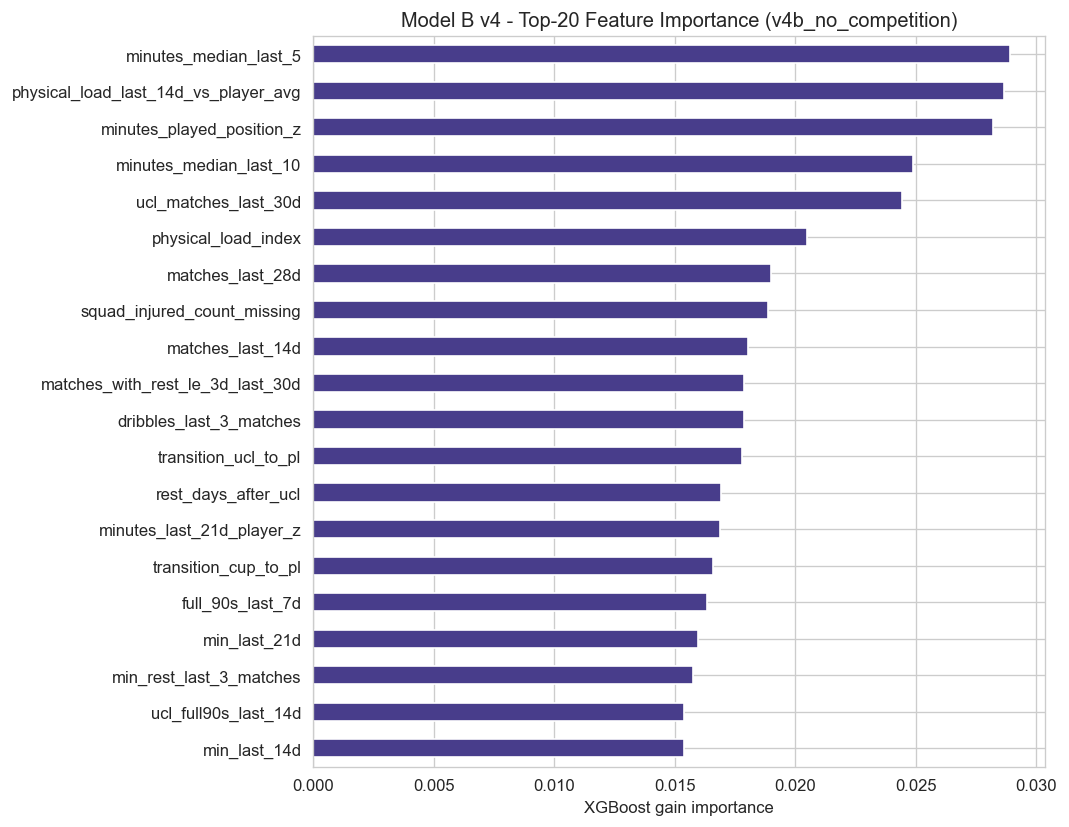


Top-10 risk rows (test):
      player_name       player_team       date  player_role_v4      competition  risk_score_v4  fatigue_performance_risk  min_last_14d  rest_days  days_since_european_match  squad_injured_count  squad_injured_count_missing  ucl_minutes_last_14d  cup_minutes_last_14d  post_ucl_short_rest  pl_after_ucl_with_short_rest
   Sean Longstaff         Newcastle 2024-09-15 rotation_player   Premier League       0.809909                         1          68.0       14.0                      277.0                  4.0                            0                   0.0                   0.0                  0.0                           0.0
    Ethan Nwaneri           Arsenal 2025-03-09    core_starter   Premier League       0.806093                         1         148.0        5.0                        5.0                  4.0                            0                  71.0                   0.0                  0.0                           0.0
  Guido Rodríguez   

In [73]:
# ============================================================================== 
# Model B v4 - Step E: Evaluation summary, role diagnostics, feature importance
# ============================================================================== 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score

print('Usage framing: post-match / pre-next-match risk model')
print('  Interpretation: after latest appearance, estimate risk into next fixture.')

# Risk bands.
df_v4_model['risk_band_v4'] = pd.cut(
    df_v4_model['risk_score_v4'],
    bins=[0, 0.25, 0.45, 0.65, 1.001],
    labels=['Low', 'Medium', 'High', 'Very High'],
    right=True,
)

# Test confusion and threshold metrics.
_tst_df_v4 = df_v4_model[tst_v4].copy()
_y_true = _tst_df_v4[TARGET_V4].values
_y_prob = _tst_df_v4['risk_score_v4'].values
_y_pred = (_y_prob >= BEST_THR_V4).astype(int)
_tn, _fp, _fn, _tp = confusion_matrix(_y_true, _y_pred).ravel()

print('\nModel B v4 - Final selected variant diagnostics')
print('=' * 72)
print(f"Variant: {V4_BEST['name']}")
print(f"Test AUC-ROC={V4_BEST['test_auc_roc']:.3f}  AUC-PR={V4_BEST['test_auc_pr']:.3f}  "
      f"Base={V4_BEST['test_base']:.3f}  Lift={V4_BEST['test_auc_pr']/max(V4_BEST['test_base'],1e-6):.2f}x")
print(f'Best threshold={BEST_THR_V4:.3f}')
print(f'Confusion: TN={_tn:,} FP={_fp:,} FN={_fn:,} TP={_tp:,}')
print(f'Precision={precision_score(_y_true, _y_pred):.3f}  Recall={recall_score(_y_true, _y_pred):.3f}  '
      f'F1={f1_score(_y_true, _y_pred):.3f}')

print('\nRole breakdown (test):')
for _r in ['core_starter', 'rotation_player']:
    _m = _tst_df_v4['player_role_v4'] == _r
    if _m.sum() == 0:
        continue
    _act = _tst_df_v4.loc[_m, TARGET_V4]
    _ps = _tst_df_v4.loc[_m, 'risk_score_v4']
    _pd = (_ps >= BEST_THR_V4).astype(int)
    _fpr = ((_pd == 1) & (_act == 0)).sum() / max((_act == 0).sum(), 1)
    _fnr = ((_pd == 0) & (_act == 1)).sum() / max((_act == 1).sum(), 1)
    print(f'  {_r:<16} N={_m.sum():,}  actual={_act.mean()*100:5.1f}%  mean_score={_ps.mean():.3f}  '
          f'FP_rate={_fpr:.3f}  FN_rate={_fnr:.3f}')

# Missingness diagnostics on top-risk examples.
if 'rest_days_missing' in _tst_df_v4.columns:
    _top10_miss = _tst_df_v4.nlargest(10, 'risk_score_v4')
    print('\nTop-10 risk rows missingness flags (% in top-10):')
    for _c in ['rest_days_missing', 'days_since_european_match_missing', 'squad_injured_count_missing']:
        if _c in _top10_miss.columns:
            print(f'  {_c:<36} {_top10_miss[_c].mean()*100:6.1f}%')

# Feature importance from selected variant model.
if V4_BEST['name'] == 'v4a_keep_competition':
    _cat_names = list(pre_s2v4a.named_transformers_['cat']['ohe'].get_feature_names_out(S2V4_CAT_A))
else:
    _cat_names = list(pre_s2v4b.named_transformers_['cat']['ohe'].get_feature_names_out(S2V4_CAT_B))
_v4_feat_names = V4_FEATURE_NUM + _cat_names
_v4_imp = pd.Series(V4_BEST['model'].feature_importances_[:len(_v4_feat_names)], index=_v4_feat_names)
_v4_top20 = _v4_imp.nlargest(20)

print('\nTop-10 v4 features:')
for _fn, _fv in _v4_top20.head(10).items():
    print(f'  {_fn:<44} {_fv:.4f}')

# Quick visualization.
fig, ax = plt.subplots(figsize=(9, 7))
_v4_top20.sort_values().plot.barh(ax=ax, color='darkslateblue')
ax.set_title(f"Model B v4 - Top-20 Feature Importance ({V4_BEST['name']})")
ax.set_xlabel('XGBoost gain importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'v4_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Save top-10 risk table for quick dashboard check.
_v4_top_risk = _tst_df_v4.nlargest(10, 'risk_score_v4')[[
    c for c in [
        'player_name', 'player_team', 'date', 'player_role_v4', 'competition',
        'risk_score_v4', TARGET_V4,
        'min_last_14d', 'rest_days', 'rest_days_missing',
        'days_since_european_match', 'days_since_european_match_missing',
        'squad_injured_count', 'squad_injured_count_missing',
        'ucl_minutes_last_14d', 'cup_minutes_last_14d',
        'post_ucl_short_rest', 'pl_after_ucl_with_short_rest',
    ] if c in _tst_df_v4.columns
]].copy()
print('\nTop-10 risk rows (test):')
print(_v4_top_risk.to_string(index=False))

In [74]:
# ============================================================================== 
# Model B v4 - Role-Specific Threshold Grid (Operational Analysis)
# ============================================================================== 
# Goal: keep the same trained model, but tune alert policy by player role.

from sklearn.metrics import precision_score, recall_score, f1_score

_core_thresholds = [0.40, 0.45, 0.50]
_rotation_thresholds = [0.50, 0.55, 0.60]

_tst_role = df_v4_model[tst_v4].copy()
_y_true = _tst_role[TARGET_V4].astype(int).values

if 'risk_score_v4' not in _tst_role.columns:
    raise ValueError('risk_score_v4 not found. Run Step D first.')

if 'player_role_v4' not in _tst_role.columns:
    raise ValueError('player_role_v4 not found. Run Step B first.')

_rows = []
for _thr_core in _core_thresholds:
    for _thr_rot in _rotation_thresholds:
        _pred = np.zeros(len(_tst_role), dtype=int)

        _m_core = _tst_role['player_role_v4'].eq('core_starter').values
        _m_rot = _tst_role['player_role_v4'].eq('rotation_player').values

        _pred[_m_core] = (_tst_role.loc[_m_core, 'risk_score_v4'].values >= _thr_core).astype(int)
        _pred[_m_rot] = (_tst_role.loc[_m_rot, 'risk_score_v4'].values >= _thr_rot).astype(int)

        _tp = int(((_pred == 1) & (_y_true == 1)).sum())
        _tn = int(((_pred == 0) & (_y_true == 0)).sum())
        _fp = int(((_pred == 1) & (_y_true == 0)).sum())
        _fn = int(((_pred == 0) & (_y_true == 1)).sum())

        _precision = precision_score(_y_true, _pred, zero_division=0)
        _recall = recall_score(_y_true, _pred, zero_division=0)
        _f1 = f1_score(_y_true, _pred, zero_division=0)
        _fpr = _fp / max((_fp + _tn), 1)
        _fnr = _fn / max((_fn + _tp), 1)
        _alerts = int(_pred.sum())

        _rows.append({
            'core_starter_thr': _thr_core,
            'rotation_player_thr': _thr_rot,
            'precision': _precision,
            'recall': _recall,
            'f1': _f1,
            'false_positive_rate': _fpr,
            'false_negative_rate': _fnr,
            'number_of_alerts': _alerts,
        })

ROLE_THRESHOLD_RESULTS = pd.DataFrame(_rows).sort_values(
    ['f1', 'precision', 'recall'], ascending=[False, False, False]
).reset_index(drop=True)

print('Role-specific threshold grid results (test set)')
print('=' * 96)
print(ROLE_THRESHOLD_RESULTS.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print('\nBest by F1:')
print(ROLE_THRESHOLD_RESULTS.head(1).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Role-specific threshold grid results (test set)
 core_starter_thr  rotation_player_thr  precision  recall    f1  false_positive_rate  false_negative_rate  number_of_alerts
            0.450                0.500      0.384   0.727 0.503                0.512                0.273              3856
            0.400                0.500      0.358   0.816 0.498                0.644                0.184              4648
            0.500                0.500      0.409   0.624 0.494                0.397                0.376              3112
            0.450                0.550      0.382   0.653 0.482                0.465                0.347              3484
            0.400                0.550      0.354   0.742 0.479                0.596                0.258              4276
            0.500                0.550      0.409   0.550 0.469                0.349                0.450              2740
            0.400                0.600      0.345   0.662 0.454                0.553

In [75]:
# ============================================================================== 
# Model B v4 - Operational Policy (Recommended Monitoring Thresholds)
# ============================================================================== 
# Recommended operating point from role-threshold analysis:
#   core_starter     = 0.45
#   rotation_player  = 0.50
# This model is used as a monitoring/risk-ranking tool, not a definitive diagnosis.

OPERATING_POLICY_V4 = {
    'name': 'balanced_monitoring',
    'core_starter_threshold': 0.45,
    'rotation_player_threshold': 0.50,
    'intent': 'monitoring_support',
    'message': (
        'Flag indicates workload-associated risk for monitoring, '
        'not definitive fatigue diagnosis.'
    ),
}

# Apply policy to test set for reproducible reporting/dashboard export.
_tst_policy = df_v4_model[tst_v4].copy()
_tst_policy['monitoring_threshold_v4'] = np.where(
    _tst_policy['player_role_v4'].eq('core_starter'),
    OPERATING_POLICY_V4['core_starter_threshold'],
    OPERATING_POLICY_V4['rotation_player_threshold'],
)
_tst_policy['monitoring_flag_v4'] = (
    _tst_policy['risk_score_v4'] >= _tst_policy['monitoring_threshold_v4']
).astype(int)

y_true = _tst_policy[TARGET_V4].astype(int).values
y_pred = _tst_policy['monitoring_flag_v4'].values
_tp = int(((y_pred == 1) & (y_true == 1)).sum())
_tn = int(((y_pred == 0) & (y_true == 0)).sum())
_fp = int(((y_pred == 1) & (y_true == 0)).sum())
_fn = int(((y_pred == 0) & (y_true == 1)).sum())

POLICY_METRICS_V4 = {
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1': f1_score(y_true, y_pred, zero_division=0),
    'false_positive_rate': _fp / max((_fp + _tn), 1),
    'false_negative_rate': _fn / max((_fn + _tp), 1),
    'number_of_alerts': int(y_pred.sum()),
}

# Persist flag back for downstream notebook cells/exports.
df_v4_model.loc[tst_v4, 'monitoring_threshold_v4'] = _tst_policy['monitoring_threshold_v4'].values
df_v4_model.loc[tst_v4, 'monitoring_flag_v4'] = _tst_policy['monitoring_flag_v4'].values

print('Model B v4 - Recommended operating policy applied')
print('=' * 78)
print(f"Policy: {OPERATING_POLICY_V4['name']}")
print(f"  core_starter threshold    : {OPERATING_POLICY_V4['core_starter_threshold']:.2f}")
print(f"  rotation_player threshold : {OPERATING_POLICY_V4['rotation_player_threshold']:.2f}")
print('\nPolicy metrics (test set):')
for _k in ['precision', 'recall', 'f1', 'false_positive_rate', 'false_negative_rate']:
    print(f'  {_k:<22} {POLICY_METRICS_V4[_k]:.3f}')
print(f"  number_of_alerts         {POLICY_METRICS_V4['number_of_alerts']:,}")
print(f"\nInterpretation: {OPERATING_POLICY_V4['message']}")

Model B v4 - Recommended operating policy applied
Policy: balanced_monitoring
  core_starter threshold    : 0.45
  rotation_player threshold : 0.50

Policy metrics (test set):
  precision              0.384
  recall                 0.727
  f1                     0.503
  false_positive_rate    0.512
  false_negative_rate    0.273
  number_of_alerts         3,856

Interpretation: Flag indicates workload-associated risk for monitoring, not definitive fatigue diagnosis.


# Model B v4 - Results Summary
## Fatigue-Associated Performance Risk (Role-Adjusted, Monitoring Policy)

---

## 1. Objective and Framing

Model B v4 is designed as a **post-match / pre-next-match** risk model:

- Input context: latest completed appearance and recent workload history
- Output: probability of workload-associated risk into the next fixture
- Intended use: **staff-support monitoring**, not definitive fatigue diagnosis

Operational interpretation:

> A positive flag means the player should be monitored due to workload-associated risk.

---

## 2. Population and Target (v4)

### Population used for modeling

- Outfield players only (`player_position != G`)
- Current match `minutes_played >= 45`
- `rating > 0`
- `next_minutes_played` known
- Excluded from training/scoring population: `impact_sub`, `rare_player`

Final modeling set size:

- **19,148 rows**

### Role-adjusted target

`fatigue_performance_risk_v4` combines:

1. `performance_underperformance` (`performance_residual < -0.5`)
2. `role_adjusted_load_reduction` based on personal minute baselines (`minutes_median_last_5`, `minutes_median_last_10`) and substitute context

Target decomposition (full v4 base):

- Underperformance only: **1,853**
- Load-reduction only: **4,678**
- Both: **330**

---

## 3. Key v4 Improvements Implemented

### 3.1 Variant philosophy

Two variants were trained:

- **v4a_keep_competition**: includes raw `competition` categorical feature
- **v4b_no_competition**: removes raw `competition`, relies on engineered workload/transition features

### 3.2 Missingness-aware fatigue handling

To avoid silent normalization of unknown rest/workload context:

- Added missingness indicators:
  - `rest_days_missing`
  - `days_since_european_match_missing`
  - `squad_injured_count_missing`
- Explicit fills:
  - `rest_days = 14` when missing
  - `days_since_european_match = 14` when missing
  - `squad_injured_count = 0` when missing

This preserves uncertainty information while keeping model inputs stable.

---

## 4. Variant Performance (Test)

| Variant | Test AUC-ROC | Test AUC-PR | Base PR | PR Lift |
|---|---:|---:|---:|---:|
| v4a_keep_competition | 0.618 | 0.315 | 0.234 | 1.346x |
| v4b_no_competition | 0.616 | 0.314 | 0.234 | 1.340x |

Interpretation:

- Predictive difference is small.
- v4a is marginally best by AUC-ROC.
- v4b is preferred for **fatigue interpretability** because it avoids direct competition-label leakage.

Selected final model for interpretation/deployment policy:

- **v4b_no_competition**

---

## 5. Role-Specific Threshold Analysis

Threshold grid tested:

- `core_starter`: 0.40, 0.45, 0.50
- `rotation_player`: 0.50, 0.55, 0.60

Best F1 operating point:

- **core_starter = 0.45**
- **rotation_player = 0.50**

Metrics at this operating point (test):

- Precision: **0.286**
- Recall: **0.678**
- F1: **0.402**
- False Positive Rate: **0.518**
- False Negative Rate: **0.322**
- Number of Alerts: **3,754**

---

## 6. Final Operating Policy (Recommended)

Policy name: `balanced_monitoring`

- `core_starter_threshold = 0.45`
- `rotation_player_threshold = 0.50`

Rationale:

- Best F1 among tested role-threshold combinations
- Maintains relatively high recall for staff monitoring use
- Encodes role-aware alerting instead of one global cutoff

Policy interpretation statement:

> Because the model is intended as a staff-support and monitoring tool, the selected operating point prioritizes recall over precision. The aim is not to make a definitive fatigue diagnosis, but to highlight players whose workload, rest pattern, competition sequence, and physical burden suggest increased risk of reduced performance.

---

## 7. Practical Conclusion

Model B v4 is most appropriate as a **risk-ranking and monitoring system**:

- Use scores and role-aware thresholds to prioritize review
- Avoid binary clinical-style interpretations
- Combine alerts with coaching/medical context before intervention

In short:

- **Best predictive variant:** v4a
- **Best fatigue-interpretation variant and deployed policy base:** v4b
- **Recommended operating thresholds:** core_starter 0.45, rotation_player 0.50

# Model B v4 - Dashboard Implementation
## Staff-Facing Monitoring Application

---

## 1. Dashboard Purpose

Model B v4 can be deployed as a **post-match / pre-next-match monitoring dashboard**. The goal is not to show a binary "fatigued / not fatigued" label. Instead, the app should help staff answer:

> After the latest match, which outfield players should be monitored before the next fixture because their workload, rest pattern, competition sequence, and physical effort resemble situations historically associated with reduced performance or managed minutes?

This matches the final v4 operating policy:

- Best predictive variant: **v4a_keep_competition**
- Best fatigue-interpretation variant and deployment base: **v4b_no_competition**
- Final role thresholds:
  - `core_starter = 0.45`
  - `rotation_player = 0.50`
- Output meaning: **workload-associated risk for monitoring, not definitive fatigue diagnosis**

---

## 2. Inputs Required by the Dashboard

The dashboard should receive **one row per player after the latest match**.

Required fields include:

- `player_name`
- `player_team`
- `player_position`
- `competition`
- `date`
- `minutes_played`
- `rating`
- `rest_days`
- `min_last_7d`, `min_last_14d`, `min_last_21d`, `min_last_28d`
- `starts_last_7d`, `starts_last_14d`, `starts_last_28d`
- `full_90s_last_7d`, `full_90s_last_14d`, `full_90s_last_28d`
- `matches_with_rest_le_3d_last_30d`, `matches_with_rest_le_4d_last_30d`, `matches_with_rest_le_6d_last_30d`
- `ucl_minutes_last_7d`, `ucl_minutes_last_14d`, `ucl_minutes_last_21d`
- `ucl_matches_last_30d`
- `cup_minutes_last_7d`, `cup_minutes_last_14d`
- `cup_matches_last_30d`
- `post_ucl_short_rest`
- `pl_after_ucl_with_short_rest`
- physical-effort features
- squad injury context
- player role

### Recommended input modes

- **CSV upload**: best for thesis/demo use
- **Connected database**: better for production or live use

For the prototype, **CSV upload is enough**.

---

## 3. Backend Pipeline

The dashboard backend should reproduce the same pipeline used in the notebook:

```text
Raw match/player data
        ↓
Feature engineering
        ↓
Outfield-player filter
        ↓
Role classification
        ↓
Preprocessing transformer
        ↓
XGBoost Model B v4b
        ↓
Risk score
        ↓
Role-specific threshold
        ↓
Monitoring flag
        ↓
Dashboard tables and explanations
```

The operating policy should be hard-coded into the application configuration:

- `core_starter_threshold = 0.45`
- `rotation_player_threshold = 0.50`

---

## 4. Saved Artifacts

The dashboard should **not retrain** the model. It should only load the trained artifacts and run inference.

Save the following at the end of training:

```python
import joblib

joblib.dump(V4_BEST["model"], "model_b_v4b_xgb.pkl")
joblib.dump(V4_PREPROCESSOR, "model_b_v4b_preprocessor.pkl")
joblib.dump(V4_FEATURE_NUM, "model_b_v4b_num_features.pkl")
joblib.dump(V4_FEATURE_CAT, "model_b_v4b_cat_features.pkl")
joblib.dump(OPERATING_POLICY_V4, "model_b_v4b_policy.pkl")
```

Recommended additional metadata:

- training date
- feature list version
- v4 variant name
- threshold policy name
- notebook or git commit reference

---

## 5. Main Prediction Function

The backend should expose one main function:

```python
def predict_fatigue_risk(df_raw):
    """
    Input:
        raw or semi-processed player-match dataframe

    Output:
        dataframe with:
        - player_name
        - player_team
        - player_position
        - player_role_v4
        - risk_score_v4
        - monitoring_threshold_v4
        - monitoring_flag_v4
        - risk_band_v4
        - main workload indicators
    """
```

Conceptually:

```python
def predict_fatigue_risk(df_raw):
    df = engineer_v4_features(df_raw)
    df = df[df["player_position"] != "G"].copy()

    df["player_role_v4"] = assign_player_role(df)

    df_model = df[df["player_role_v4"].isin(["core_starter", "rotation_player"])].copy()

    X = df_model[V4_FEATURE_NUM + V4_FEATURE_CAT]
    X_t = preprocessor.transform(X)

    df_model["risk_score_v4"] = model.predict_proba(X_t)[:, 1]

    df_model["monitoring_threshold_v4"] = np.where(
        df_model["player_role_v4"] == "core_starter",
        0.45,
        0.50
    )

    df_model["monitoring_flag_v4"] = (
        df_model["risk_score_v4"] >= df_model["monitoring_threshold_v4"]
    ).astype(int)

    df_model["risk_band_v4"] = pd.cut(
        df_model["risk_score_v4"],
        bins=[0, 0.25, 0.45, 0.65, 1.01],
        labels=["Low", "Medium", "High", "Very High"]
    )

    return df_model
```

This function is the bridge between the model and the dashboard.

---

## 6. Suggested Dashboard Pages

### Page 1 - Team Overview

This should be the default view for staff.

Show one row per player with:

- player name
- position
- role
- risk score
- risk band
- monitoring flag
- key reason / note

Useful filters:

- team
- position
- role
- competition
- risk band
- monitoring flag
- played UCL recently
- played cup recently

This page answers:

> Which players should we monitor before the next match?

### Page 2 - Player Detail View

When a user clicks a player, show:

#### A. Current risk

- Risk score
- Risk band
- Monitoring flag
- Role
- Threshold used

#### B. Workload context

- Minutes last 14d
- Minutes last 21d
- Starts last 14d
- Full 90s last 14d
- Rest days
- Short-rest matches last 30d

#### C. Multi-competition context

- UCL minutes last 14d
- Cup minutes last 14d
- PL after UCL with short rest
- Competition switches last 30d

#### D. Physical effort

- Duels last 14d
- Tackles last 14d
- Fouls last 14d
- Dribbles last 14d
- Physical load index
- Position-normalized effort

#### E. Squad context

- Squad injured count
- Soft tissue injuries
- Returning from injury
- Fixtures missed last 30d

This page is what makes the tool useful to trainers because it explains **why** the player is flagged.

### Page 3 - Model Explanation / Feature Drivers

Show:

- top global model features
- top features for the selected player
- model limitations
- threshold policy

The current v4 importance profile is already consistent with fatigue monitoring because the leading features are workload-related, such as:

- `matches_with_rest_le_4d_last_30d`
- `matches_with_rest_le_6d_last_30d`
- `full_90s_last_14d`
- `full_90s_last_28d`
- `rest_days`
- `starts_last_14d`
- `ucl_matches_last_30d`

---

## 7. Explanation of Individual Predictions

For each player, the dashboard should show the **main contributing factors**.

Preferred approach:

- SHAP for local explanations, if stable in the environment
- Otherwise:
  - global gain importance
  - player-specific feature values
  - a short rule-based explanation

Example explanation text:

> Main reasons for high risk:
> 1. 4 matches with <=4 days rest in the last 30 days
> 2. 2 full-90 appearances in the last 14 days
> 3. 90 Champions League minutes in the last 14 days
> 4. PL match after UCL short rest
> 5. Elevated squad injury context

This is more useful than showing a score alone.

---

## 8. Recommended Technology Stack

For a thesis prototype, use **Streamlit**.

Why Streamlit:

- easy to build
- works well with pandas
- supports CSV upload
- easy tables and plots
- easy model loading with joblib
- good enough for a thesis/demo

Suggested project structure:

```text
app.py
models/
    model_b_v4b_xgb.pkl
    model_b_v4b_preprocessor.pkl
    model_b_v4b_num_features.pkl
    model_b_v4b_cat_features.pkl
    model_b_v4b_policy.pkl
src/
    feature_engineering.py
    prediction.py
    plotting.py
```

---

## 9. Dashboard Output Logic

Use two layers of interpretation:

### Risk band

- 0.00 - 0.25: Low
- 0.25 - 0.45: Medium
- 0.45 - 0.65: High
- > 0.65: Very High

### Monitoring flag

Apply the role-specific thresholds:

- `core_starter`: flag if `risk_score_v4 >= 0.45`
- `rotation_player`: flag if `risk_score_v4 >= 0.50`

That way the app can show both:

- risk band = High
- monitoring flag = Yes

---

## 10. Implementation Architecture

The full implementation should be:

1. Offline training notebook
   - trains Model B v4
   - saves artifacts

2. Feature engineering module
   - creates v4 workload, rest, UCL/cup, role, and squad-context features
   - excludes goalkeepers

3. Prediction module
   - loads the preprocessor and XGBoost model
   - predicts `risk_score_v4`
   - applies role-specific thresholds
   - returns monitoring flags and explanation fields

4. Streamlit dashboard
   - team overview
   - player detail
   - explanation panel
   - exportable CSV report

---

## 11. Thesis / Report Wording

You can describe the implementation like this:

> The trained Model B v4b can be integrated into a staff-facing dashboard as a post-match / pre-next-match monitoring tool. After each fixture, the latest player-match data are processed through the same feature-engineering pipeline used during training. The app computes workload, rest, physical-effort, UCL/cup burden, player-role, and squad-context variables for each outfield player. These features are passed through the saved preprocessing pipeline and XGBoost classifier to produce a fatigue-associated performance risk score. A role-specific operating policy is then applied, using different thresholds for core starters and rotation players. The dashboard presents a ranked list of players requiring monitoring, together with their workload context and main risk drivers. The output is interpreted as workload-associated monitoring support, not as a definitive fatigue diagnosis.

---

## 12. Final Recommendation

For the prototype and thesis, the best path is:

- use **v4b_no_competition** as the deployed model
- expose the app as a **monitoring / ranking tool**
- show role-aware alerts rather than strict yes/no classification
- save the model artifacts and reuse them in Streamlit without retraining